In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pulp
#for davis dataset 
#rabi=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\Rabi_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")#davis data 
#for davis 
#kharif=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")

#adding water in using hoestra data 
kharif=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\kharif_waterdemand.csv")
rabi=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\rabi_waterdemand.csv")
CoP= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\cost_of_production.csv")
bnf_applied= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\bnf\bnf_app.csv")

In [2]:
kharif

,Unnamed: 0,state,district,Year,Season,crop,Area (Hectare),Production (Tonnes),Yield (Tonnes/Hectare),N_applied(kg/ha),...,Manure (kg/ha),calorie_per_100g,MSP_RsperQntl,CostofCultivation_rs_ha,CWR_y,CWU green_y,CWU blue_y,CWR m3/ha,CWU green m3/ha,CWU blue m3/ha
0,15576,tamil nadu,ariyalur,2009,Kharif,rice,25978.0,80462.00,3.097313,116.600503,...,2986.569126,345,1000.0,NaN,32335367.0,16791899.0,14351936.0,10439.812130,5421.440583,4633.672956
1,15579,tamil nadu,ariyalur,2010,Kharif,rice,25211.0,97869.00,3.881996,104.816457,...,2433.874693,345,1000.0,NaN,32335367.0,16791899.0,14351936.0,8329.572566,4325.583849,3697.050736
2,15584,tamil nadu,ariyalur,2011,Kharif,rice,24097.0,97257.00,4.036063,145.985692,...,0.000000,345,1095.0,NaN,32335367.0,16791899.0,14351936.0,8011.611900,4160.465470,3555.925042
3,15587,tamil nadu,ariyalur,2012,Kharif,rice,17523.0,36392.00,2.076813,117.857143,...,17857.142860,345,1265.0,51157.05,32335367.0,16791899.0,14351936.0,15569.703120,8085.415646,6910.556565
4,15592,tamil nadu,ariyalur,2013,Kharif,rice,24437.0,131658.00,5.387650,124.379222,...,9119.385343,345,1327.5,NaN,32335367.0,16791899.0,14351936.0,6001.757306,3116.739096,2663.858330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21421,17518,tripura,west tripura,2018,Kharif,maize,2055.0,2681.58,1.304905,NaN,...,NaN,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21422,17519,tripura,west tripura,2018,Kharif,jowar,25.0,19.00,0.760000,NaN,...,NaN,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21423,17520,tripura,west tripura,2018,Kharif,rice,17620.0,51068.79,2.898342,NaN,...,NaN,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21424,17521,tripura,west tripura,2019,Kharif,maize,2122.0,2948.36,1.389425,NaN,...,NaN,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Convert 'State' and 'Crop' column values to lowercase
CoP['State'] = CoP['State'].str.strip().str.lower()
CoP['Crop'] = CoP['Crop'].str.strip().str.lower()

# Now, the 'State' and 'Crop' columns in CoP DataFrame have all their values in lowercase
# Rename the columns in CoP to match kharif DataFrame for a consistent merge
CoP_renamed = CoP.rename(columns={"Crop": "crop", "State": "state", "CostofProduction_rs_Quintal": "Cost_of_Production_rs_Quintal"})
# Perform the merge
kharif = pd.merge(kharif, CoP_renamed, how='left', on=['state', 'Year', 'crop'])


In [4]:
import pandas as pd

# Sample data to illustrate the process. The actual data is not shown due to the format of the question.
# These dictionaries represent the mapping from atm['State'] to kharif['state'] based on the provided examples.
state_name_mapping = {
    'Andaman and Nicobar': 'andaman and nicobar',
    'Andhra Pradesh': 'andhra pradesh',
    'Arunachal Pradesh': 'arunachal pradesh',
    'Assam': 'assam',
    'Bihar': 'bihar',
    'Chandigarh': 'chandigarh',
    'Chhattisgarh': 'chhattisgarh',
    'Dadra and Nagar Haveli': 'dadra and nagar haveli',
    'Daman and Diu': 'the dadra and nagar haveli and daman and diu', # Assuming both to be mapped to the single entry in kharif
    'Delhi': 'delhi', # Not present in the provided kharif states list, but added for completeness
    'Goa': 'goa', # Not present in the provided list, but added for completeness
    'Gujarat': 'gujarat',
    'Haryana': 'haryana',
    'Himachal Pradesh': 'himachal pradesh',
    'Jammu and Kashmir': 'jammu and kashmir',
    'Jharkhand': 'jharkhand',
    'Karnataka': 'karnataka',
    'Kerala': 'kerala',
    'Lakshadweep': 'lakshadweep', # Not present, but added for completeness
    'Madhya Pradesh': 'madhya pradesh',
    'Maharashtra': 'maharashtra',
    'Manipur': 'manipur',
    'Meghalaya': 'meghalaya',
    'Mizoram': 'mizoram',
    'Nagaland': 'nagaland',
    'Orissa': 'odisha',
    'Puducherry': 'puducherry',
    'Punjab': 'punjab',
    'Rajasthan': 'rajasthan',
    'Sikkim': 'sikkim',
    'Tamil Nadu': 'tamil nadu',
    'Telangana': 'telangana',
    'Tripura': 'tripura',
    'Uttar Pradesh': 'uttar pradesh',
    'Uttaranchal': 'uttarakhand', # Mapped to 'uttarakhand' as per provided list
    'West Bengal': 'west bengal',
}

# Assume atm_df and kharif_df are the DataFrames for the 'atm' and 'kharif' datasets, respectively.
# This code will update the 'State' column in atm_df to match the 'state' values in kharif_df.

# Example atm_df DataFrame creation
# This is a placeholder and should be replaced with the actual atm DataFrame in practice.
atm_df= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\atmospheric_depo_isimip_2a.csv")   # kg/ha

# Update 'State' in atm_df to match 'state' in kharif_df using the mapping
atm_df['State'] = atm_df['State'].map(state_name_mapping)
# Renaming 'State' in atm_df to 'state' to match kharif_df column name for a consistent merge
atm_df.rename(columns={'State': 'state'}, inplace=True)
# Assuming kharif_df exists, the merge operation would look like this:
# merged_df = pd.merge(kharif_df, atm_df, left_on='state', right_on='State')

# Displaying the updated atm_df for verification
atm_df


,Year,state,atm_depo
0,2009,andaman and nicobar,0.000000
1,2010,andaman and nicobar,0.000000
2,2011,andaman and nicobar,0.000000
3,2012,andaman and nicobar,0.000000
4,2013,andaman and nicobar,0.000000
...,...,...,...
427,2020,telangana,1.447027
428,2020,tripura,1.309994
429,2020,uttar pradesh,1.855148
430,2020,uttarakhand,1.651030


In [5]:
# Performing the merge based on 'state' and 'Year'
kharif = pd.merge(kharif, atm_df, on=['state', 'Year'], how='left')
kharif = pd.merge(kharif, bnf_applied, on=[ 'Year'], how='left')
#coeff from image mmodel 

image_coeff= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\trial_analysis\image_coeff.csv")
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['State'] = image_coeff['State'].str.lower().str.strip()
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['fn2o'] = image_coeff['fn2o'] / 100    # as the value provided is in percentage 
image_coeff['fno3'] = image_coeff['fno3'] / 100

#image_coeff.rename(columns={'State':'state'}, inplace=True)
# Create a mapping dictionary from the abbreviated state names to the full state names
state_mapping = {
     'the dadra and nagar haveli and daman and diu':'dadra and nagar haveli',
    'andaman and nicobar islands':'andaman and nicobar'
}

# Use the 'replace' method to update the 'State' column in cwc_crop
image_coeff['State'] = image_coeff['State'].replace(state_mapping)
image_coeff.rename(columns={'State': 'state'}, inplace=True)


In [6]:
kharif = pd.merge(kharif, image_coeff, on=[ 'state'], how='left')


In [7]:

del kharif['Unnamed: 0']
del rabi['Unnamed: 0']
#manure nitrogen 
kharif['Manure (N_kg/ha)']=kharif['Manure (kg/ha)']*.005   #  https://agritech.tnau.ac.in/org_farm/orgfarm_manure.html
kharif['Manure (P_kg/ha)']=kharif['Manure (kg/ha)']*.002

rabi['Manure (N_kg/ha)']=rabi['Manure (kg/ha)']*.005
rabi['Manure (P_kg/ha)']=rabi['Manure (kg/ha)']*.002

# Ensure columns are numeric
kharif['N_applied(kg/ha)'] = pd.to_numeric(kharif['N_applied(kg/ha)'], errors='coerce')
kharif['Manure (N_kg/ha)'] = pd.to_numeric(kharif['Manure (N_kg/ha)'], errors='coerce')
kharif['P_applied(kg/ha)'] = pd.to_numeric(kharif['P_applied(kg/ha)'], errors='coerce')
kharif['Manure (P_kg/ha)'] = pd.to_numeric(kharif['Manure (P_kg/ha)'], errors='coerce')
kharif['Manure (N_kg/ha)'] = pd.to_numeric(kharif['Manure (N_kg/ha)'], errors='coerce')
kharif['CWR m3/ha'] = pd.to_numeric(kharif['CWR m3/ha'], errors='coerce')
kharif['CWU green m3/ha'] = pd.to_numeric(kharif['CWU green m3/ha'], errors='coerce')
kharif['CWU blue m3/ha'] = pd.to_numeric(kharif['CWU blue m3/ha'], errors='coerce')
# Replace 0 with np.nan using np.where
kharif['N_applied(kg/ha)'] = np.where(kharif['N_applied(kg/ha)'] == 0, np.nan, kharif['N_applied(kg/ha)'])
kharif['Manure (N_kg/ha)'] = np.where(kharif['Manure (N_kg/ha)'] == 0, np.nan, kharif['Manure (N_kg/ha)'])
kharif['P_applied(kg/ha)'] = np.where(kharif['P_applied(kg/ha)'] == 0, np.nan, kharif['P_applied(kg/ha)'])
kharif['Manure (P_kg/ha)'] = np.where(kharif['Manure (P_kg/ha)'] == 0, np.nan, kharif['Manure (P_kg/ha)'])
kharif['CWR m3/ha']  = np.where(kharif['CWR m3/ha'] == 0, np.nan, kharif['CWR m3/ha'])
kharif['CWU green m3/ha'] = np.where(kharif['CWU green m3/ha'] == 0, np.nan, kharif['CWU green m3/ha'])
kharif['CWU blue m3/ha'] = np.where(kharif['CWU blue m3/ha'] == 0, np.nan, kharif['CWU blue m3/ha'])

# Replace 'inf' with 'np.nan' in specified columns
kharif['N_applied(kg/ha)'] = kharif['N_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)
kharif['P_applied(kg/ha)'] = kharif['P_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)
kharif['K_applied(kg/ha)'] = kharif['K_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)

#calculating n app rate 
kharif['net_N_applied(kg/ha)']=kharif['N_applied(kg/ha)']+kharif['Manure (N_kg/ha)'] + kharif['atm_depo'] +kharif['BNF_kg_per_hec'] 

kharif['net_P_applied(kg/ha)']=kharif['P_applied(kg/ha)']+kharif['Manure (P_kg/ha)'] 



kharif_max=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_max.csv")
del kharif_max['Unnamed: 0']



In [8]:
# IF FOLLOWING FAO FAOSTAT Domain Cropland Nutrient Budget Metadata, release November 2022
#https://www.fao.org/faostat/en/#data/ESB
# Define the nitrogen content dictionary (as provided previously)  # value in kg per kg product
crop_nitrogen_content = {
    'rice': .0129,
    'jowar': .0146,   # SORGHUM
    'bajra': .0204,
    'maize': .0124,
    'ragi': .0204
   # ,'wheat':.0209
}


crop_phosphorous_content = {
    'rice': .0028,
    'jowar': .0045,   # SORGHUM
    'bajra': .0042,
    'maize': .0034,
    'ragi': .0042
    #,'wheat':.0042
}

# Create the n_removed column by multiplying PRODUCTION (kg) by nitrogen content
kharif['n_removed_rate'] = kharif.apply(lambda row:crop_nitrogen_content.get(row['crop'], 0), axis=1)


# Create the p_removed column by multiplying PRODUCTION (kg) by nitrogen content
kharif['p_removed_rate'] = kharif.apply(lambda row:crop_phosphorous_content.get(row['crop'], 0), axis=1)
# Replace 0s with NaN in ''CWR m3/ha'' column
kharif['CWR m3/ha'].replace(0, float('nan'), inplace=True)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\4228831115.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kharif['CWR m3/ha'].replace(0, float('nan'), inplace=True)


In [9]:
kharif

,state,district,Year,Season,crop,Area (Hectare),Production (Tonnes),Yield (Tonnes/Hectare),N_applied(kg/ha),P_applied(kg/ha),...,atm_depo,BNF_kg_per_hec,fn2o,fno3,Manure (N_kg/ha),Manure (P_kg/ha),net_N_applied(kg/ha),net_P_applied(kg/ha),n_removed_rate,p_removed_rate
0,tamil nadu,ariyalur,2009,Kharif,rice,25978.0,80462.00,3.097313,116.600503,60.934443,...,0.744613,24.2071,0.0342,0.3326,14.932846,5.973138,156.485062,66.907581,0.0129,0.0028
1,tamil nadu,ariyalur,2010,Kharif,rice,25211.0,97869.00,3.881996,104.816457,54.951577,...,0.794058,27.2563,0.0342,0.3326,12.169373,4.867749,145.036189,59.819326,0.0129,0.0028
2,tamil nadu,ariyalur,2011,Kharif,rice,24097.0,97257.00,4.036063,145.985692,52.027027,...,0.729600,27.8646,0.0342,0.3326,NaN,NaN,NaN,NaN,0.0129,0.0028
3,tamil nadu,ariyalur,2012,Kharif,rice,17523.0,36392.00,2.076813,117.857143,17.857143,...,0.730986,27.3615,0.0342,0.3326,89.285714,35.714286,235.235343,53.571429,0.0129,0.0028
4,tamil nadu,ariyalur,2013,Kharif,rice,24437.0,131658.00,5.387650,124.379222,44.775329,...,0.780731,29.2056,0.0342,0.3326,45.596927,18.238771,199.962480,63.014100,0.0129,0.0028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21615,tripura,west tripura,2018,Kharif,maize,2055.0,2681.58,1.304905,NaN,NaN,...,1.309994,31.6054,0.0335,0.5936,NaN,NaN,NaN,NaN,0.0124,0.0034
21616,tripura,west tripura,2018,Kharif,jowar,25.0,19.00,0.760000,NaN,NaN,...,1.309994,31.6054,0.0335,0.5936,NaN,NaN,NaN,NaN,0.0146,0.0045
21617,tripura,west tripura,2018,Kharif,rice,17620.0,51068.79,2.898342,NaN,NaN,...,1.309994,31.6054,0.0335,0.5936,NaN,NaN,NaN,NaN,0.0129,0.0028
21618,tripura,west tripura,2019,Kharif,maize,2122.0,2948.36,1.389425,NaN,NaN,...,1.309994,30.0083,0.0335,0.5936,NaN,NaN,NaN,NaN,0.0124,0.0034


In [10]:
kharif['Year'].unique()

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020], dtype=int64)

In [11]:
# Columns to average over 3 years
mean_cols = [
    'N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)',
    'Cost_of_Production_rs_Quintal'
]

# Split into parts
subset_3yrs = kharif[kharif['Year'].isin([ 2016, 2017,2018])]
subset_2017 = kharif[kharif['Year'] == 2017]

# Compute the mean only for selected columns
mean_part = subset_3yrs.groupby(['state', 'district', 'crop'], as_index=False)[mean_cols].mean()

# Get 2017 data for all other columns
non_mean_cols = [col for col in subset_2017.columns if col not in mean_cols]
subset_2017_part = subset_2017[non_mean_cols]

# Merge both parts on keys
kharif_2017 = pd.merge(subset_2017_part, mean_part, on=['state', 'district', 'crop'], how='left')


In [12]:
#getting year specific data 
#kharif_2017 = kharif[kharif['Year'].isin([2017])]
#kharif_2017 =kharif[kharif['Year'].isin([2015, 2016, 2017])].groupby(['state', 'district', 'crop'], as_index=False).mean(numeric_only=True)
# Calculate the crop-specific average values for each nutrient
avg_nutrients = kharif_2017.groupby('crop')[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].transform('mean')

# Fill NaN values in kharif with the crop-specific average values
kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']] = kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].fillna(avg_nutrients)

avg_wat=kharif_2017.groupby(['state','crop'])[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].transform('mean')
kharif_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']] = kharif_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].fillna(avg_wat)


In [13]:
# Assuming rabi_2017 is your DataFrame
kharif_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
kharif_2017['Manure (P_kg/ha)'].fillna(0, inplace=True)

#calculating n app rate 
#calculating n app rate 
kharif_2017['net_N_applied(kg/ha)']=kharif_2017['N_applied(kg/ha)']+kharif_2017['Manure (N_kg/ha)'] + kharif_2017['atm_depo'] +kharif_2017['BNF_kg_per_hec'] 

kharif_2017['net_P_applied(kg/ha)']=kharif_2017['P_applied(kg/ha)']+kharif_2017['Manure (P_kg/ha)'] 


#finding historical area 
# Grouping the data by state, district, and crop and summing the area
historical_cereal_area = kharif.groupby(['state', 'district', 'crop'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
historical_cereal_area_dict = historical_cereal_area.to_dict()

#historiccally maximum area 
# Grouping the data by state and district and summing the area to find the maximum historical area
total_historical_area_district = kharif.groupby(['state', 'district','Year'])['Area (Hectare)'].sum()
max_historical_area_district = kharif.groupby(['state', 'district'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
max_historical_area_district_dict = max_historical_area_district.to_dict()

# Display the first few elements of the dictionary to verify
list(max_historical_area_district_dict.items())[:5]




C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\3883408602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kharif_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\3883408602.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

[(('andaman and nicobar', 'nicobars'), 3.247),
 (('andaman and nicobar', 'north and middle andaman'), 6199.9169999999995),
 (('andaman and nicobar', 'south andamans'), 415.741),
 (('andhra pradesh', 'adilabad'), 30125.416666666668),
 (('andhra pradesh', 'anantapur'), 12385.51923076923)]

In [14]:
solver = pulp.PULP_CBC_CMD()


In [15]:
# Load the AGHG factor data
aghg_factors = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data/aghg_factor.csv")
aghg_factors.head()
# Create mapping dictionaries for each crop's CO2eq emission per kg yield,
# and for methane (CH4) emissions per hectare for rice.
# These are state-specific values derived from the uploaded AGHG factor dataset.
# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq

rice_emission_kg = aghg_factors.set_index('State')['Rice_CO2eq_perkg'].to_dict()
wheat_emission_kg = aghg_factors.set_index('State')['Wheat_CO2eq_perkg'].to_dict()
maize_emission_kg = aghg_factors.set_index('State')['Maize_CO2eq_perkg'].to_dict()
millet_emission_kg = aghg_factors.set_index('State')['Millets_CO2eq_perkg'].to_dict()
rice_ch4_ha = aghg_factors.set_index('State')['rice_ch4_co2_eq_per_ha'].to_dict()


In [16]:
df = kharif_2017
#del df['Unnamed: 0']
# Renaming the column
df.rename(columns={'district': 'District'}, inplace=True)
df.rename(columns={'state': 'State'}, inplace=True)
df.rename(columns={'crop': 'Crop'}, inplace=True)

#calculating n app rate 
kharif_2017['net_N_applied(kg/ha)']=kharif_2017['N_applied(kg/ha)']+kharif_2017['Manure (N_kg/ha)'] + kharif_2017['atm_depo'] +kharif_2017['BNF_kg_per_hec'] 

kharif_2017['net_P_applied(kg/ha)']=kharif_2017['P_applied(kg/ha)']+kharif_2017['Manure (P_kg/ha)'] 

#finding maximum area 
kharif_max.rename(columns={'district': 'District'}, inplace=True)
kharif_max.rename(columns={'state': 'State'}, inplace=True)
kharif_max.rename(columns={'crop': 'Crop'}, inplace=True)
kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()




 #  only kharif crop 
# Step 1: Filter the DataFrame
selected_crops = ['bajra', 'jowar', 'ragi', 'rice'
                  ,'maize'
                  ]
df = df[df['Crop'].isin(selected_crops)]
kharif_max = kharif_max[kharif_max['Crop'].isin(selected_crops)]


# Step 2: Create a dictionary for maximum area constraints
max_area_constraints = kharif_max.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

# Convert to lowercase and strip whitespace
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

#fillin nan value in applied n with national avg 
#filling the nan values in the n application rate with state and crop avg value 
# Compute the average for 'N_applied(kg/ha)' grouped by 'State' and 'Crop'
avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
global_avg=kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_N_applied(kg/ha)' with the computed average
df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
if df['net_N_applied(kg/ha)'].isnull().any():
    df['net_N_applied(kg/ha)'].fillna(global_avg, inplace=True)  # Fallback to global average if needed

#fillin nan value in applied p with national avg 
avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
global_avg_P=kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_P_applied(kg/ha)' with the computed average
df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
if df['net_P_applied(kg/ha)'].isnull().any():
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)  # Fallback to global average if needed


#filling cost of cultivattion with avg vallue 
# Step 1
avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')

# Step 2
df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)

# Step 3
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after local crop average fill")

    # Step 4
    global_avg_cost_cult = kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')

    # Step 5
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

# Step 6
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after global average fill")
else:
    print("All NaN values filled")
    
# replace all occurrences of -1 in the 'AREA (1000 ha)' and 'PRODUCTION (1000 tons)' columns with zero   which signifies missing values 
df['Area (Hectare)'] = df['Area (Hectare)'].replace(-1, 0)
df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
df['YIELD (Kg per ha)'] = 1000*df['Yield (Tonnes/Hectare)'].replace(-1, 0)
#compute avg water requiremment 
avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
global_avg_cwr=kharif.groupby(['crop'])['CWR m3/ha'].transform('mean')
# Replace NaN values in 'CWR m3/ha' with the computed average
df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
if df['CWR m3/ha'].isnull().any():
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)  # Fallback to global average if needed

df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

#setting yield 
yield_data = df.set_index(['State','District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

# Calorie data (converted to per tonne)  
# in kcal 
#calorie_per_100g = {
    #'ragi': 328,
    #'bajra': 361,
    #'rice': 345,
    #'jowar': 349,
    #'wheat': 346,
    #'maize': 342
    #,'barley': 352
#}
calorie_per_100g = {
    'ragi': 321,
    'bajra': 348,
    'rice': 356,
    'jowar': 334,
    'wheat': 322
    ,'maize': 342
    #,'barley': 352
}
#calorie_per_tonne = {cereal: value * 10000 for cereal, value in calorie_per_100g.items()}   # in 1000TONNE   chnage  calorie_per_tonneto  calorie_per_kg
calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}   # in kg   chnage  calorie_per_tonneto  calorie_per_kg


#aghg Per-Area Total (Mg CO2e ha-1) 2017
# Dictionary mapping crop names to their corresponding values   
crop_co2e = { 
    'bajra': 0.098603856,
    'ragi': 0.098603856,
    'rice': 8.213913103,
    'jowar': 0.154967254,
    'wheat': 0.729809876,
    'maize': 0.889859651
}

AGHG_per_ha = {cereal: value for cereal, value in crop_co2e.items()}   # in (Mg CO2e ha-1)


# Calculate Total Calorie Supply for Each District-Cereal Combination
#df['Calorie Supply (per tonne)'] = df['Crop'].map(calorie_per_tonne)
df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)   # crop wise calorie mapping
#total aghg produced in india 
df['AGHG_produced (per ha)'] = df['Crop'].map(AGHG_per_ha)   # crop wise aghg mapping (Mg CO2e ha-1) 2017

df['Total Calorie Supply'] =1000*df['Production (Tonnes)'] * df['Calorie Supply (per KG)']   # IN KG
df['Total Farmer Cost'] = 10*df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']  # as area is in 1000ha    

#calculate total selling price for each district-cereal combination
#data['MSP Supply (per tonne)'] = data['Crop'].map(msp_per_tonne)
df['Total MSP Supply'] = 10*df['Production (Tonnes)'] * df['MSP_RsperQntl']  # tonne to qut factor is 10 10000 to convert 1000ton
df['Total initial profit']=df['Total MSP Supply'] - df['Total Farmer Cost']
#data.head(4)

# Extract Data into Dictionaries
districts = df['District'].unique().tolist()
states = df['State'].unique().tolist()
cereals = df['Crop'].unique().tolist()


#current_area = df.set_index('District')['AREA (1000 ha)'].to_dict()  # this was wrong as it was giving only last district area 
current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict() # this gives sum of all the area of all crops in the district

#nitrogen_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
nitrogen_rate = df.set_index(['State','District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
nitrogen_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['n_removed_rate'].to_dict()
#NITROGEN LEACH 
nitrogen_leach_rate_perkg=df.set_index(['State','District', 'Crop'])['fno3'].to_dict()   # this is to be multipkied by the surplus value that we are getting for each disstrict as we are assuming the leaching is same 
#nitrogen emission 
nitrogen_emission_rate_perkg=df.set_index(['State','District', 'Crop'])['fn2o'].to_dict()
#AGHG_rate                                       #Mg CO2e ha-1
#phosphorous_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
P_rate = df.set_index(['State','District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
P_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['p_removed_rate'].to_dict()

#water requirement 
water_rate = df.set_index(['State','District', 'Crop'])['CWR m3/ha'].to_dict()

#calories_per_area = data.set_index(['District', 'Crop'])['Calorie Supply (per tonne)'].to_dict()   # need tocheck as it should be calorie per unit production
calories_per_prod = df.set_index(['State','District', 'Crop'])['Calorie Supply (per KG)'].to_dict()   # this is to be multiplieed by the production value 
#aghg
AGHG_per_ha = df.set_index(['State','District', 'Crop'])['AGHG_produced (per ha)'].to_dict()   # this is to be multiplieed by the area  # crop wise aghg mapping (Mg CO2e ha-1) 2017 

district_to_state = df.set_index('District')['State'].to_dict()

cost_per_area = df.set_index(['State','District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()   # in ha   # cosyt of cultivation

MSP_per_prod = df.set_index(['State','District', 'Crop'])['MSP_RsperQntl'].to_dict()   # in quintal
current_cereal_area = {}
for index, row in df.iterrows():
    current_cereal_area[row['State'],row['District'], row['Crop']] = row['Area (Hectare)']    # in ha

current_cereal_prod = {}
for index, row in df.iterrows():
    current_cereal_prod[row['State'],row['District'], row['Crop']] = row['Production (Tonnes)']


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg
#nitrogen leach 
origina_N_leach_value=[nitrogen_leach_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_leach=  sum(origina_N_leach_value)  # leach kg

original_N_emission_value= [nitrogen_emission_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_emission=  sum(original_N_emission_value)  # leach kg
print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)
print("Original Total Nitrogen leach generated kg:", original_N_leach)
print("Original Total Nitrogen emission generated kg:", original_N_emission)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)
prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    # Decision Variables
x = pulp.LpVariable.dicts("Area (Hectare)", (states,districts,cereals), 0, None, pulp.LpContinuous)  # this is in ha
# Objective Function - Adjusted to use district & crop specific nitrogen rates
#for n applied 
#prob += pulp.lpSum([x[s][d][c]* nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha
#fornsurplus
prob += pulp.lpSum([x[s][d][c]*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#for p surplus 
#prob += pulp.lpSum([x[s][d][c]*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * P_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#minimizing water demand 
#prob += pulp.lpSum([x[s][d][c]* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha

#print(prob)
# Constraints
# Cropped Area Constraints    net area in the district within a state should remain same 
for s in states:
    for d in districts:
        prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d), 0)

# adding historical area as a contrain where maximum achivable area is that od historically present 

# Step 3: Add the new constraints to your model
for s in states:
    for d in districts:
        for c in cereals:
            if c in max_area_constraints:
                prob += x[s][d][c] <= max_area_constraints[c]

# Existing Cereal Constraints   
# Replacement should happen when only crop is present 
#for s in states:
#    for d in districts:
#        for c in cereals:
#            if current_cereal_area.get((s,d,c), 0) == 0:
#                prob += x[s][d][c] == 0
#The constraint x[s][d][c] == 0: This is forcing the decision variable to be zero if the specific cereal was not originally planted in that district of that state, essentially saying 
#"if we didn't plant this cereal here before, we're not going to start now."

#instead of this we have to use historically present area 
for s in states:
    for d in districts:
        for c in cereals:
            if historical_cereal_area.get((s, d, c), 0) == 0:
                prob += x[s][d][c] == 0



# State Calorie Supply Constraints - State-wise calorie generated should remain the same
initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
for s in states:
    prob += pulp.lpSum(
        [x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0) 
         for d in districts for c in cereals]
    ) >= initial_state_calories[s]


# Adding  farmers msp selling profit  Constraint
#initial_state_msp = df.groupby('State')['Total MSP Supply'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* yield_data.get((s, d, c), 0)* MSP_per_prod.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_msp[s]


# Adding  Farmer Cost of production  Constraint
#initial_state_costs = df.groupby('State')['Total Farmer Cost'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* cost_per_area.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) <= initial_state_costs[s]

# Adding  Farmer profit of production  Constraint
#df['Total initial profit']
initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()    # this is cost of cultivation of crop 
for s in states:
    prob += pulp.lpSum([(x[s][d][c]* yield_data.get((s, d, c), 0)* 0.01*MSP_per_prod.get((s,d, c), 0))-(x[s][d][c]*yield_data.get((s, d, c), 0)* 0.01* cost_per_area.get((s,d, c), 0)) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_profit[s]


#adding constrain that original maize should not increase 
#initial_maize_area_by_state = df[df['Crop'] == 'maize'].groupby('State')['Area (Hectare)'].sum().to_dict()

#for s in states:
#    prob += pulp.lpSum([x[s][d]['maize'] for d in districts if district_to_state.get(d) == s]) == initial_maize_area_by_state.get(s, 0)

  

# Set the path for glpsol in GLPK_CMD
#solver = pulp.GLPK_CMD(path=r"C:\Users\\shekh\\anaconda3\\envs\\opt_agri\\Library\\bin\\glpsol.exe")
#"C:\Users\shekh\anaconda3\envs\opt_agri\Library\bin\glpsol.exe"
solver = pulp.PULP_CBC_CMD()
#solver = pulp.GLPK_CMD()
prob.solve(solver)

#optimized_total_nitrogen = pulp.value(prob.objective)
optimized_total_nitrogen = sum((pulp.value(x[s][d][c]))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen surplus", optimized_total_nitrogen)
print("Status:", pulp.LpStatus[prob.status])

#optimal_water_saving = pulp.value(prob.objective)

#print("optimized_total_nitrogen", optimized_total_nitrogen)
#print("optimized_total_water", optimal_water_saving)

print("Status:", pulp.LpStatus[prob.status])
#percentage change
#percentage_change_w = ((original_total_water-optimal_water_saving) / original_total_water) * 100
#print("% reduction in net water applied :", percentage_change_w)


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg

print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)

#optimized water 
optimal_water_saving= [(pulp.value(x[s][d][c]))* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals] 
optimal_water= sum(optimal_water_saving)
print("optimal water:", optimal_water)

#originall Calorie generated in kg 
original_calorie_values = [1000*current_cereal_prod.get((s,d, c), 0) * calories_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#total calorie applied 
original_total_calorie = sum(original_calorie_values)
print(" original_total_calorie:", original_total_calorie)



#originall msp  generated in kg 
original_msp_values = [10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_msp = sum(original_msp_values)
print(" original_total_msp:", original_total_msp)


#total profit
original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(current_cereal_area.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
original_total_profit = sum(original_profit_values)
print(" original_total_profit:", original_total_profit)



#optimized valued 
#FOR NITROGEN 
optimized_total_nitrogen_surplus = sum((pulp.value(x[s][d][c]))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen surplus", optimized_total_nitrogen_surplus)
print("Status:", pulp.LpStatus[prob.status])

#for nitrogen applied 
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)

#for Phosphorus surplus 
optimized_total_P_surplus =sum((pulp.value(x[s][d][c]))*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total Phosphorus surplus", optimized_total_P_surplus)
print("Status:", pulp.LpStatus[prob.status])


#percentage change for p surplus
percentage_change_p = ((original_P_surplus-optimized_total_P_surplus) / original_P_surplus) * 100
print("% reduction in net p surplus :", percentage_change_p)

#percentage change for p applied
# p fert_applied
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Phosphorus applied", optimized_total_P_F_applied)
percentage_change_p_applied = ((original_total_P-optimized_total_P_F_applied) / original_total_P) * 100
print("% reduction in net p applied :", percentage_change_p_applied)

#percentage change nitrogen surplus 
percentage_change_N = ((original_N_surplus-optimized_total_nitrogen_surplus) / original_N_surplus) * 100
print("% reduction in net nitrogen surplus :", percentage_change_N)

#percentage change for N applied
# N fert_applied
optimized_total_N_F_applied=sum((pulp.value(x[s][d][c])) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Nitrogen applied", optimized_total_N_F_applied)
percentage_change_N_applied = ((original_total_nitrogen-optimized_total_N_F_applied) / original_total_nitrogen) * 100
print("% reduction in net N applied :", percentage_change_N_applied)


#optiized n leach 
optimized_total_nitrogen_leach = sum((pulp.value(x[s][d][c]))*(nitrogen_leach_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen leach", optimized_total_nitrogen_leach)

#optimized n emission 
optimized_total_nitrogen_emission = sum((pulp.value(x[s][d][c]))*(nitrogen_emission_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen emission", optimized_total_nitrogen_emission)

#percentage change for leach and emission  
#percentage change leach 
percentage_change_N_leach = ((original_N_leach-optimized_total_nitrogen_leach) / original_N_leach) * 100
print("% reduction in N leach generated Kg :", percentage_change_N_leach)

#percentage change emission 
percentage_change_N_emission = ((original_N_emission-optimized_total_nitrogen_emission) / original_N_emission) * 100
print("% reduction in N emission generated Kg :", percentage_change_N_emission)



#percentage change for water 
#percentage change
percentage_change_w = ((original_total_water-optimal_water) / original_total_water) * 100
print("% reduction in net water applied :", percentage_change_w)
#percentage change for calorie 
optimal_calorie = sum((pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_calorie = ((original_total_calorie-optimal_calorie) / original_total_calorie) * 100

print("% reduction in Total calorie produced:", percentage_change_calorie)





#percentage change for msp 
optimal_msp = sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_msp = ((original_total_msp-optimal_msp) / original_total_msp) * 100

print("% reduction in Total MSP produced:", percentage_change_msp)

print("optimal  Total MSP produced:", optimal_msp)


#originall msp  generated in kg 
original_cop_values = [10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_cop = sum(original_cop_values)
print(" original_total_cop:", original_total_cop)
#coc
optimal_coc =sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print("optimal Total cost of cultivation produced:", optimal_coc)

#total profit
original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
original_total_profit = sum(original_profit_values)
print(" original_total_profit:", original_total_profit)



#percentage change for msp 
optimal_profit = sum(((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0) for s in states for d in districts for c in cereals)

print(" Total optimal profit produced:", optimal_profit)

percentage_change_profit = ((original_total_profit-optimal_profit)/original_total_profit)* 100

print("% reduction in Total profit produced:", percentage_change_profit)

#  AGHG    # crop wise aghg mapping (Mg CO2e ha-1) 2017
original_AGHG_values = [current_cereal_area.get((s,d, c), 0) * AGHG_per_ha.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
original_total_AGHG_ = sum(original_AGHG_values)
print(" original_total_AGHG_(Mg CO2e):", original_total_AGHG_)
optimal_AGHG = sum((pulp.value(x[s][d][c])) * AGHG_per_ha.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print(" OOptimal_total_AGHG_(Mg CO2e):", optimal_AGHG)

percentage_change_AGHG = ((original_total_AGHG_-optimal_AGHG) / original_total_AGHG_) * 100

print("% reduction in Total AGHG produced:", percentage_change_AGHG)

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2395527551.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2395527551.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State'] = df['State'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2395527551.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

All NaN values filled
Original Total Nitrogen Applied kg: 7000149463.859413
Original Total Nitrogen Surplus generated kg: 5162516111.872609
Original Total Nitrogen leach generated kg: 1643359834.2861614
Original Total Nitrogen emission generated kg: 179479160.12971163
Original Total phosphorus Applied kg: 2384240059.278975
Original Total phosphorus Surplus generated kg: 1968231957.6213841
Original Total water Applied: 357578043601.2223
optimized total nitrogen surplus 3876476046.329614
Status: Infeasible
Status: Infeasible
Original Total Nitrogen Applied kg: 7000149463.859413
Original Total Nitrogen Surplus generated kg: 5162516111.872609
Original Total phosphorus Applied kg: 2384240059.278975
Original Total phosphorus Surplus generated kg: 1968231957.6213841
Original Total water Applied: 357578043601.2223
optimal water: 206609658422.3098
 original_total_calorie: 482197590741520.0
 original_total_msp: 2113422539414.4004
 original_total_profit: 2026004518315.7266
optimized total nitroge

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Extract Optimization Results
# Assuming x is a dictionary with keys as (state, district, crop) and values as optimized area
results = []
for s in states:
    for d in districts:
        for c in cereals:
            original_area=current_cereal_area.get((s, d, c), 0)
            original_yield=yield_data.get((s, d, c), 0)
            original_N_applied=original_area* nitrogen_rate.get((s, d, c), 0)
            original_P_applied = original_area * P_rate.get((s, d, c), 0)
            original_production_kg = original_area * yield_data.get((s, d, c), 0)
            original_calorie = original_production_kg * calories_per_prod.get((s, d, c), 0)
            original_profit = (original_production_kg * MSP_per_prod.get((s, d, c), 0) * 0.01) - (original_production_kg * 0.01 * cost_per_area.get((s, d, c), 0))
            original_AGHG = original_area * AGHG_per_ha.get((s, d, c), 0)
            original_water= original_area*water_rate.get((s,d, c), 0)
            original_N_surplus=(original_area * nitrogen_rate.get((s, d, c), 0))-(original_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            original_P_surplus= (original_area * P_rate.get((s, d, c), 0))-(original_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            original_N_leach= original_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            original_N_emission= original_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)
            optimized_area = x[s][d][c].varValue
            optimized_N_applied = optimized_area * nitrogen_rate.get((s, d, c), 0)
            optimized_P_applied = optimized_area * P_rate.get((s, d, c), 0)
            optimized_production_kg = optimized_area * yield_data.get((s, d, c), 0)
            optimized_calorie = optimized_production_kg * calories_per_prod.get((s, d, c), 0)
            optimized_profit = (((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)) 
            optimized_AGHG = optimized_area * AGHG_per_ha.get((s, d, c), 0)
            optimized_water= optimized_area*water_rate.get((s,d, c), 0)
            optimized_N_surplus=(optimized_area * nitrogen_rate.get((s, d, c), 0))-(optimized_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            optimized_P_surplus= (optimized_area * P_rate.get((s, d, c), 0))-(optimized_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            optimized_N_leach= optimized_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            optimized_N_emission= optimized_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)           
            results.append({
                            'State': s,
                            'District': d,
                            'Crop': c,
                            'Optimized Area (Hectare)': optimized_area,
                            'Original Area (Hectare)': original_area,
                            'Original yield': original_yield,
                            'Optimized production kg': optimized_production_kg,
                            'Original production kg': original_production_kg,
                            'Optimized Total N Applied': optimized_N_applied,
                            'Original Total N Applied': original_N_applied,
                            'Optimized Total P Applied': optimized_P_applied,
                            'Original Total P Applied': original_P_applied,
                            'Optimized Total N surplus': optimized_N_surplus,
                            'Original Total N surplus': original_N_surplus,
                            'Optimized Total P surplus': optimized_P_surplus,
                            'Original Total P surplus': original_P_surplus,
                            'Optimized Calorie': optimized_calorie,
                            'Original Calorie': original_calorie,
                            'Optimized AGHG': optimized_AGHG,
                            'Original AGHG': original_AGHG,
                            'Optimized N_leach': optimized_N_leach,
                            'Original N_leach': original_N_leach,
                            'Optimized N_emission': optimized_N_emission,
                            'Original N_emission': original_N_emission,
                            'Optimized water': optimized_water,
                            'Original water': original_water,
                            'Optimized profit': optimized_profit,
                            'Original profit': original_profit
                        })
results_df = pd.DataFrame(results)


# Step 1: Prepare the Original Data
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

# Step 2: Merge the Data
# Merging based on District, State, and Crop
merged_results_df = results_df.merge(df[['State', 'District', 'Crop', 'Area (Hectare)']], 
                                     on=['State', 'District', 'Crop'], 
                                     how='left')

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2069322890.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2069322890.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State'] = df['State'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2069322890.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [19]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# ------------------------------
# Normalize state keys to lower
# ------------------------------
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Build lookup tables (keys are lowercased state names)
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# ------------------------------------------------
# Reusable per-record AGHG calculator (s,d,c,area)
# ------------------------------------------------
def aghg_from_area(s, d, c, area_ha):
    """
    Returns total AGHG (kg CO2e) for a single (state, district, crop, area_ha)
    using:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus * (optional 44/28) * GWP
    Relies on your existing dicts: yield_data, nitrogen_rate, nitrogen_removal_rate_perkg,
    nitrogen_emission_rate_perkg, etc.
    """
    if not area_ha or area_ha <= 0:
        return 0.0

    c_key = str(c).strip().lower()
    s_key = str(s).strip().lower()

    # Yield and production (kg)
    yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
    prod_kg   = float(area_ha) * yld_kg_ha

    total = 0.0

    # --- Residue burning + rice CH4 ---
    if c_key == "rice":
        total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
        total += float(area_ha) * float(rice_ch4_per_ha.get(s_key, 0.0))
    elif c_key == "wheat":
        total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key == "maize":
        total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key in ["bajra", "jowar", "ragi"]:
        total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
    # else: other crops contribute only via soils N2O (below), unless you add more factors.

    # --- Soils N2O from N surplus ---
    n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))               # kg N/ha
    n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)) # kg N/kg grain
    fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))# fraction of N surplus

    n_surplus = float(area_ha) * n_appl - prod_kg * n_rem_perkg  # kg N
    n2o_from_nsur = n_surplus * fn2o
    if USE_N2O_N:
        n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N to N2O

    total += n2o_from_nsur * N2O_GWP  # kg CO2e

    return total

# ------------------------------------------------------
# Aggregated breakdown (original vs optimized) — optional
# ------------------------------------------------------
def calculate_aghg_breakdown(area_dict):
    """
    Aggregates components across area_dict and returns (total_aghg, components_dict).
    Uses the same logic as aghg_from_area but keeps component sums.
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0
    n2o_term = 0.0

    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain

        # residue burning + rice CH4
        if c_key == "rice":
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(s_key, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c_key == "wheat":
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c_key == "maize":
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c_key in ["bajra", "jowar", "ragi"]:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

        # soils N2O (from N surplus)
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus = area * n_appl - prod_kg * n_rem_perkg
        n2o_from_nsur = n_surplus * fn2o
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components

# =====================
# Build area dicts
# =====================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {
    (s, d, c): float(pulp.value(x[s][d][c]) or 0.0)
    for s in states for d in districts for c in cereals
}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Component comparison table
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)

# ========================================================
# Build per-(state,district,crop) results with UPDATED AGHG
# ========================================================
results = []
for s in states:
    for d in districts:
        for c in cereals:
            # ORIGINAL metrics
            original_area = float(current_cereal_area.get((s, d, c), 0.0))
            original_yield = float(yield_data.get((s, d, c), 0.0))
            original_production_kg = original_area * original_yield
            original_N_applied = original_area * float(nitrogen_rate.get((s, d, c), 0.0))
            original_P_applied = original_area * float(P_rate.get((s, d, c), 0.0))
            original_calorie = original_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            original_profit = (original_production_kg * float(MSP_per_prod.get((s, d, c), 0.0)) * 0.01) - \
                              (original_production_kg * 0.01 * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            original_AGHG = aghg_from_area(s, d, c, original_area)

            original_water = original_area * float(water_rate.get((s, d, c), 0.0))
            original_N_surplus = original_N_applied - (original_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            original_P_surplus = original_P_applied - (original_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            original_N_leach = original_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            original_N_emission = original_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            # OPTIMIZED metrics
            optimized_area = float(pulp.value(x[s][d][c]) or 0.0)
            optimized_yield = float(yield_data.get((s, d, c), 0.0))
            optimized_production_kg = optimized_area * optimized_yield
            optimized_N_applied = optimized_area * float(nitrogen_rate.get((s, d, c), 0.0))
            optimized_P_applied = optimized_area * float(P_rate.get((s, d, c), 0.0))
            optimized_calorie = optimized_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            optimized_profit = ((0.01 * optimized_area) * optimized_yield * float(MSP_per_prod.get((s, d, c), 0.0))) - \
                               ((0.01 * optimized_area) * optimized_yield * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            optimized_AGHG = aghg_from_area(s, d, c, optimized_area)

            optimized_water = optimized_area * float(water_rate.get((s, d, c), 0.0))
            optimized_N_surplus = optimized_N_applied - (optimized_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_P_surplus = optimized_P_applied - (optimized_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_N_leach = optimized_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            optimized_N_emission = optimized_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            results.append({
                'State': str(s).strip().lower(),
                'District': str(d).strip().lower(),
                'Crop': str(c).strip().lower(),

                'Optimized Area (Hectare)': optimized_area,
                'Original Area (Hectare)': original_area,

                'Original yield': original_yield,
                'Optimized production kg': optimized_production_kg,
                'Original production kg': original_production_kg,

                'Optimized Total N Applied': optimized_N_applied,
                'Original Total N Applied': original_N_applied,
                'Optimized Total P Applied': optimized_P_applied,
                'Original Total P Applied': original_P_applied,

                'Optimized Total N surplus': optimized_N_surplus,
                'Original Total N surplus': original_N_surplus,
                'Optimized Total P surplus': optimized_P_surplus,
                'Original Total P surplus': original_P_surplus,

                'Optimized Calorie': optimized_calorie,
                'Original Calorie': original_calorie,

                # UPDATED AGHG fields:
                'Optimized AGHG': optimized_AGHG,
                'Original AGHG': original_AGHG,

                'Optimized N_leach': optimized_N_leach,
                'Original N_leach': original_N_leach,
                'Optimized N_emission': optimized_N_emission,
                'Original N_emission': original_N_emission,

                'Optimized water': optimized_water,
                'Original water': original_water,

                'Optimized profit': optimized_profit,
                'Original profit': original_profit
            })

results_df = pd.DataFrame(results)

# ============================================
# Prepare your joining Geo/attributes dataframe
# ============================================
# Ensure df has these columns; standardize to lower for a clean join
df['District'] = df['District'].astype(str).str.lower().str.strip()
df['State']    = df['State'].astype(str).str.lower().str.strip()
df['Crop']     = df['Crop'].astype(str).str.lower().str.strip()

# =======================
# Merge (include new AGHG)
# =======================
merged_results_df = results_df.merge(
    df[['State', 'District', 'Crop', 'Area (Hectare)']],
    on=['State', 'District', 'Crop'],
    how='left'
)

# Optional: sanity check totals from row-wise sums vs. aggregated breakdown
calc_orig_total = results_df['Original AGHG'].sum()
calc_opt_total  = results_df['Optimized AGHG'].sum()
print("\n🔎 Sanity check (row-sum vs aggregated):")
print("Original AGHG — row sum:", calc_orig_total, " | aggregated:", orig_total)
print("Optimized AGHG — row sum:", calc_opt_total, " | aggregated:", opt_total)


               Component    Original_kgCO2e   Optimized_kgCO2e  \
0     Rice_burning_CO2eq  49,677,111,287.43  41,773,089,309.01   
1         Rice_CH4_CO2eq  87,140,962,801.86  61,288,188,753.91   
2    Wheat_burning_CO2eq               0.00               0.00   
3    Maize_burning_CO2eq   4,267,387,780.92   8,627,066,555.62   
4  Millets_burning_CO2eq   2,541,116,715.40   4,043,847,191.07   
5        Soils_N2O_CO2eq  48,997,810,715.19  36,375,571,042.51   
6                  Total 192,624,389,300.79 152,107,762,852.12   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0  7,904,021,978.42        15.91            25.79  
1 25,852,774,047.95        29.67            45.24  
2              0.00         0.00             0.00  
3 -4,359,678,774.70      -102.16             2.22  
4 -1,502,730,475.68       -59.14             1.32  
5 12,622,239,672.68        25.76            25.44  
6 40,516,626,448.66        21.03           100.00  

✅ Totals match check
Original total (from breakdown): 

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2890488085.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2890488085.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State']    = df['State'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_28560\2890488085.py:282: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [20]:
# Group by District and calculate the percentage changes as instructed.
grouped_data = merged_results_df.groupby(['State']).sum().reset_index()  # Group by district and sum up all numeric columns.

# Calculating the percentage changes as described
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

#state_level
grouped_data.to_csv(r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data\state_kharif_N.csv")

In [21]:
results_df

,State,District,Crop,Optimized Area (Hectare),Original Area (Hectare),Original yield,Optimized production kg,Original production kg,Optimized Total N Applied,Original Total N Applied,...,Optimized AGHG,Original AGHG,Optimized N_leach,Original N_leach,Optimized N_emission,Original N_emission,Optimized water,Original water,Optimized profit,Original profit
0,tamil nadu,ariyalur,rice,0.00,"22,184.00","4,376.04",0.00,"97,077,999.99",0.00,"3,196,154.15",...,0.00,"90,979,438.68",0.00,"646,523.83",0.00,"66,479.60",0.00,"163,921,789.74",0.00,"-98,446,799.79"
1,tamil nadu,ariyalur,maize,"36,736.00","12,828.00","8,839.02","324,710,386.03","113,387,000.00","4,969,825.97","1,735,434.66",...,"72,951,356.28","25,474,194.21","313,780.55","109,570.37","32,264.87","11,266.71","38,110,568.47","13,307,991.41","-323,508,957.60","-112,967,468.10"
2,tamil nadu,ariyalur,bajra,0.00,"1,473.00","2,355.74",0.00,"3,470,000.00",0.00,"135,015.45",...,0.00,"1,285,127.26",0.00,"21,362.05",0.00,"2,196.58",0.00,"3,939,725.14",0.00,"692,387.09"
3,tamil nadu,ariyalur,ragi,0.00,10.00,"3,400.00",0.00,"34,000.00",0.00,"1,148.49",...,0.00,"10,963.46",0.00,151.30,0.00,15.56,0.00,"18,531.52",0.00,"-971,777.80"
4,tamil nadu,ariyalur,jowar,0.00,241.00,"1,136.93",0.00,"274,000.00",0.00,"19,733.70",...,0.00,"201,021.31",0.00,"5,232.90",0.00,538.08,0.00,"859,755.66",0.00,"514,763.80"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113115,tripura,west tripura,rice,"19,990.00","18,040.00","2,919.79","58,366,589.25","52,673,000.00","2,596,429.97","2,343,151.41",...,"79,415,327.83","71,668,459.93","1,094,302.18","987,554.34","61,757.28","55,732.94","139,039,244.93","125,476,136.99","-12,148,007.34","-10,962,984.12"
113116,tripura,west tripura,maize,0.00,"1,890.00","1,396.30",0.00,"2,639,000.00",0.00,"226,908.68",...,0.00,"2,297,225.78",0.00,"115,268.27",0.00,"6,505.20",0.00,"6,974,292.48",0.00,"1,434,685.09"
113117,tripura,west tripura,bajra,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
113118,tripura,west tripura,ragi,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


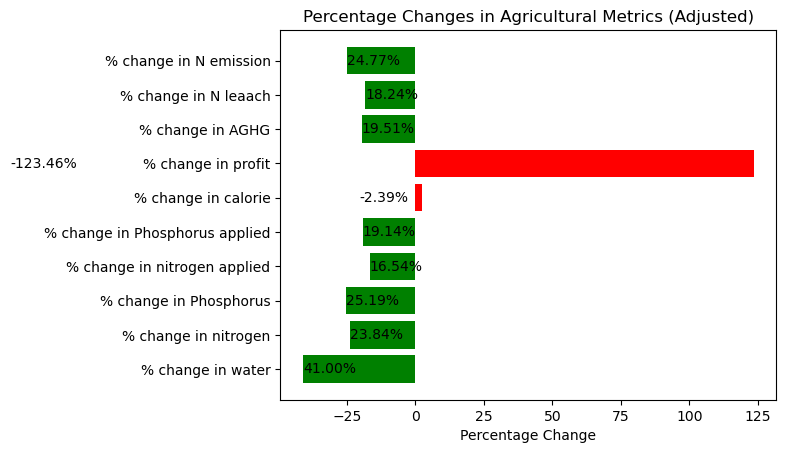

In [22]:
# Group by State and sum all numeric columns
grouped_data = merged_results_df.groupby(['State']).sum(numeric_only=True).reset_index()

# Percentage change calculations
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

# Total values and total percentage changes
total_data = merged_results_df.sum(numeric_only=True)
total_data['% change in water'] = 100 * (total_data['Original water'] - total_data['Optimized water']) / total_data['Original water']
total_data['% change in nitrogen'] = 100 * (total_data['Original Total N surplus'] - total_data['Optimized Total N surplus']) / total_data['Original Total N surplus']
total_data['% change in Phosphorus'] = 100 * (total_data['Original Total P surplus'] - total_data['Optimized Total P surplus']) / total_data['Original Total P surplus']
total_data['% change in nitrogen applied'] = 100 * (total_data['Original Total N Applied'] - total_data['Optimized Total N Applied']) / total_data['Original Total N Applied']
total_data['% change in Phosphorus applied'] = 100 * (total_data['Original Total P Applied'] - total_data['Optimized Total P Applied']) / total_data['Original Total P Applied']
total_data['% change in calorie'] = 100 * (total_data['Original Calorie'] - total_data['Optimized Calorie']) / total_data['Original Calorie']
total_data['% change in profit'] = 100 * (total_data['Original profit'] - total_data['Optimized profit']) / total_data['Original profit']
total_data['% change in AGHG'] = 100 * (total_data['Original AGHG'] - total_data['Optimized AGHG']) / total_data['Original AGHG']
total_data['% change in N emission'] = 100 * (total_data['Original N_emission'] - total_data['Optimized N_emission']) / total_data['Original N_emission']
total_data['% change in N leaach'] = 100 * (total_data['Original N_leach'] - total_data['Optimized N_leach']) / total_data['Original N_leach']

# Extracting the data for plotting directly from the total_data calculation results
percentage_changes = total_data[['% change in water', '% change in nitrogen', '% change in Phosphorus', 
            '% change in nitrogen applied', '% change in Phosphorus applied', 
            '% change in calorie', '% change in profit', '% change in AGHG','% change in N leaach','% change in N emission']]

# Converting Series to a dictionary for easier manipulation
percentage_changes_dict = percentage_changes.to_dict()

# Convert negative values to positive for plotting on the right side and determine color based on sign
values = [abs(value) for value in percentage_changes_dict.values()]
categories = list(percentage_changes_dict.keys())
colors = ['green' if value >= 0 else 'red' for value in percentage_changes_dict.values()]
# Adjusting the plot logic based on the new requirement:
# Positive values should be plotted on the negative side of the X-axis and vice versa.

# Determine the side of the bar based on the sign of the original value, reversing the logic
values_adjusted = [-abs(value) if value >= 0 else abs(value) for value in percentage_changes_dict.values()]

# Plotting with the adjusted logic
fig, ax = plt.subplots()
ax.barh(categories, values_adjusted, color=colors)
ax.set_xlabel('Percentage Change')
ax.set_title('Percentage Changes in Agricultural Metrics (Adjusted)')

# Annotating the bars with the actual percentage change values
for index, value in enumerate(percentage_changes_dict.values()):
    if value >= 0:
        ax.text(-value, index, f"{value:.2f}%", va='center', ha='left')
    else:
        ax.text(value, index, f"{value:.2f}%", va='center', ha='right')

plt.show()


In [23]:
merged_results_df

,State,District,Crop,Optimized Area (Hectare),Original Area (Hectare),Original yield,Optimized production kg,Original production kg,Optimized Total N Applied,Original Total N Applied,...,Original AGHG,Optimized N_leach,Original N_leach,Optimized N_emission,Original N_emission,Optimized water,Original water,Optimized profit,Original profit,Area (Hectare)
0,tamil nadu,ariyalur,rice,0.00,"22,184.00","4,376.04",0.00,"97,077,999.99",0.00,"3,196,154.15",...,"90,979,438.68",0.00,"646,523.83",0.00,"66,479.60",0.00,"163,921,789.74",0.00,"-98,446,799.79","22,184.00"
1,tamil nadu,ariyalur,maize,"36,736.00","12,828.00","8,839.02","324,710,386.03","113,387,000.00","4,969,825.97","1,735,434.66",...,"25,474,194.21","313,780.55","109,570.37","32,264.87","11,266.71","38,110,568.47","13,307,991.41","-323,508,957.60","-112,967,468.10","12,828.00"
2,tamil nadu,ariyalur,bajra,0.00,"1,473.00","2,355.74",0.00,"3,470,000.00",0.00,"135,015.45",...,"1,285,127.26",0.00,"21,362.05",0.00,"2,196.58",0.00,"3,939,725.14",0.00,"692,387.09","1,473.00"
3,tamil nadu,ariyalur,ragi,0.00,10.00,"3,400.00",0.00,"34,000.00",0.00,"1,148.49",...,"10,963.46",0.00,151.30,0.00,15.56,0.00,"18,531.52",0.00,"-971,777.80",10.00
4,tamil nadu,ariyalur,jowar,0.00,241.00,"1,136.93",0.00,"274,000.00",0.00,"19,733.70",...,"201,021.31",0.00,"5,232.90",0.00,538.08,0.00,"859,755.66",0.00,"514,763.80",241.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113125,tripura,west tripura,rice,"19,990.00","18,040.00","2,919.79","58,366,589.25","52,673,000.00","2,596,429.97","2,343,151.41",...,"71,668,459.93","1,094,302.18","987,554.34","61,757.28","55,732.94","139,039,244.93","125,476,136.99","-12,148,007.34","-10,962,984.12","18,040.00"
113126,tripura,west tripura,maize,0.00,"1,890.00","1,396.30",0.00,"2,639,000.00",0.00,"226,908.68",...,"2,297,225.78",0.00,"115,268.27",0.00,"6,505.20",0.00,"6,974,292.48",0.00,"1,434,685.09","1,890.00"
113127,tripura,west tripura,bajra,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
113128,tripura,west tripura,ragi,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN


In [24]:
merged_results_df.describe()

,Optimized Area (Hectare),Original Area (Hectare),Original yield,Optimized production kg,Original production kg,Optimized Total N Applied,Original Total N Applied,Optimized Total P Applied,Original Total P Applied,Optimized Total N surplus,...,Original AGHG,Optimized N_leach,Original N_leach,Optimized N_emission,Original N_emission,Optimized water,Original water,Optimized profit,Original profit,Area (Hectare)
count,"113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00",...,"113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","113,130.00","2,005.00"
mean,524.59,516.33,37.14,"1,269,682.37","1,229,248.97","52,501.25","62,907.45","17,341.79","21,445.41","35,347.45",...,"1,740,332.42","12,214.36","14,939.34","1,212.98","1,612.41","1,891,641.61","3,206,401.32","1,453,215.60","650,321.80","28,921.58"
std,"9,113.03","8,447.24",330.77,"25,186,968.47","21,533,930.45","1,021,758.78","1,033,932.15","359,387.88","364,974.21","724,847.44",...,"34,265,488.69","296,711.54","291,229.55","24,665.44","26,765.43","43,271,065.25","139,845,451.04","72,196,035.21","64,539,265.90","55,866.82"
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-557,140.77",...,0.00,"-185,305.02","-25,515.01","-19,054.21","-4,464.56",0.00,0.00,"-3,686,883,115.37","-3,874,879,139.75",1.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,450.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"5,157.00"
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"28,756.00"
max,"725,687.16","901,100.00","11,501.01","1,859,598,486.69","1,442,000,000.08","73,546,963.03","59,130,507.87","32,841,829.70","22,168,072.67","50,487,941.80",...,"2,695,067,625.41","27,466,168.10","21,377,062.47","1,802,419.52","1,903,385.04","6,491,649,630.52","40,954,369,246.89","8,630,024,657.04","7,029,173,200.37","901,100.00"


In [25]:
# -------------------------------------------------------
# New AGHG Estimation: Yield-based + CH4 from rice + N2O
# ----# Load the AGHG factor data
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data/aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq


# Build lookup tables
rice_CO2eq_perkg = aghg_df.set_index('State')['Rice_CO2eq_perkg'].to_dict()
wheat_CO2eq_perkg = aghg_df.set_index('State')['Wheat_CO2eq_perkg'].to_dict()
maize_CO2eq_perkg = aghg_df.set_index('State')['Maize_CO2eq_perkg'].to_dict()
millets_CO2eq_perkg = aghg_df.set_index('State')['Millets_CO2eq_perkg'].to_dict()
rice_ch4_per_ha = aghg_df.set_index('State')['rice_ch4_co2_eq_per_ha'].to_dict()



# Initialize total AGHG  for current aghg 
original_total_aghg = 0

for (s, d, c), area in current_cereal_area.items():
    yld = yield_data.get((s, d, c), 0)
    rs = s.strip().lower()
    ghg = 0

    if c == 'rice':
        ghg += yld * area * rice_CO2eq_perkg.get(rs, 0)
        ghg += area * rice_ch4_per_ha.get(rs, 0)
    elif c == 'wheat':
        ghg += yld * area * wheat_CO2eq_perkg.get(rs, 0)
    elif c == 'maize':
        ghg += yld * area * maize_CO2eq_perkg.get(rs, 0)
    elif c in ['bajra', 'jowar', 'ragi']:  # millets
        ghg += yld * area * millets_CO2eq_perkg.get(rs, 0)

    original_total_aghg += ghg

# Add N2O converted to CO2-eq
original_n2o_emission_kg = sum(
    area *
    nitrogen_emission_rate_perkg.get((s, d, c), 0) *
    (nitrogen_rate.get((s, d, c), 0) - yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))
    for (s, d, c), area in current_cereal_area.items()
)

original_n2o_co2eq = original_n2o_emission_kg * N2O_GWP
original_total_aghg += original_n2o_co2eq

original_total_aghg, original_n2o_co2eq







# Initialize total AGHG   for optimized version 
total_aghg = 0

for s in states:
    for d in districts:
        for c in cereals:
            area = pulp.value(x[s][d][c])  # optimized area
            yld = yield_data.get((s, d, c), 0)

            if area is None or yld == 0:
                continue

            # Get state-specific factors
            rs = s.strip().lower()
            ghg = 0

            if c == 'rice':
                ghg += yld * area * rice_CO2eq_perkg.get(rs, 0)
                ghg += area * rice_ch4_per_ha.get(rs, 0)
            elif c == 'wheat':
                ghg += yld * area * wheat_CO2eq_perkg.get(rs, 0)
            elif c == 'maize':
                ghg += yld * area * maize_CO2eq_perkg.get(rs, 0)
            elif c in ['bajra', 'jowar', 'ragi']:  # millets
                ghg += yld * area * millets_CO2eq_perkg.get(rs, 0)

            total_aghg += ghg

# ------------------------
# Add N₂O (converted to CO₂e)
# ------------------------

n2o_emission_kg = sum(
    (pulp.value(x[s][d][c]) or 0) *
    nitrogen_emission_rate_perkg.get((s, d, c), 0) *
    (nitrogen_rate.get((s, d, c), 0) - yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))
    for s in states for d in districts for c in cereals
)

n2o_co2eq = n2o_emission_kg * N2O_GWP
total_aghg += n2o_co2eq

print("\n✅ Total AGHG (optimized) in kg CO2-eq:", total_aghg)
print("✅ Total N2O converted to CO2-eq (kg):", n2o_co2eq)



✅ Total AGHG (optimized) in kg CO2-eq: 151662503498.13986
✅ Total N2O converted to CO2-eq (kg): 36375571042.51288


In [26]:
original_total_aghg, original_n2o_co2eq


(192624389300.78827, 48997810715.190056)

In [27]:
original_total_aghg-total_aghg

40961885802.64841

In [129]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# Build lookup tables
# NOTE: These per‑kg factors are **residue burning** intensities per kg of grain
rice_burn_CO2eq_perkg    = aghg_df.set_index('State')['Rice_CO2eq_perkg'].to_dict()
wheat_burn_CO2eq_perkg   = aghg_df.set_index('State')['Wheat_CO2eq_perkg'].to_dict()
maize_burn_CO2eq_perkg   = aghg_df.set_index('State')['Maize_CO2eq_perkg'].to_dict()
millets_burn_CO2eq_perkg = aghg_df.set_index('State')['Millets_CO2eq_perkg'].to_dict()
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = aghg_df.set_index('State')['rice_ch4_co2_eq_per_ha'].to_dict()


def calculate_aghg_breakdown(area_dict):
    """
    area_dict: {(state, district, crop): area_ha}
    Uses:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus (with optional N2O-N→N2O) * GWP
    Returns: (total_aghg_kgCO2e, components_dict)
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0

    # ---------- residue burning + rice CH4 ----------
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain
        rs = s.strip().lower()

        if c == 'rice':
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(rs, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(rs, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c == 'wheat':
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(rs, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c == 'maize':
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(rs, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c in ['bajra', 'jowar', 'ragi']:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(rs, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

    # ---------- soils N2O (from N surplus) ----------
    # N_surplus (kg N) = area_ha * N_applied_rate(kg/ha) - production_kg * N_removed_rate_perkg(kg N/kg grain)
    n2o_term = 0.0
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area * yld_kg_ha

        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))                 # kg N/ha
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))   # kg N/kg grain
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))  # fraction of N surplus

        n_surplus = area * n_appl - prod_kg * n_rem_perkg  # kg N
        n2o_from_nsur = n_surplus * fn2o                   # If fn2o is N2O or N2O-N depends on your coeff.
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N -> N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components


# ================
# Run both cases
# ================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {(s, d, c): (pulp.value(x[s][d][c]) or 0.0)
                       for s in states for d in districts for c in cereals}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Comparison DataFrame
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)


               Component    Original_kgCO2e   Optimized_kgCO2e  \
0     Rice_burning_CO2eq  49,677,111,287.43  41,773,089,309.01   
1         Rice_CH4_CO2eq  87,140,962,801.86  61,288,188,753.91   
2    Wheat_burning_CO2eq               0.00               0.00   
3    Maize_burning_CO2eq   4,267,387,780.92   8,627,066,555.62   
4  Millets_burning_CO2eq   2,541,116,715.40   4,043,847,191.07   
5        Soils_N2O_CO2eq  48,997,810,715.19  36,375,571,042.51   
6                  Total 192,624,389,300.79 152,107,762,852.12   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0  7,904,021,978.42        15.91            25.79  
1 25,852,774,047.95        29.67            45.24  
2              0.00         0.00             0.00  
3 -4,359,678,774.70      -102.16             2.22  
4 -1,502,730,475.68       -59.14             1.32  
5 12,622,239,672.68        25.76            25.44  
6 40,516,626,448.66        21.03           100.00  

✅ Totals match check
Original total (from breakdown): 

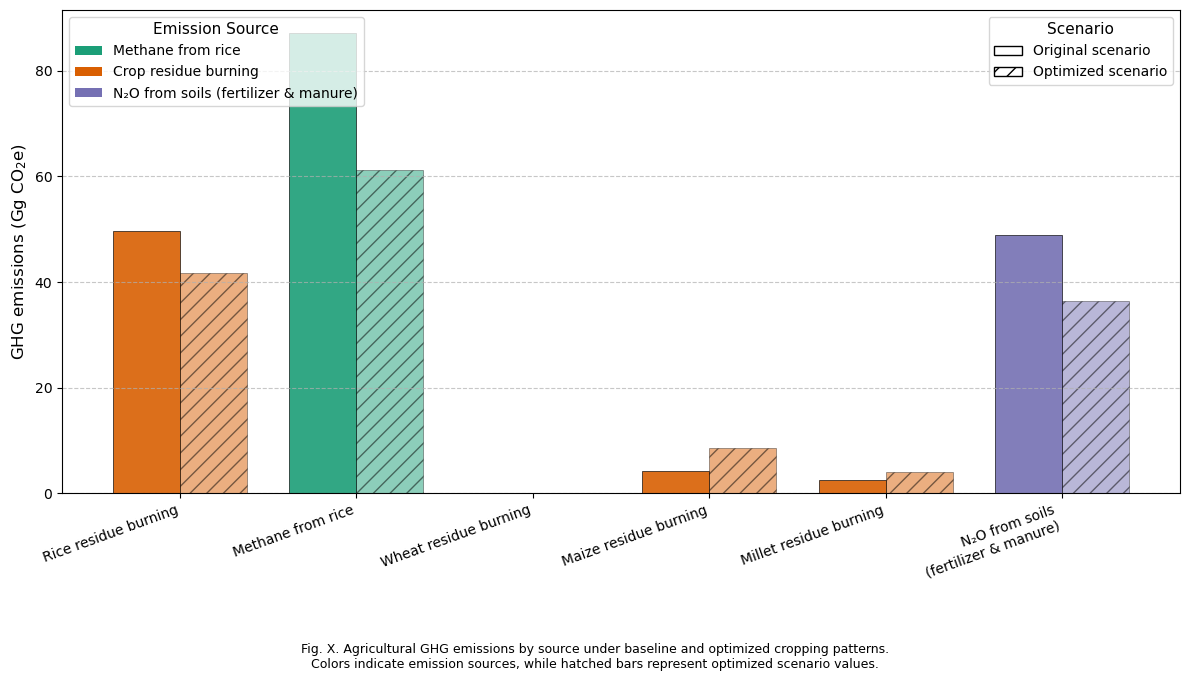

In [131]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Drop 'Total' row for plotting
df_plot = df_comp[df_comp["Component"] != "Total"].copy()

# Map each component to an emission source and color
source_colors = {
    "Rice_burning_CO2eq":     ("Crop residue burning", "#d95f02"),
    "Wheat_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Maize_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Millets_burning_CO2eq":  ("Crop residue burning", "#d95f02"),
    "Rice_CH4_CO2eq":         ("Methane from rice", "#1b9e77"),
    "Soils_N2O_CO2eq":        ("N₂O from soils (fertilizer & manure)", "#7570b3")
}

df_plot["Source"] = df_plot["Component"].map(lambda c: source_colors[c][0])
df_plot["Color"] = df_plot["Component"].map(lambda c: source_colors[c][1])

# Prepare data
components = df_plot["Component"].tolist()
orig_vals = df_plot["Original_kgCO2e"].values / 1e9  # to Gg
opt_vals  = df_plot["Optimized_kgCO2e"].values / 1e9
colors = df_plot["Color"].tolist()

x = np.arange(len(components))
width = 0.38

# Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Original bars
bars1 = ax.bar(x - width/2, orig_vals, width, label='Original scenario',
               color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)

# Optimized bars (hatched)
bars2 = ax.bar(x + width/2, opt_vals, width, label='Optimized scenario',
               color=colors, alpha=0.5, edgecolor='black', linewidth=0.5, hatch='//')

# Axis labels & ticks
ax.set_ylabel("GHG emissions (Gg CO$_2$e)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(components, rotation=30, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Custom display names for x-axis
label_map = {
    "Rice_burning_CO2eq": "Rice residue burning",
    "Rice_CH4_CO2eq": "Methane from rice",
    "Wheat_burning_CO2eq": "Wheat residue burning",
    "Maize_burning_CO2eq": "Maize residue burning",
    "Millets_burning_CO2eq": "Millet residue burning",
    "Soils_N2O_CO2eq": "N₂O from soils\n(fertilizer & manure)"
}

# Apply readable labels
xtick_labels = [label_map.get(c, c) for c in components]

# In plotting section:
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=20, ha='right', fontsize=10)

# Legend: First for emission sources, then for scenario type
source_legend = [
    Patch(facecolor="#1b9e77", label="Methane from rice"),
    Patch(facecolor="#d95f02", label="Crop residue burning"),
    Patch(facecolor="#7570b3", label="N₂O from soils (fertilizer & manure)")
]
scenario_legend = [
    Patch(facecolor='white', edgecolor='black', label='Original scenario'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimized scenario')
]

# Combine legends
first_legend = ax.legend(handles=source_legend, title="Emission Source",
                         fontsize=10, title_fontsize=11, loc='upper left')
ax.add_artist(first_legend)  # Keep first legend on plot
ax.legend(handles=scenario_legend, title="Scenario",
          fontsize=10, title_fontsize=11, loc='upper right')

# Caption-like text
fig.text(0.5, -0.08,
         "Fig. X. Agricultural GHG emissions by source under baseline and optimized cropping patterns.\n"
         "Colors indicate emission sources, while hatched bars represent optimized scenario values.",
         ha='center', va='top', fontsize=9)
save_path = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\fig\GHG_components_comparison_n_kharif.png"
#os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [ ]:
optimized total nitrogen emission 134382856.46929657
original_total_AGHG_(Mg CO2e): 333216562.1055027
 OOptimal_total_AGHG_(Mg CO2e): 233965672.32067877

In [29]:
# ------------------------------------------
# GHG Estimation using Area-based Method
# ------------------------------------------
#https://pmc.ncbi.nlm.nih.gov/articles/PMC5268357/#tbl0005
# Crop-wise GHG emission factors (kg CO2e / ha)
area_based_ghg_factor = {
    'rice': 8447.59,
    'wheat': 977.15,
    'maize': 707.32,
    'bajra': 707.32,
    'jowar': 707.32,
    'ragi': 707.32
}

# Calculate original total GHG
ghg_original_area_based = sum(
    current_cereal_area.get((s, d, c), 0) * area_based_ghg_factor.get(c, 0)
    for s in states for d in districts for c in cereals
)

# Calculate optimized total GHG
ghg_optimized_area_based = sum(
    (pulp.value(x[s][d][c]) or 0) * area_based_ghg_factor.get(c, 0)
    for s in states for d in districts for c in cereals
)

# Report
print("\n📌 GHG Estimation via Area-based Emission Factors:")
print(f"Original Total GHG (kg CO2e): {ghg_original_area_based:,.2f}")
print(f"Optimized Total GHG (kg CO2e): {ghg_optimized_area_based:,.2f}")
print(f"% Reduction: {((ghg_original_area_based - ghg_optimized_area_based) / ghg_original_area_based) * 100:.2f}%")



📌 GHG Estimation via Area-based Emission Factors:
Original Total GHG (kg CO2e): 347,311,856,287.23
Optimized Total GHG (kg CO2e): 252,083,019,191.99
% Reduction: 27.42%


In [57]:
#sensaitivity analysis 

In [143]:
import pandas as pd
import pulp
import copy

# ========================================================
# STEP 1: Define the optimization function
# ========================================================
import pulp
import pandas as pd

def run_optimization(kharif_2017, kharif_max, kharif, historical_cereal_area):
    # Copy dataframe to avoid modifying original
    df = kharif_2017.copy()

    # ======= PREPROCESSING =======
    # Renaming
    df.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'}, inplace=True)

    # Calculate net N and net P applied
    df['net_N_applied(kg/ha)'] = df['N_applied(kg/ha)'] + df['Manure (N_kg/ha)'] + df['atm_depo'] + df['BNF_kg_per_hec']
    df['net_P_applied(kg/ha)'] = df['P_applied(kg/ha)'] + df['Manure (P_kg/ha)']

    # Preprocess kharif_max
    kharif_max = kharif_max.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'})
    kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()

    # Only selected kharif crops
    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['Crop'].isin(selected_crops)]
    kharif_max = kharif_max[kharif_max['Crop'].isin(selected_crops)]

    # Max area constraints
    max_area_constraints = kharif_max.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

    # Lowercase keys for matching
    df['District'] = df['District'].str.lower().str.strip()
    df['State'] = df['State'].str.lower().str.strip()
    df['Crop'] = df['Crop'].str.lower().str.strip()

    # Fill missing N applied
    avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
    global_avg = kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
    df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
    df['net_N_applied(kg/ha)'].fillna(global_avg, inplace=True)

    # Fill missing P applied
    avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
    global_avg_P = kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
    df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)

    # Fill missing cost of production
    avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)
    global_avg_cost_cult = kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

    # Replace -1 with zero in certain columns
    df['Area (Hectare)'] = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)'] = 1000 * df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # Fill missing CWR
    avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
    global_avg_cwr = kharif.groupby(['crop'])['CWR m3/ha'].transform('mean')
    df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

    # ======= ADD EXTRA DATA =======
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}
    crop_co2e = {'bajra': 0.098603856, 'ragi': 0.098603856, 'rice': 8.213913103, 'jowar': 0.154967254, 'wheat': 0.729809876, 'maize': 0.889859651}
    AGHG_per_ha_dict = {cereal: value for cereal, value in crop_co2e.items()}

    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)
    df['AGHG_produced (per ha)'] = df['Crop'].map(AGHG_per_ha_dict)
    df['Total Calorie Supply'] = 1000 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost'] = 10 * df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply'] = 10 * df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit'] = df['Total MSP Supply'] - df['Total Farmer Cost']

    # ======= CREATE DICTIONARIES =======
    states = df['State'].unique().tolist()
    districts = df['District'].unique().tolist()
    cereals = df['Crop'].unique().tolist()

    current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
    yield_data = df.set_index(['State','District','Crop'])['YIELD (Kg per ha)'].to_dict()
    nitrogen_rate = df.set_index(['State','District','Crop'])['net_N_applied(kg/ha)'].to_dict()
    nitrogen_removal_rate_perkg = df.set_index(['State','District','Crop'])['n_removed_rate'].to_dict()
    nitrogen_leach_rate_perkg = df.set_index(['State','District','Crop'])['fno3'].to_dict()
    nitrogen_emission_rate_perkg = df.set_index(['State','District','Crop'])['fn2o'].to_dict()
    P_rate = df.set_index(['State','District','Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_removal_rate_perkg = df.set_index(['State','District','Crop'])['p_removed_rate'].to_dict()
    water_rate = df.set_index(['State','District','Crop'])['CWR m3/ha'].to_dict()
    calories_per_prod = df.set_index(['State','District','Crop'])['Calorie Supply (per KG)'].to_dict()
    AGHG_per_ha = df.set_index(['State','District','Crop'])['AGHG_produced (per ha)'].to_dict()
    district_to_state = df.set_index('District')['State'].to_dict()
    cost_per_area = df.set_index(['State','District','Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod = df.set_index(['State','District','Crop'])['MSP_RsperQntl'].to_dict()

    # ======= OPTIMIZATION =======
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)

    # Objective: Minimize N surplus
    prob += pulp.lpSum([
        x[s][d][c] * (nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
        for s in states for d in districts for c in cereals
    ])

    # Constraints
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d), 0)
    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area.get((s, d, c), 0) == 0:
                    prob += x[s][d][c] == 0
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
                            for d in districts for c in cereals]) >= initial_state_calories[s]
    initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * MSP_per_prod.get((s, d, c), 0)) -
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * cost_per_area.get((s, d, c), 0))
            for d in districts if district_to_state.get(d) == s for c in cereals
        ]) >= initial_state_profit[s]

    # Solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # ======= RESULTS =======
    optimized_total_nitrogen_surplus = sum((pulp.value(x[s][d][c])) *
        (nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
        for s in states for d in districts for c in cereals)
    optimal_water = sum((pulp.value(x[s][d][c])) * water_rate.get((s, d, c), 0)
        for s in states for d in districts for c in cereals)
    optimal_profit = sum(
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)) -
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0))
        for s in states for d in districts for c in cereals)

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "water": optimal_water,
        "profit": optimal_profit
    }

# ========================================================
# STEP 2: SENSITIVITY ANALYSIS LOOP
# ========================================================
components = ['N_applied(kg/ha)', 'Manure (N_kg/ha)', 'atm_depo', 'BNF_kg_per_hec']
perturbations = [-0.2, -0.1, 0.1, 0.2]  # -20%, -10%, +10%, +20%

# Baseline
base_results = run_optimization(kharif_2017, kharif_max, kharif, historical_cereal_area_dict)
results_list = []

for comp in components:
    for p in perturbations:
        df_test = copy.deepcopy(kharif_2017)
        df_test[comp] *= (1 + p)

        opt_results = run_optimization(df_test, kharif_max, kharif, historical_cereal_area_dict)

        results_list.append({
            "component": comp,
            "perturbation_%": p * 100,
            "N_surplus": opt_results["N_surplus"],
            "water": opt_results["water"],
            "profit": opt_results["profit"],
            "change_in_N_surplus_%": ((opt_results["N_surplus"] - base_results["N_surplus"]) / base_results["N_surplus"]) * 100,
            "change_in_water_%": ((opt_results["water"] - base_results["water"]) / base_results["water"]) * 100,
            "change_in_profit_%": ((opt_results["profit"] - base_results["profit"]) / base_results["profit"]) * 100
        })

# Save results
sensitivity_df = pd.DataFrame(results_list)
#sensitivity_df.to_csv("sensitivity_analysis_results.csv", index=False)
print(sensitivity_df)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_57492\641036870.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_57492\641036870.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

           component  perturbation_%        N_surplus              water  \
0   N_applied(kg/ha)          -20.00 3,098,188,791.83 205,471,836,236.12   
1   N_applied(kg/ha)          -10.00 3,487,648,154.33 205,831,905,013.36   
2   N_applied(kg/ha)           10.00 4,264,741,734.03 206,725,080,824.79   
3   N_applied(kg/ha)           20.00 4,652,821,914.00 206,233,840,733.77   
4   Manure (N_kg/ha)          -20.00 3,839,424,782.78 205,613,882,593.63   
5   Manure (N_kg/ha)          -10.00 3,858,348,118.53 206,611,444,739.52   
6   Manure (N_kg/ha)           10.00 3,894,512,605.52 206,367,459,860.49   
7   Manure (N_kg/ha)           20.00 3,912,489,854.79 206,367,459,860.49   
8           atm_depo          -20.00 3,861,456,327.29 206,609,658,422.31   
9           atm_depo          -10.00 3,868,966,186.81 206,609,658,422.31   
10          atm_depo           10.00 3,883,985,905.85 206,609,658,422.31   
11          atm_depo           20.00 3,891,495,765.37 206,609,658,422.31   
12    BNF_kg

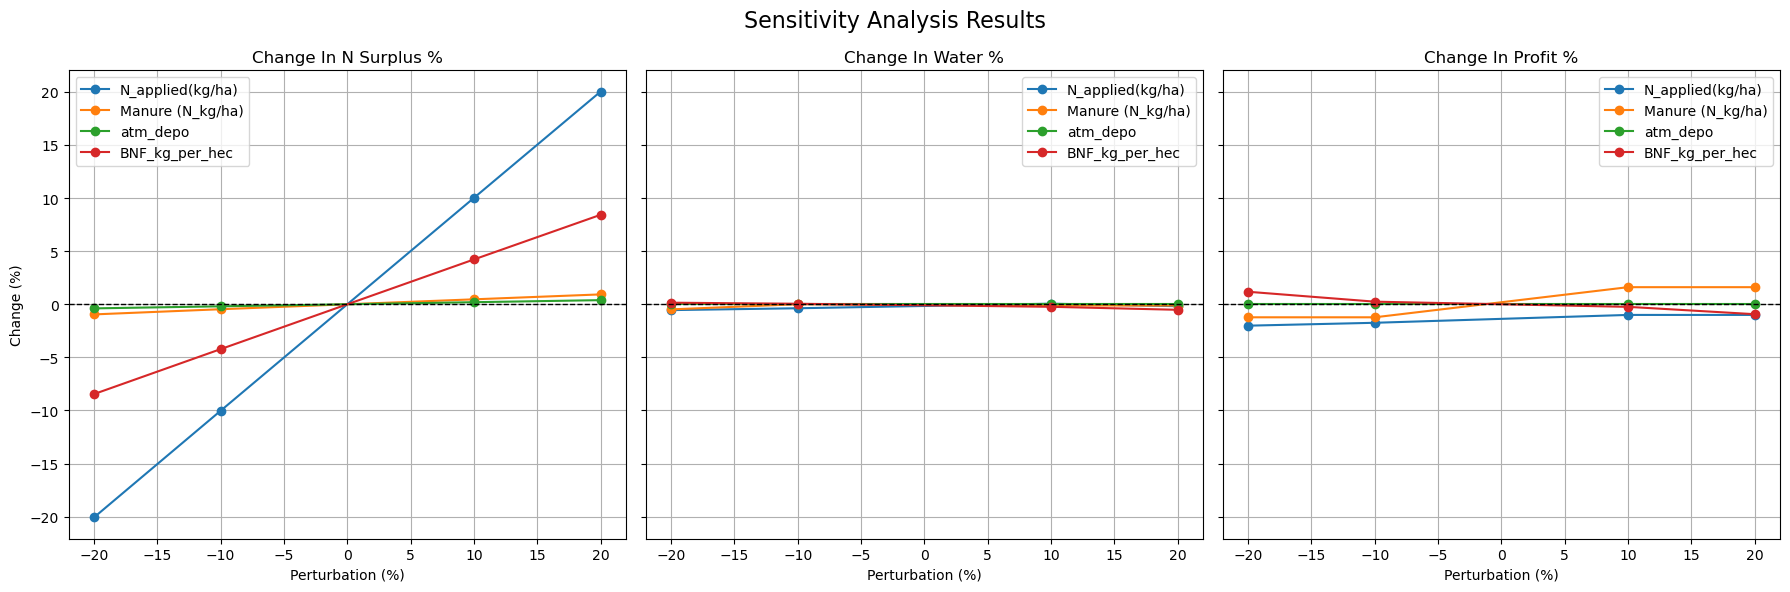

In [145]:
df = sensitivity_df

# Create subplots for each metric
metrics = ["change_in_N_surplus_%", "change_in_water_%", "change_in_profit_%"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, metric in enumerate(metrics):
    for comp in df['component'].unique():
        subset = df[df['component'] == comp]
        axes[i].plot(subset['perturbation_%'], subset[metric], marker='o', label=comp)
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].set_xlabel("Perturbation (%)")
    axes[i].set_ylabel("Change (%)" if i == 0 else "")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Sensitivity Analysis Results", fontsize=16)
plt.tight_layout()
plt.show()

In [146]:
import pandas as pd
import pulp
import copy

# ========================================================
# NEW: AGHG factors (burning per-kg CO2e + rice CH4 per-ha)
# ========================================================
AGHG_FACTORS_PATH = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv"

aghg_df = pd.read_csv(AGHG_FACTORS_PATH)
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Residue burning per-kg factors
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
# Rice CH4 per ha (already CO2e/ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# N2O constants
N2O_GWP = 273                 # AR6
USE_N2O_N = False             # Flip to True if fn2o is N2O-N fraction
MOLAR_RATIO_N2O = 44/28       # N2O-N -> N2O

# ========================================================
# STEP 1: Define the optimization function (AGHG updated)
# ========================================================
def run_optimization(kharif_2017, kharif_max, kharif, historical_cereal_area):
    # Copy dataframe to avoid modifying original
    df = kharif_2017.copy()

    # ======= PREPROCESSING =======
    # Renaming
    df.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'}, inplace=True)

    # Calculate net N and net P applied
    df['net_N_applied(kg/ha)'] = df['N_applied(kg/ha)'] + df['Manure (N_kg/ha)'] + df['atm_depo'] + df['BNF_kg_per_hec']
    df['net_P_applied(kg/ha)'] = df['P_applied(kg/ha)'] + df['Manure (P_kg/ha)']

    # Preprocess kharif_max
    kharif_max = kharif_max.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'})
    kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()

    # Only selected kharif crops
    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['Crop'].isin(selected_crops)]
    kharif_max = kharif_max[kharif_max['Crop'].isin(selected_crops)]

    # Max area constraints (if you want to use later)
    max_area_constraints = kharif_max.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

    # Lowercase keys for matching
    df['District'] = df['District'].str.lower().str.strip()
    df['State']    = df['State'].str.lower().str.strip()
    df['Crop']     = df['Crop'].str.lower().str.strip()

    # Fill missing N applied
    avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
    global_avg = kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
    df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
    df['net_N_applied(kg/ha)'].fillna(global_avg, inplace=True)

    # Fill missing P applied
    avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
    global_avg_P = kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
    df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)

    # Fill missing cost of production
    avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)
    global_avg_cost_cult = kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

    # Replace -1 with zero & yields
    df['Area (Hectare)']      = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)']   = 1000 * df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # Fill missing CWR
    avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
    global_avg_cwr = kharif.groupby(['crop'])['CWR m3/ha'].transform('mean')
    df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

    # ======= ADD NON-AGHG EXTRAS (unchanged) =======
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}

    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)
    df['Total Calorie Supply']    = 1000 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost']       = 10 * df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply']        = 10 * df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit']    = df['Total MSP Supply'] - df['Total Farmer Cost']

    # ======= CREATE DICTIONARIES =======
    states   = df['State'].unique().tolist()
    districts= df['District'].unique().tolist()
    cereals  = df['Crop'].unique().tolist()

    current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
    yield_data   = df.set_index(['State','District','Crop'])['YIELD (Kg per ha)'].to_dict()

    nitrogen_rate                 = df.set_index(['State','District','Crop'])['net_N_applied(kg/ha)'].to_dict()
    nitrogen_removal_rate_perkg   = df.set_index(['State','District','Crop'])['n_removed_rate'].to_dict()
    nitrogen_leach_rate_perkg     = df.set_index(['State','District','Crop'])['fno3'].to_dict()
    nitrogen_emission_rate_perkg  = df.set_index(['State','District','Crop'])['fn2o'].to_dict()

    P_rate               = df.set_index(['State','District','Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_removal_rate_perkg = df.set_index(['State','District','Crop'])['p_removed_rate'].to_dict()

    water_rate        = df.set_index(['State','District','Crop'])['CWR m3/ha'].to_dict()
    calories_per_prod = df.set_index(['State','District','Crop'])['Calorie Supply (per KG)'].to_dict()
    district_to_state = df.set_index('District')['State'].to_dict()
    cost_per_area     = df.set_index(['State','District','Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod      = df.set_index(['State','District','Crop'])['MSP_RsperQntl'].to_dict()

    # ======= NEW: per-record AGHG calculator =======
    def aghg_from_area(s, d, c, area_ha):
        """Total AGHG (kg CO2e) for one (s,d,c,area), using your new method."""
        area_ha = float(area_ha or 0.0)
        if area_ha <= 0:
            return 0.0

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area_ha * yld_kg_ha

        total = 0.0
        # Residue burning + rice CH4
        if c_key == "rice":
            total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            total += area_ha * float(rice_ch4_per_ha.get(s_key, 0.0))
        elif c_key == "wheat":
            total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
        elif c_key == "maize":
            total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
        elif c_key in ["bajra", "jowar", "ragi"]:
            total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
        # Soils N2O from N surplus
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus      = area_ha * n_appl - prod_kg * n_rem_perkg     # kg N
        n2o_from_nsur  = n_surplus * fn2o                             # N2O or N2O-N
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O                          # N2O-N -> N2O
        total += n2o_from_nsur * N2O_GWP                              # kg CO2e

        return total

    # ======= OPTIMIZATION =======
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)

    # Objective: Minimize N surplus (unchanged)
    prob += pulp.lpSum([
        x[s][d][c] * (nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
        for s in states for d in districts for c in cereals
    ])

    # Constraints (unchanged)
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d), 0)

    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area.get((s, d, c), 0) == 0:
                    prob += x[s][d][c] == 0

    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
                            for d in districts for c in cereals]) >= initial_state_calories[s]

    initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * MSP_per_prod.get((s, d, c), 0)) -
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * cost_per_area.get((s, d, c), 0))
            for d in districts if district_to_state.get(d) == s for c in cereals
        ]) >= initial_state_profit[s]

    # Solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # ======= RESULTS (now also calorie + AGHG) =======
    optimized_total_nitrogen_surplus = sum(
        (pulp.value(x[s][d][c])) *
        (nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
        for s in states for d in districts for c in cereals
    )
    optimal_water = sum(
        (pulp.value(x[s][d][c])) * water_rate.get((s, d, c), 0)
        for s in states for d in districts for c in cereals
    )
    optimal_profit = sum(
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)) -
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0))
        for s in states for d in districts for c in cereals
    )
    optimal_calorie = sum(
        (pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
        for s in states for d in districts for c in cereals
    )
    # NEW: total AGHG using updated method
    optimal_aghg = sum(
        aghg_from_area(s, d, c, pulp.value(x[s][d][c]))
        for s in states for d in districts for c in cereals
    )

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "water": optimal_water,
        "profit": optimal_profit,
        "calorie": optimal_calorie,
        "aghg": optimal_aghg
    }

# ========================================================
# STEP 2: SENSITIVITY ANALYSIS LOOP (adds AGHG + Calorie)
# ========================================================
components = ['N_applied(kg/ha)', 'Manure (N_kg/ha)', 'atm_depo', 'BNF_kg_per_hec']
perturbations = [-0.2, -0.1, 0.1, 0.2]  # -20%, -10%, +10%, +20%

# Baseline
base_results = run_optimization(kharif_2017, kharif_max, kharif, historical_cereal_area_dict)

def pct_change(new, base):
    return 0.0 if (base is None or base == 0) else ((new - base) / base) * 100.0

results_list = []
for comp in components:
    for p in perturbations:
        df_test = copy.deepcopy(kharif_2017)
        df_test[comp] *= (1 + p)

        opt_results = run_optimization(df_test, kharif_max, kharif, historical_cereal_area_dict)

        results_list.append({
            "component": comp,
            "perturbation_%": p * 100,

            # core outcomes
            "N_surplus": opt_results["N_surplus"],
            "water":     opt_results["water"],
            "profit":    opt_results["profit"],
            "calorie":   opt_results["calorie"],
            "aghg":      opt_results["aghg"],

            # percent changes vs baseline
            "change_in_N_surplus_%": pct_change(opt_results["N_surplus"], base_results["N_surplus"]),
            "change_in_water_%":     pct_change(opt_results["water"],     base_results["water"]),
            "change_in_profit_%":    pct_change(opt_results["profit"],    base_results["profit"]),
            "change_in_calorie_%":   pct_change(opt_results["calorie"],   base_results["calorie"]),
            "change_in_aghg_%":      pct_change(opt_results["aghg"],      base_results["aghg"]),
        })

# Save or inspect results
sensitivity_df = pd.DataFrame(results_list)
print(sensitivity_df)
# sensitivity_df.to_csv("sensitivity_analysis_results.csv", index=False)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_57492\2494476734.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_57492\2494476734.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

           component  perturbation_%        N_surplus              water  \
0   N_applied(kg/ha)          -20.00 3,098,188,791.83 205,471,836,236.12   
1   N_applied(kg/ha)          -10.00 3,487,648,154.33 205,831,905,013.36   
2   N_applied(kg/ha)           10.00 4,264,741,734.03 206,725,080,824.79   
3   N_applied(kg/ha)           20.00 4,652,821,914.00 206,233,840,733.77   
4   Manure (N_kg/ha)          -20.00 3,839,424,782.78 205,613,882,593.63   
5   Manure (N_kg/ha)          -10.00 3,858,348,118.53 206,611,444,739.52   
6   Manure (N_kg/ha)           10.00 3,894,512,605.52 206,367,459,860.49   
7   Manure (N_kg/ha)           20.00 3,912,489,854.79 206,367,459,860.49   
8           atm_depo          -20.00 3,861,456,327.29 206,609,658,422.31   
9           atm_depo          -10.00 3,868,966,186.81 206,609,658,422.31   
10          atm_depo           10.00 3,883,985,905.85 206,609,658,422.31   
11          atm_depo           20.00 3,891,495,765.37 206,609,658,422.31   
12    BNF_kg

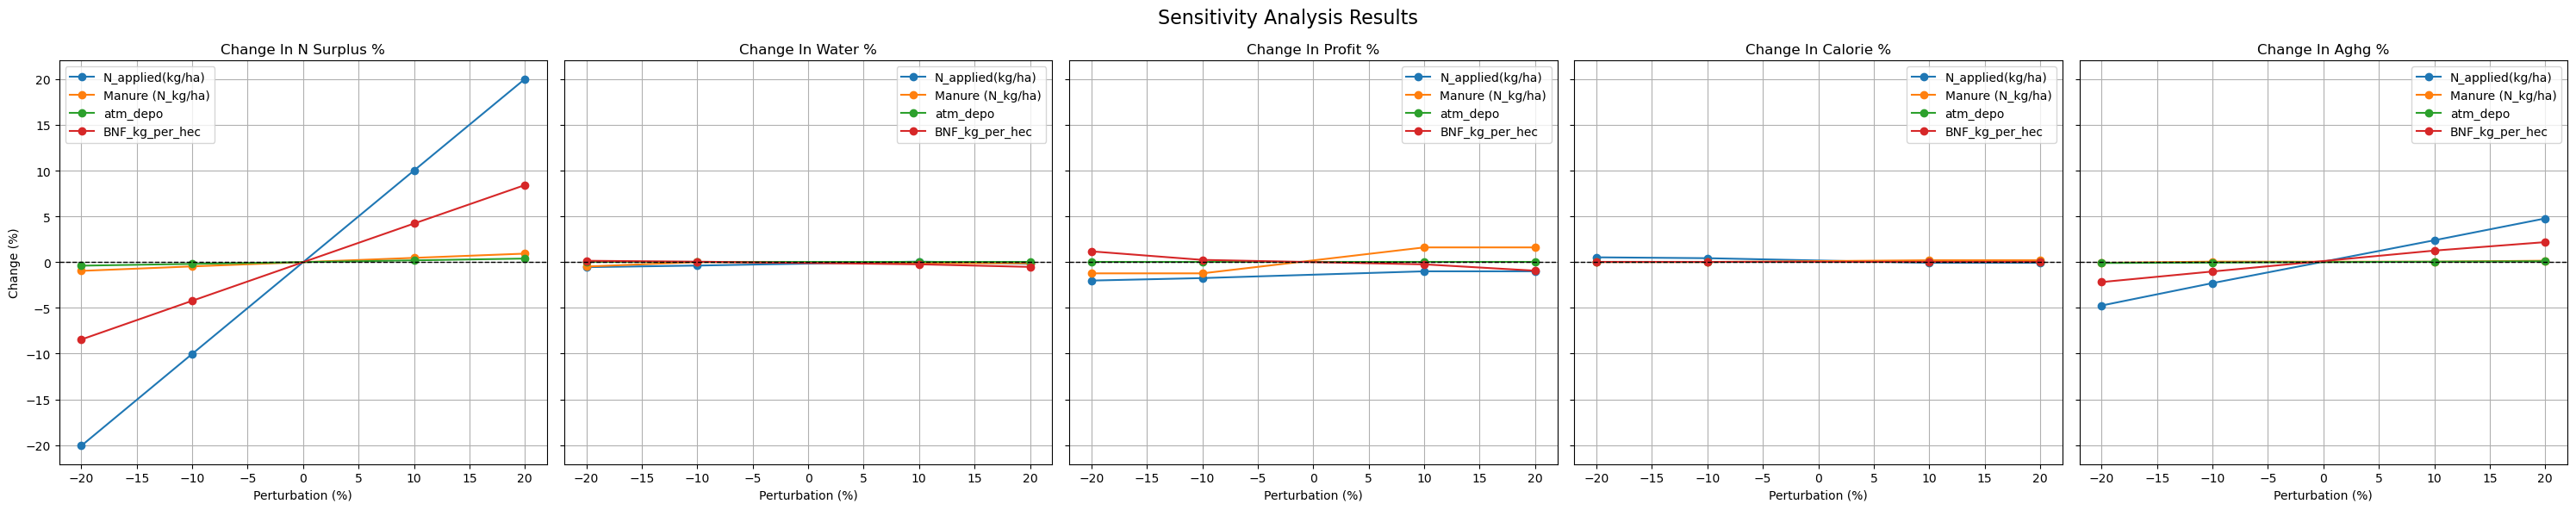

In [148]:
# Make subplots count match metrics length
metrics = ["change_in_N_surplus_%", "change_in_water_%", "change_in_profit_%",
           "change_in_calorie_%", "change_in_aghg_%"]

fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6), sharey=True)

for i, metric in enumerate(metrics):
    for comp in df['component'].unique():
        subset = df[df['component'] == comp].sort_values('perturbation_%')
        axes[i].plot(subset['perturbation_%'], subset[metric], marker='o', label=comp)
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].set_xlabel("Perturbation (%)")
    axes[i].set_ylabel("Change (%)" if i == 0 else "")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Sensitivity Analysis Results", fontsize=16)
plt.tight_layout()
plt.show()


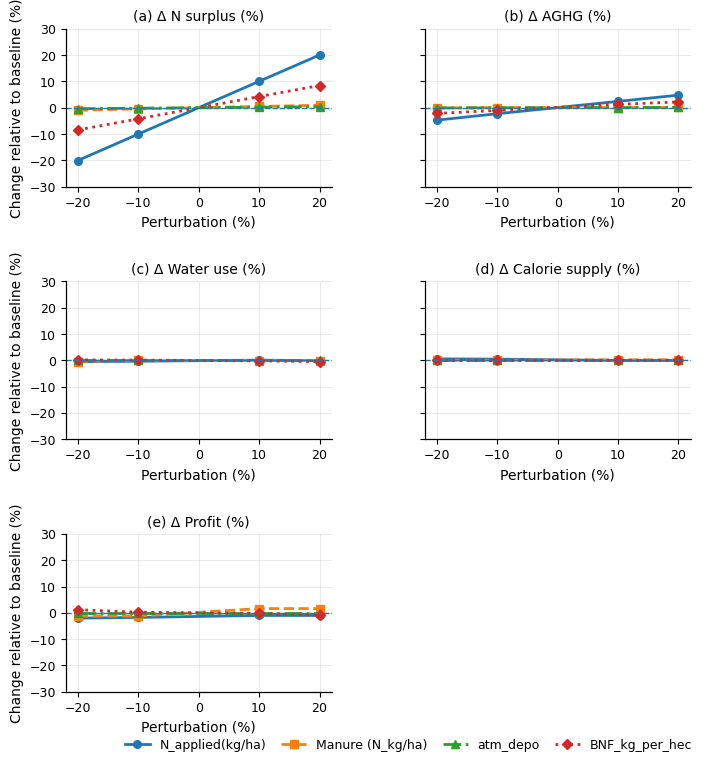

In [154]:
import matplotlib.pyplot as plt
import numpy as np
import math

df = sensitivity_df.copy()

# ----- What to plot (reordered for readability) -----
metrics = [
    "change_in_N_surplus_%",
    "change_in_aghg_%",
    "change_in_water_%",
    "change_in_calorie_%",
    "change_in_profit_%"
]
titles = {
    "change_in_N_surplus_%": "Δ N surplus (%)",
    "change_in_aghg_%":      "Δ AGHG (%)",
    "change_in_water_%":     "Δ Water use (%)",
    "change_in_calorie_%":   "Δ Calorie supply (%)",
    "change_in_profit_%":    "Δ Profit (%)",
}
panel_letters = ["a", "b", "c", "d", "e"]

# ----- Matplotlib styling (publication-friendly) -----
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,            # base font
    "axes.titlesize": 10,      # panel title
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
})

# Grid: 2 columns x 3 rows (two-column layout ~7.1 in wide)
cols = 2
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(7.1, 8.5), sharey=True)
axes = np.array(axes).reshape(-1)

components = list(df["component"].unique())
marker_cycle    = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyle_cycle = ["-", "--", "-.", ":"]

# X placement
df["perturbation_%"] = df["perturbation_%"].astype(float)
x_ticks = [-20, -10, 0, 10, 20]

# Fixed symmetric y-axis across ALL panels
YMAX = 30
y_ticks = np.arange(-30, 31, 10)

handles_for_legend = labels_for_legend = None

for i, metric in enumerate(metrics):
    ax = axes[i]
    for j, comp in enumerate(components):
        subset = df[df["component"] == comp].sort_values("perturbation_%")
        ax.plot(
            subset["perturbation_%"],
            subset[metric],
            marker=marker_cycle[j % len(marker_cycle)],
            linestyle=linestyle_cycle[j % len(linestyle_cycle)],
            markersize=5.5,
            label=comp
        )

    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_title(f"({panel_letters[i]}) {titles[metric]}")
    ax.set_xlabel("Perturbation (%)")
    if i % cols == 0:
        ax.set_ylabel("Change relative to baseline (%)")

    ax.set_xticks(x_ticks)
    ax.set_ylim(-YMAX, YMAX)
    ax.set_yticks(y_ticks)
    ax.grid(True, linewidth=0.6, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if handles_for_legend is None:
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()

# Hide any unused subplot (6th slot)
if len(metrics) < rows * cols:
    for j in range(len(metrics), rows * cols):
        fig.delaxes(axes[j])

# --- Shared legend in the LOWER RIGHT ---
fig.subplots_adjust(top=0.88, bottom=0.10, left=0.10, right=0.98, wspace=0.35, hspace=0.6)

if handles_for_legend:
    fig.legend(
        handles_for_legend,
        labels_for_legend,
        loc="lower right",                 # <-- lower-right placement
        bbox_to_anchor=(0.995, 0.02),      # nudge inside the corner
        ncol=len(labels_for_legend),       # one row (your 4 items fit)
        frameon=False,
        columnspacing=1.2,
        handlelength=2.0,
        borderaxespad=0.3
    )


# Save high-quality outputs
outdir = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\sensitivity"
fname  = "sensitivity_n_componnet_n_kharif"
plt.savefig(fr"{outdir}\{fname}.png", dpi=600, bbox_inches="tight")

plt.show()


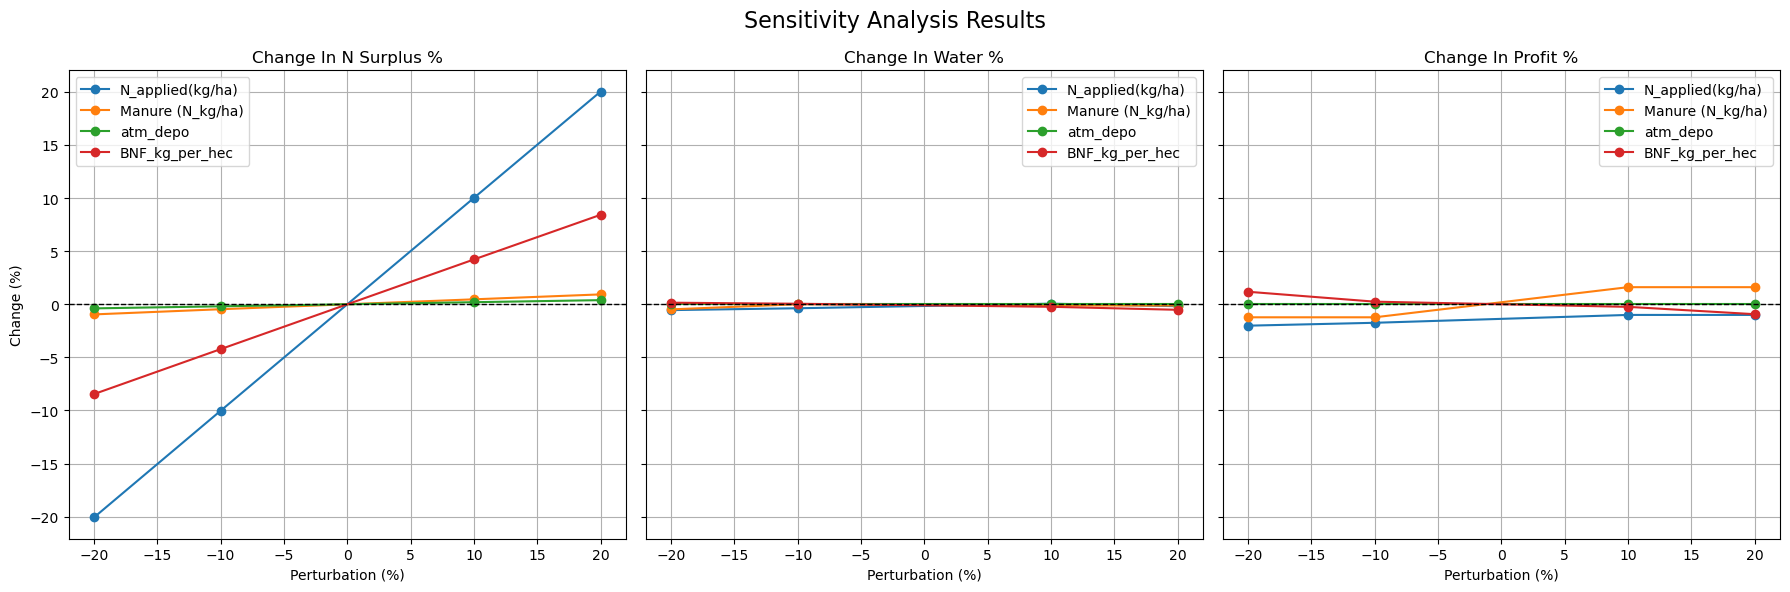

In [137]:
df = sensitivity_df

# Create subplots for each metric
metrics = ["change_in_N_surplus_%", "change_in_water_%", "change_in_profit_%"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, metric in enumerate(metrics):
    for comp in df['component'].unique():
        subset = df[df['component'] == comp]
        axes[i].plot(subset['perturbation_%'], subset[metric], marker='o', label=comp)
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].set_xlabel("Perturbation (%)")
    axes[i].set_ylabel("Change (%)" if i == 0 else "")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Sensitivity Analysis Results", fontsize=16)
plt.tight_layout()
plt.show()

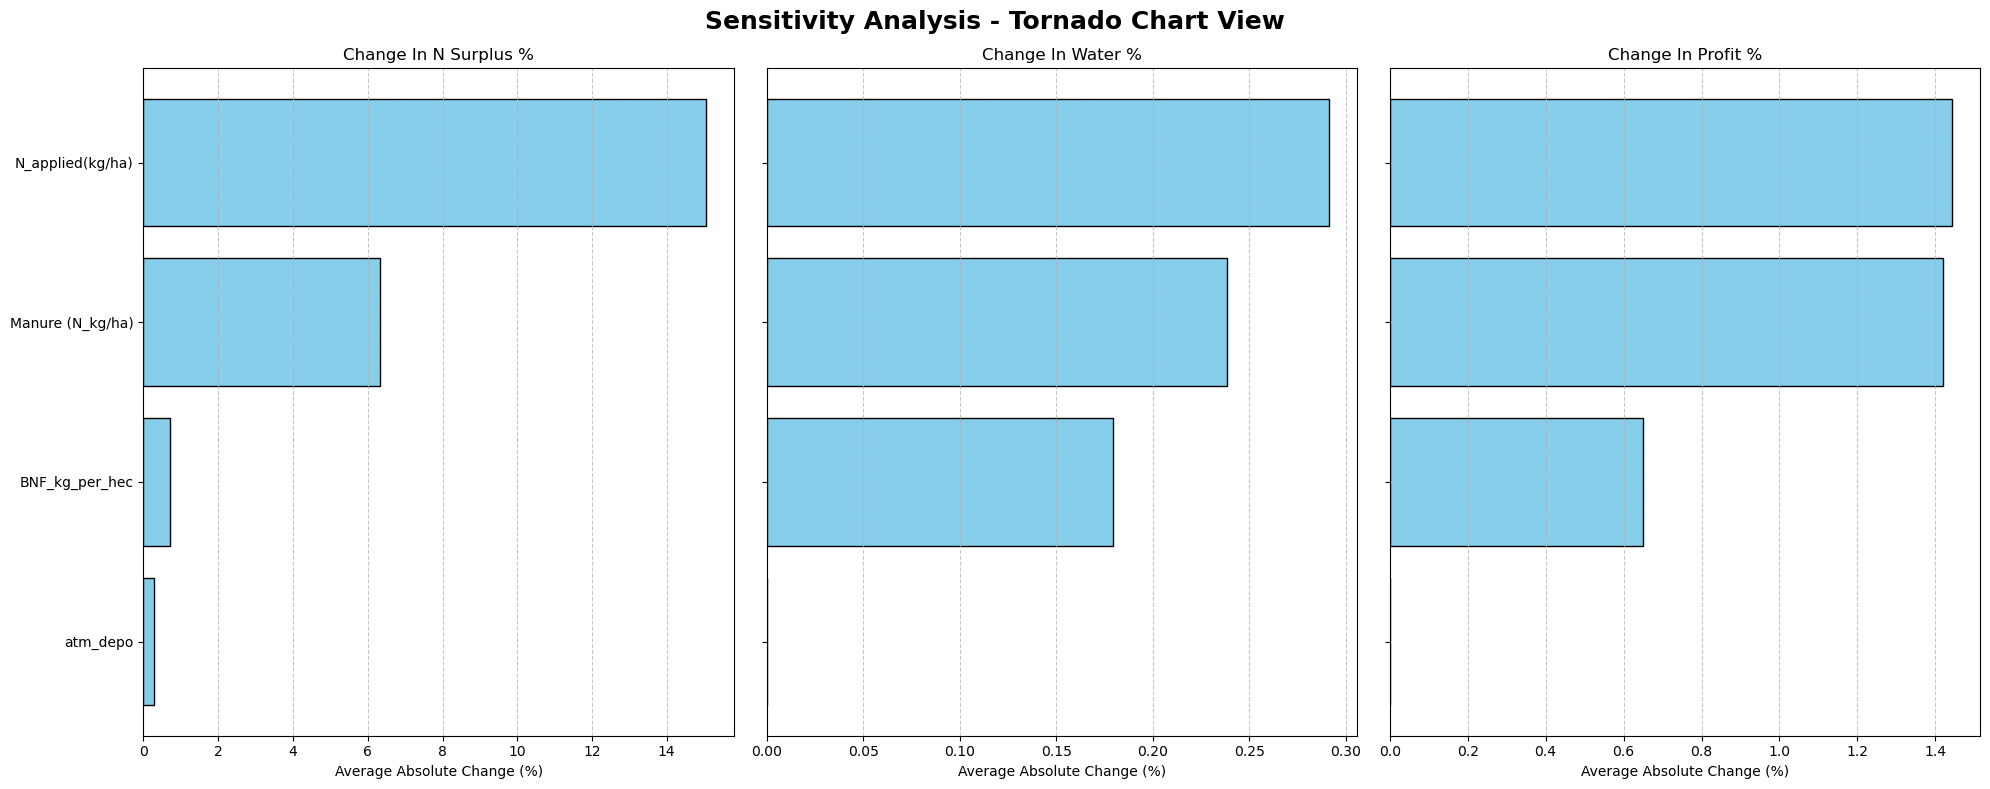

In [66]:
# Better visual: Tornado-style bar charts for each metric
import numpy as np

# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for i, metric in enumerate(metrics):
    # Calculate average absolute change for ranking
    ranking = (df.groupby('component')[metric]
               .apply(lambda x: np.mean(np.abs(x)))
               .sort_values(ascending=True))

    # For tornado plot, sort by absolute impact
    sorted_components = ranking.index.tolist()
    y_positions = np.arange(len(sorted_components))

    # Plot bars (average absolute change)
    axes[i].barh(y_positions, ranking.values, color='skyblue', edgecolor='black')
    axes[i].set_yticks(y_positions)
    axes[i].set_yticklabels(sorted_components)
    axes[i].set_xlabel("Average Absolute Change (%)")
    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle("Sensitivity Analysis - Tornado Chart View", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


          component scenario  Water  N_surplus  P_surplus  N_application  \
0  N_applied(kg/ha)     -10%   0.60      -9.22      -0.07          -6.97   
1  N_applied(kg/ha)     +10%   1.20       9.20       0.90           6.66   
2  Manure (N_kg/ha)     -10%   0.58      -0.95       0.83          -0.87   
3  Manure (N_kg/ha)     +10%   0.82       0.91      -0.05           0.55   
4          atm_depo     -10%   0.00      -0.14       0.00          -0.11   

   P_application  Calories  Profit  AGHG  N_leach  N_emission  
0          -0.17     -0.48   -0.18  0.67    -8.95       -9.23  
1           0.44     -0.50   -7.91  3.03     8.93        9.21  
2           0.39     -0.48   -9.24  2.80    -1.02       -0.94  
3          -0.16     -0.50    0.65  0.82     1.00        0.90  
4           0.00      0.00    0.00  0.00    -0.16       -0.15  


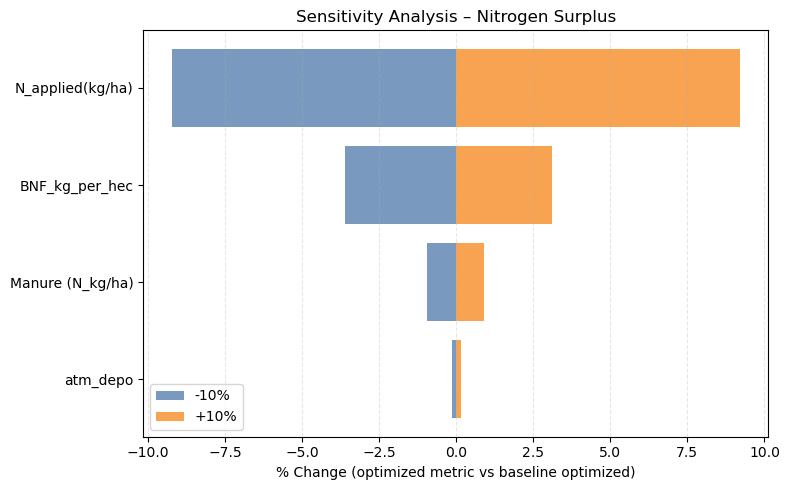

In [36]:
import numpy as np
import pulp
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Main Optimization Function
# ===============================
def run_model_with_modifier(modifier):
    # ---- Copy data ----
    df = kharif_2017.copy()

    # ---- Apply component multipliers (if provided) ----
    for comp, factor in modifier.items():
        if comp in df.columns:
            df[comp] = df[comp] * factor

    # ---- Recompute net N and P applied ----
    df['net_N_applied(kg/ha)'] = (
        df['N_applied(kg/ha)'] +
        df['Manure (N_kg/ha)'] +
        df['atm_depo'] +
        df['BNF_kg_per_hec']
    )
    df['net_P_applied(kg/ha)'] = (
        df['P_applied(kg/ha)'] +
        df['Manure (P_kg/ha)']
    )

    # ===============================
    # START (same as your original, minimal edits)
    # ===============================
    df = df.copy()
    df.rename(columns={'district': 'District'}, inplace=True, errors='ignore')
    df.rename(columns={'state': 'State'}, inplace=True, errors='ignore')
    df.rename(columns={'crop': 'Crop'}, inplace=True, errors='ignore')

    kharif_max.rename(columns={'district': 'District'}, inplace=True, errors='ignore')
    kharif_max.rename(columns={'state': 'State'}, inplace=True, errors='ignore')
    kharif_max.rename(columns={'crop': 'Crop'}, inplace=True, errors='ignore')
    kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()

    # Filter crops
    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['Crop'].isin(selected_crops)]
    kharif_max_f = kharif_max[kharif_max['Crop'].isin(selected_crops)]

    # Max area constraints dict
    max_area_constraints = kharif_max_f.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

    # Standardize case/spacing
    df['District'] = df['District'].str.lower().str.strip()
    df['State']    = df['State'].str.lower().str.strip()
    df['Crop']     = df['Crop'].str.lower().str.strip()

    # Fill NaNs for net N/P applied
    df['net_N_applied(kg/ha)'] = df['net_N_applied(kg/ha)'].fillna(df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean'))
    if df['net_N_applied(kg/ha)'].isnull().any():
        df['net_N_applied(kg/ha)'] = df['net_N_applied(kg/ha)'].fillna(kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean'))

    df['net_P_applied(kg/ha)'] = df['net_P_applied(kg/ha)'].fillna(df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean'))
    if df['net_P_applied(kg/ha)'].isnull().any():
        df['net_P_applied(kg/ha)'] = df['net_P_applied(kg/ha)'].fillna(kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean'))

    # Fill cost of cultivation
    df['Cost_of_Production_rs_Quintal'] = df['Cost_of_Production_rs_Quintal'].fillna(df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean'))
    if df['Cost_of_Production_rs_Quintal'].isnull().any():
        df['Cost_of_Production_rs_Quintal'] = df['Cost_of_Production_rs_Quintal'].fillna(kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean'))

    # Replace -1s with 0
    df['Area (Hectare)']      = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)']   = 1000*df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # Fill CWR
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(df.groupby(['Crop'])['CWR m3/ha'].transform('mean'))
    if df['CWR m3/ha'].isnull().any():
        df['CWR m3/ha'] = df['CWR m3/ha'].fillna(kharif.groupby(['crop'])['CWR m3/ha'].transform('mean'))
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

    # Yield dictionary
    yield_data = df.set_index(['State','District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

    # Calorie mapping
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}
    crop_co2e = {'bajra': 0.098603856,'ragi': 0.098603856,'rice': 8.213913103,'jowar': 0.154967254,'wheat': 0.729809876,'maize': 0.889859651}
    AGHG_per_ha_dict = {cereal: value for cereal, value in crop_co2e.items()}

    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)
    df['AGHG_produced (per ha)']  = df['Crop'].map(AGHG_per_ha_dict)
    df['Total Calorie Supply']    = 1000*df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost']       = 10*df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply']        = 10*df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit']    = df['Total MSP Supply'] - df['Total Farmer Cost']

    # Dicts
    districts = df['District'].unique().tolist()
    states    = df['State'].unique().tolist()
    cereals   = df['Crop'].unique().tolist()

    current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
    nitrogen_rate = df.set_index(['State','District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
    nitrogen_removal_rate_perkg = df.set_index(['State','District', 'Crop'])['n_removed_rate'].to_dict()
    nitrogen_leach_rate_perkg   = df.set_index(['State','District', 'Crop'])['fno3'].to_dict()
    nitrogen_emission_rate_perkg= df.set_index(['State','District', 'Crop'])['fn2o'].to_dict()
    P_rate = df.set_index(['State','District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_removal_rate_perkg = df.set_index(['State','District', 'Crop'])['p_removed_rate'].to_dict()
    water_rate = df.set_index(['State','District', 'Crop'])['CWR m3/ha'].to_dict()
    calories_per_prod = df.set_index(['State','District', 'Crop'])['Calorie Supply (per KG)'].to_dict()
    AGHG_per_ha = df.set_index(['State','District', 'Crop'])['AGHG_produced (per ha)'].to_dict()
    district_to_state = df.set_index('District')['State'].to_dict()
    cost_per_area = df.set_index(['State','District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod  = df.set_index(['State','District', 'Crop'])['MSP_RsperQntl'].to_dict()
    current_cereal_area = {(row['State'],row['District'], row['Crop']): row['Area (Hectare)'] for _,row in df.iterrows()}
    current_cereal_prod = {(row['State'],row['District'], row['Crop']): row['Production (Tonnes)'] for _,row in df.iterrows()}

    # Baseline N surplus (not returned; here just for parity)
    _ = sum(
        (current_cereal_area.get((s,d,c),0) * nitrogen_rate.get((s,d,c),0)) -
        (1000*current_cereal_prod.get((s,d,c),0) * nitrogen_removal_rate_perkg.get((s,d,c),0))
        for s in states for d in districts for c in cereals
    )

    # LP: minimize sum_x area * (N_appl - yield * N_removed/kg)
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states,districts,cereals), 0, None, pulp.LpContinuous)
    prob += pulp.lpSum([
        x[s][d][c]*(nitrogen_rate.get((s,d,c),0) - (yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)))
        for s in states for d in districts for c in cereals
    ])

    # Area constraints
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d),0)

    # Max area constraints
    for s in states:
        for d in districts:
            for c in cereals:
                if (s,d,c) in max_area_constraints:
                    prob += x[s][d][c] <= max_area_constraints[(s,d,c)]

    # Historical presence constraint
    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area.get((s,d,c),0) == 0:
                    prob += x[s][d][c] == 0

    # State calories >= baseline
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum(
            [x[s][d][c] * yield_data.get((s,d,c),0) * calories_per_prod.get((s,d,c),0)
             for d in districts for c in cereals]
        ) >= initial_state_calories[s]

    # State profit >= baseline
    initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*MSP_per_prod.get((s,d,c),0)) -
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*cost_per_area.get((s,d,c),0))
            for d in districts if district_to_state.get(d) == s for c in cereals
        ]) >= initial_state_profit[s]

    # Solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # ---- Optimized totals (ALL metrics you want) ----
    # Surpluses
    optimized_total_nitrogen_surplus = sum(
        (pulp.value(x[s][d][c]))*(nitrogen_rate.get((s,d,c),0) -
                                  (yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)))
        for s in states for d in districts for c in cereals
    )
    optimized_total_P_surplus = sum(
        (pulp.value(x[s][d][c]))*(P_rate.get((s,d,c),0) -
                                  (yield_data.get((s,d,c),0)*P_removal_rate_perkg.get((s,d,c),0)))
        for s in states for d in districts for c in cereals
    )

    # Applied
    optimized_total_N_applied = sum(
        (pulp.value(x[s][d][c])) * nitrogen_rate.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )
    optimized_total_P_applied = sum(
        (pulp.value(x[s][d][c])) * P_rate.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )

    # Water, Profit, AGHG
    optimal_water = sum(
        (pulp.value(x[s][d][c]))* water_rate.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )
    optimal_profit = sum(
        ((0.01*pulp.value(x[s][d][c]))*yield_data.get((s,d,c),0)*MSP_per_prod.get((s,d,c),0)) -
        ((0.01*pulp.value(x[s][d][c]))*yield_data.get((s,d,c),0)*cost_per_area.get((s,d,c),0))
        for s in states for d in districts for c in cereals
    )
    optimal_AGHG = sum(
        (pulp.value(x[s][d][c]))*AGHG_per_ha.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )

    # Calories
    optimal_calories = sum(
        (pulp.value(x[s][d][c])) * yield_data.get((s,d,c),0) * calories_per_prod.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )

    # N leach / N emission (fractions of N surplus)
    optimal_N_leach = sum(
        (pulp.value(x[s][d][c])) *
        (nitrogen_rate.get((s,d,c),0) - yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)) *
        nitrogen_leach_rate_perkg.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )
    optimal_N_emission = sum(
        (pulp.value(x[s][d][c])) *
        (nitrogen_rate.get((s,d,c),0) - yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)) *
        nitrogen_emission_rate_perkg.get((s,d,c),0)
        for s in states for d in districts for c in cereals
    )

    # ===============================
    # END
    # ===============================
    return {
        'Water':          optimal_water,
        'N_surplus':      optimized_total_nitrogen_surplus,
        'P_surplus':      optimized_total_P_surplus,
        'N_application':  optimized_total_N_applied,
        'P_application':  optimized_total_P_applied,
        'Calories':       optimal_calories,
        'Profit':         optimal_profit,
        'AGHG':           optimal_AGHG,
        'N_leach':        optimal_N_leach,
        'N_emission':     optimal_N_emission,
    }

# ===============================
# Sensitivity Analysis (±10%) for all desired metrics
# ===============================
desired_metrics = [
    'Water','N_surplus','P_surplus',
    'N_application','P_application',
    'Calories','Profit',
    'AGHG','N_leach','N_emission'
]
metric_labels = [
    'Water Demand','Nitrogen Surplus','Phosphorus Surplus',
    'Nitrogen application','Phosphorus application',
    'Calorie','Profit',
    'Greenhouse Gas emission','Nitrogen Leach','Nitrogen Emission'
]
label_map = dict(zip(desired_metrics, metric_labels))

components = ["N_applied(kg/ha)", "Manure (N_kg/ha)", "atm_depo", "BNF_kg_per_hec"]

baseline = run_model_with_modifier({})
sens_results = []
for comp in components:
    for change in [-0.1, 0.1]:
        factor = 1 + change
        res = run_model_with_modifier({comp: factor})
        # % change vs baseline for each desired metric
        changes = {}
        for m in desired_metrics:
            base_val = baseline[m]
            new_val  = res[m]
            changes[m] = (100.0*(new_val - base_val)/base_val) if base_val not in (0, None) else np.nan
        sens_results.append({"component": comp, "scenario": f"{int(change*100):+d}%", **changes})

sens_df = pd.DataFrame(sens_results)
print(sens_df.head())

# ===============================
# Tornado Chart Helper
# ===============================
def plot_tornado(metric_key, df=sens_df, label_map=label_map, figsize=(8,5)):
    """
    Horizontal bars for -10% and +10% scenarios across components for one metric.
    """
    if metric_key not in df.columns:
        raise KeyError(f"Metric '{metric_key}' not in sensitivity DataFrame.")
    title = f"Sensitivity Analysis – {label_map.get(metric_key, metric_key)}"

    df_plot = df.pivot(index="component", columns="scenario", values=metric_key)
    # Ensure both columns exist
    for col in ['-10%', '+10%']:
        if col not in df_plot.columns:
            df_plot[col] = np.nan
    # Sort by max absolute change
    df_plot["max_abs_change"] = df_plot[['-10%','+10%']].abs().max(axis=1)
    df_plot = df_plot.sort_values("max_abs_change", ascending=True)

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(df_plot.index, df_plot["-10%"], color="#4C78A8", alpha=0.75, label="-10%")
    ax.barh(df_plot.index, df_plot["+10%"], color="#F58518", alpha=0.75, label="+10%")
    ax.set_xlabel("% Change (optimized metric vs baseline optimized)")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example: plot tornado for Nitrogen Surplus
plot_tornado('N_surplus')

# You can also loop all metrics:
# for m in desired_metrics:
#     plot_tornado(m)


In [ ]:
#boot strapping fix in abopve code 

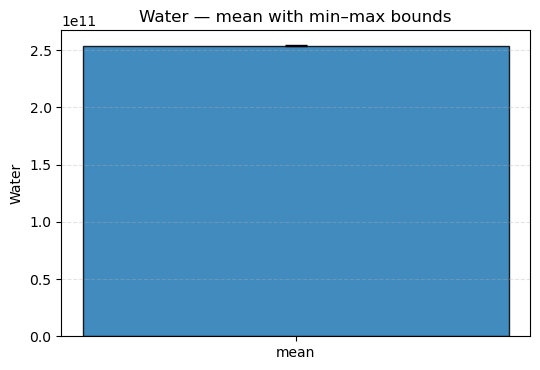

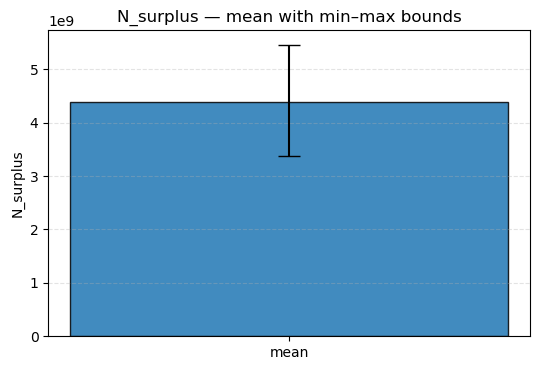

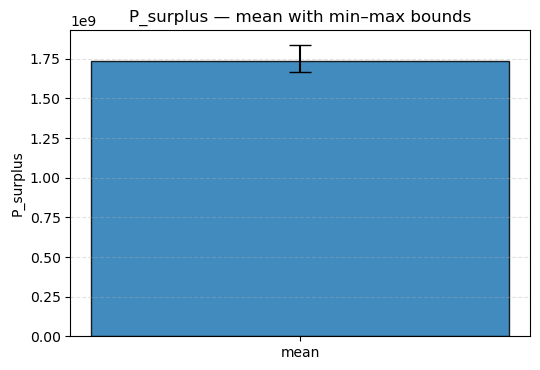

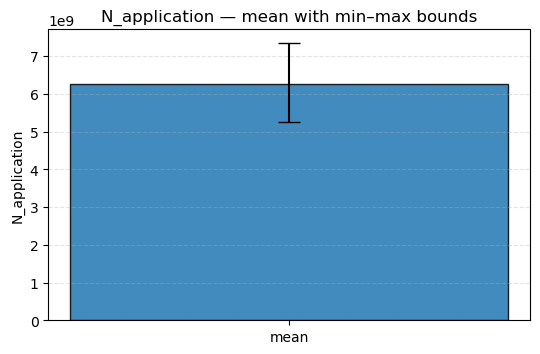

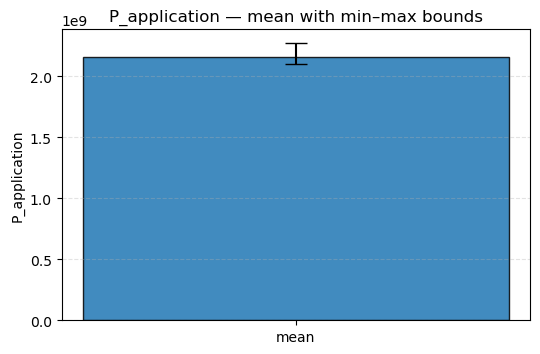

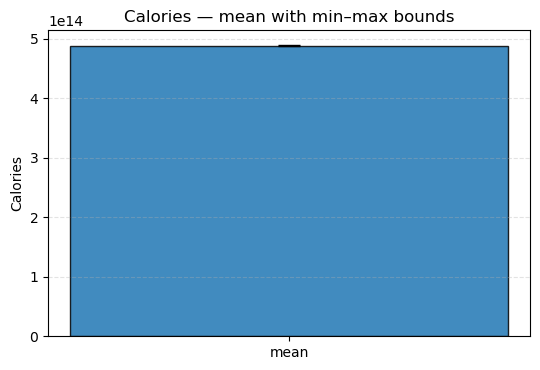

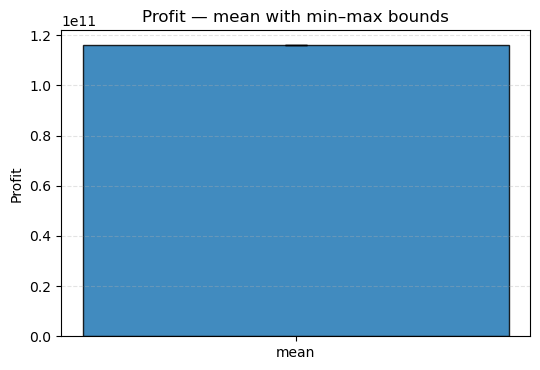

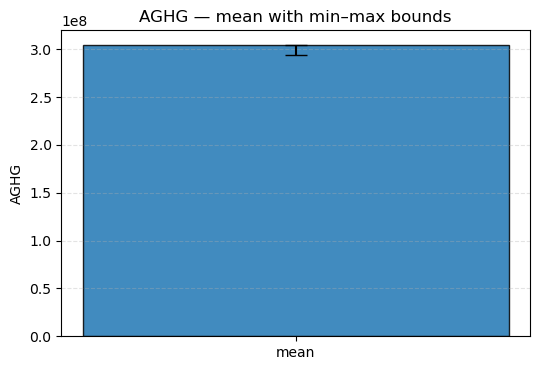

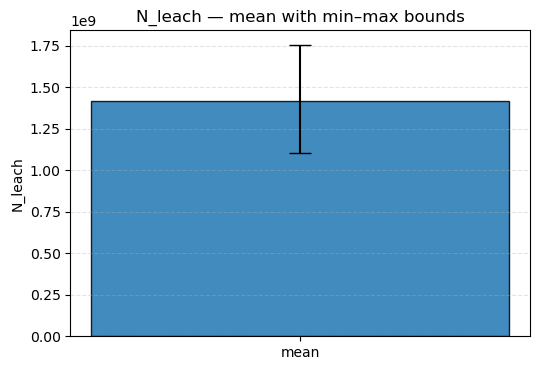

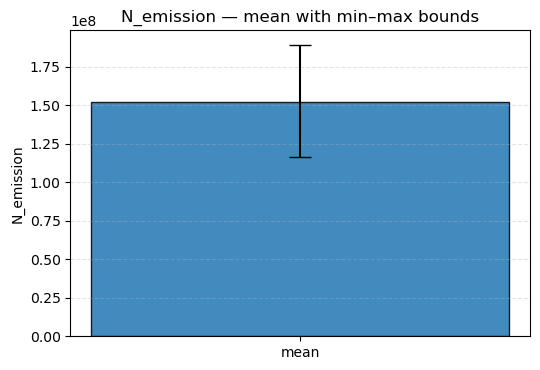

In [37]:
# ============================
# Step 1: Bootstrapping Setup
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

# --- Helpers to standardize geo keys and handle casing ---
def standardize_geo_cols(df):
    """
    Ensure df has 'state','district','crop' columns (lowercase) with trimmed/lowercased values.
    Accepts either State/District/Crop or state/district/crop.
    """
    df = df.copy()
    rename_map = {}
    if 'State' in df.columns:    rename_map['State'] = 'state'
    if 'District' in df.columns: rename_map['District'] = 'district'
    if 'Crop' in df.columns:     rename_map['Crop'] = 'crop'
    if rename_map:
        df.rename(columns=rename_map, inplace=True)

    required = ['state', 'district', 'crop']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns after standardization: {missing}")

    for c in required:
        df[c] = df[c].astype(str).str.strip().str.lower()
    return df

# Function to compute bootstrapped stats (within each s,d,c)
def bootstrap_nutrient_stats(df, value_col, n_iterations=1000):
    """
    Returns dict keyed by (state,district,crop) -> {'min','mean','max'}
    """
    df = standardize_geo_cols(df)
    stats_dict = {}
    grouped = df.groupby(['state','district','crop'], dropna=False)
    for (s, d, c), group in grouped:
        values = pd.to_numeric(group[value_col], errors='coerce').dropna().values
        if values.size > 0:
            # resample WITHIN the group's historical values
            samples = np.random.choice(values, size=(n_iterations, len(values)), replace=True)
            boot_means = samples.mean(axis=1)
            stats_dict[(s, d, c)] = {
                'min': float(np.min(boot_means)),
                'mean': float(np.mean(boot_means)),
                'max': float(np.max(boot_means)),
            }
    return stats_dict

# Function to fallback to state average if district-level bootstrapped stats are missing
def fill_with_bootstrap_or_state(df, stats_dict, state_means, default='mean'):
    """
    For each row, use bootstrapped (s,d,c) stat if available; otherwise fallback to state–crop mean.
    df must have 'state','district','crop' (lowercase).
    state_means must be keyed by (state,crop) both lowercase.
    """
    df = standardize_geo_cols(df)
    out = []
    for _, row in df.iterrows():
        key_triple = (row['state'], row['district'], row['crop'])
        key_state_crop = (row['state'], row['crop'])
        if key_triple in stats_dict:
            out.append(stats_dict[key_triple][default])
        else:
            out.append(state_means.get(key_state_crop, np.nan))
    return out

# ===================================
# Step 2: Run Bootstrapping on kharif
# ===================================

# Make sure both dataframes are standardized
kharif_std      = standardize_geo_cols(kharif)
kharif_2017_std = standardize_geo_cols(kharif_2017)

# Bootstrapping stats from your full history
n_applied_stats = bootstrap_nutrient_stats(kharif_std, 'N_applied(kg/ha)', n_iterations=1000)
manure_stats    = bootstrap_nutrient_stats(kharif_std, 'Manure (kg/ha)',   n_iterations=1000)

# Fallback: state–crop average values (keys: (state,crop) both lowercase)
state_crop_n_applied_mean = (
    kharif_std
    .assign(val=pd.to_numeric(kharif_std['N_applied(kg/ha)'], errors='coerce'))
    .groupby(['state','crop'])['val'].mean().to_dict()
)
state_crop_manure_mean = (
    kharif_std
    .assign(val=pd.to_numeric(kharif_std['Manure (kg/ha)'], errors='coerce'))
    .groupby(['state','crop'])['val'].mean().to_dict()
)

# =============================================
# Step 3: Loop over min, mean, max for analysis
# =============================================

uncertainty_results = []

for case in ['min', 'mean', 'max']:
    # Create a new working df copy (standardized)
    kh_df = kharif_2017_std.copy()

    # Replace N_applied and Manure with bootstrapped values / fallbacks
    kh_df['N_applied(kg/ha)'] = fill_with_bootstrap_or_state(
        kh_df, n_applied_stats, state_crop_n_applied_mean, default=case
    )
    kh_df['Manure (kg/ha)'] = fill_with_bootstrap_or_state(
        kh_df, manure_stats, state_crop_manure_mean, default=case
    )

    # Recalculate net N and manure N/P
    kh_df['Manure (N_kg/ha)'] = pd.to_numeric(kh_df['Manure (kg/ha)'], errors='coerce').fillna(0) * 0.005
    kh_df['Manure (P_kg/ha)'] = pd.to_numeric(kh_df['Manure (kg/ha)'], errors='coerce').fillna(0) * 0.002
    kh_df['net_N_applied(kg/ha)'] = (
        pd.to_numeric(kh_df['N_applied(kg/ha)'], errors='coerce').fillna(0)
        + kh_df['Manure (N_kg/ha)']
        + pd.to_numeric(kh_df['atm_depo'], errors='coerce').fillna(0)
        + pd.to_numeric(kh_df['BNF_kg_per_hec'], errors='coerce').fillna(0)
    )

    # >>> If your solver reads from a global, update it here; else pass kh_df into your runner.
    # Here I keep your call as-is and assume your function consumes the updated global kharif_2017.
    kharif_2017 = kh_df.copy()          # update the global your model expects
    results = run_model_with_modifier({})  # <-- your existing function
    # Expected to return dict with keys like 'N_surplus','P_surplus','Water','Profit','AGHG'
    results['scenario'] = case
    uncertainty_results.append(results)

# ==================================
# Step 4: Convert and Plot Results
# ==================================
unc_df = pd.DataFrame(uncertainty_results).set_index('scenario')

# Add Calories to the metrics list
metrics = ['Water','N_surplus','P_surplus',
    'N_application','P_application',
    'Calories','Profit',
    'AGHG','N_leach','N_emission']

for m in metrics:
    if m not in unc_df.columns:
        print(f"Warning: metric '{m}' not found in results; skipping.")
        continue

    mean_val  = unc_df.loc['mean', m]
    err_lower = max(0, mean_val - unc_df.loc['min',  m])
    err_upper = max(0, unc_df.loc['max',  m] - mean_val)

    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    ax.bar(['mean'], [mean_val],
           yerr=[[err_lower], [err_upper]],
           capsize=8, edgecolor='black', ecolor='black', alpha=0.85)
    ax.set_title(f"{m} — mean with min–max bounds")
    ax.set_ylabel(m)  # 'Calories' will show here as the label too
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()


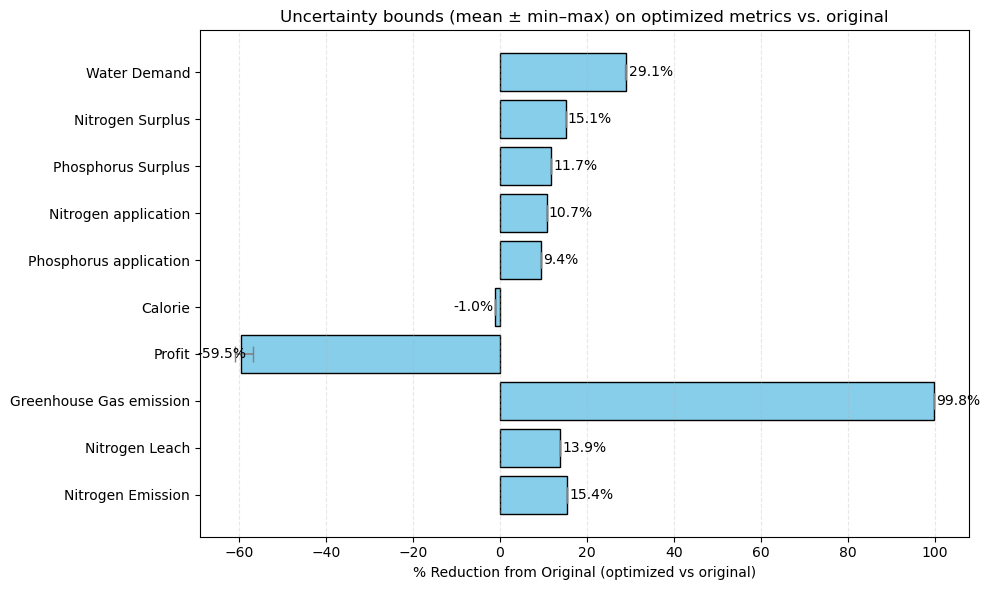

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Your desired metrics & labels
desired_metrics = [
    'Water','N_surplus','P_surplus',
    'N_application','P_application',
    'Calories','Profit',
    'AGHG','N_leach','N_emission'
]
metric_labels = [
    'Water Demand','Nitrogen Surplus','Phosphorus Surplus',
    'Nitrogen application','Phosphorus application',
    'Calorie','Profit',
    'Greenhouse Gas emission','Nitrogen Leach','Nitrogen Emission'
]
label_map = dict(zip(desired_metrics, metric_labels))

# 1) Candidate baseline (original) column names for each metric
baseline_candidates = {
    'Water': [
        'Original water', 'Original Water', 'Original Total Water',
        'Original_Total_Water'
    ],
    'N_surplus': [
        'Original Total N surplus','Original N surplus',
        'Original nitrogen surplus','Original_Total_N_surplus'
    ],
    'P_surplus': [
        'Original Total P surplus','Original P surplus',
        'Original phosphorus surplus','Original_Total_P_surplus'
    ],
    'N_application': [
        'Original Total N Applied','Original Total Nitrogen Applied',
        'Original N applied','Original nitrogen applied',
        'Original_Total_N_Applied'
    ],
    'P_application': [
        'Original Total P Applied','Original Total Phosphorus Applied',
        'Original P applied','Original phosphorus applied',
        'Original_Total_P_Applied'
    ],
    'Calories': [
        'Original Calorie','Original Calories','Original Total Calorie',
        'Original Total Calories','Original_Total_Calories'
    ],
    'Profit': [
        'Original profit','Original Total profit',
        'Original_Total_Profit'
    ],
    'AGHG': [
        'Original AGHG','Original Total AGHG',
        'Original GHG','Original_Total_AGHG'
    ],
    'N_leach': [
        'Original N_leach','Original Total N_leach',
        'Original nitrate leach','Original_Total_N_leach'
    ],
    'N_emission': [
        'Original N_emission','Original Total N_emission',
        'Original nitrous emission','Original_Total_N_emission'
    ],
}

def find_first_present_column(candidates, df):
    """Return the first column name from candidates that exists in df, else None."""
    for col in candidates:
        if col in df.columns:
            return col
    return None

# 2) Build arrays for plotting (skip metrics with missing baseline or missing in unc_df)
labels_final = []
vals_mean = []
errs_low = []
errs_up = []

for m in desired_metrics:
    # Check we have bootstrap stats for this metric
    if m not in unc_df.columns:
        print(f"⚠️  Skipping '{m}': not found in unc_df.")
        continue

    # Find baseline column in results_df
    original_col = find_first_present_column(baseline_candidates.get(m, []), results_df)
    if original_col is None:
        print(f"⚠️  Skipping '{m}': could not find an original baseline column in results_df.")
        continue

    # Sum baseline across all rows (national total)
    baseline = float(results_df[original_col].sum())

    # If baseline is missing or zero, we cannot compute % change
    if not np.isfinite(baseline) or baseline == 0:
        print(f"⚠️  Skipping '{m}': baseline is NaN/0.")
        continue

    # Pull mean / min / max optimized totals from bootstrap summary
    try:
        mean_val = float(unc_df.loc['mean', m])
        min_val  = float(unc_df.loc['min',  m])
        max_val  = float(unc_df.loc['max',  m])
    except KeyError:
        print(f"⚠️  Skipping '{m}': missing min/mean/max rows in unc_df.")
        continue

    # % reduction (optimized vs original): positive means reduction
    pct_change = 100.0 * (baseline - mean_val) / baseline
    pct_min    = 100.0 * (baseline - min_val)  / baseline
    pct_max    = 100.0 * (baseline - max_val)  / baseline

    # Non-negative asymmetric error extents around mean
    err_lower = max(0.0, pct_change - pct_min)
    err_upper = max(0.0, pct_max - pct_change)

    labels_final.append(label_map.get(m, m))
    vals_mean.append(pct_change)
    errs_low.append(err_lower)
    errs_up.append(err_upper)

# 3) Plot (horizontal bars with asymmetric error bars)
if len(labels_final) == 0:
    print("No metrics available to plot. Check baselines and unc_df columns.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = np.arange(len(labels_final))
    xerr = np.vstack([errs_low, errs_up])

    bars = ax.barh(
        y_pos, vals_mean,
        xerr=xerr,
        color='skyblue', edgecolor='black',
        error_kw=dict(ecolor='gray', elinewidth=1.2, capsize=6)
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_final)
    ax.invert_yaxis()  # highest at top
    ax.set_xlabel('% Reduction from Original (optimized vs original)')
    ax.set_title('Uncertainty bounds (mean ± min–max) on optimized metrics vs. original')

    # Annotate bar tips with mean % change
    for i, v in enumerate(vals_mean):
        # place text just beyond the bar tip (respect sign)
        offset = errs_up[i] if v >= 0 else -errs_low[i]
        ax.text(v + (offset + 0.5 if v >= 0 else -offset - 0.5),
                i, f"{v:.1f}%",
                va='center',
                ha='left' if v >= 0 else 'right')

    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


          component scenario  N_surplus  P_surplus     Water     Profit  \
0  N_applied(kg/ha)     -10%  -9.661491  -0.003086  0.342089   2.645308   
1  N_applied(kg/ha)     +10%   9.528798  -0.908033 -0.928121  22.873515   
2  Manure (N_kg/ha)     -10%  -0.477677  -0.701466 -0.671906  21.654198   
3  Manure (N_kg/ha)     +10%   0.522990   0.390894 -0.189839  -8.540029   
4          atm_depo     -10%  -0.176586  -0.047818 -0.638303  -2.101462   
5          atm_depo     +10%   0.176760   0.000000  0.000000   0.000000   
6    BNF_kg_per_hec     -10%  -3.789593  -0.072665 -0.150299   2.222676   
7    BNF_kg_per_hec     +10%   3.766345  -0.261883  0.724389   8.306572   

       AGHG  
0  0.328660  
1 -0.211790  
2 -0.278746  
3  0.934780  
4  0.398715  
5  0.000000  
6  1.100142  
7 -0.704924  


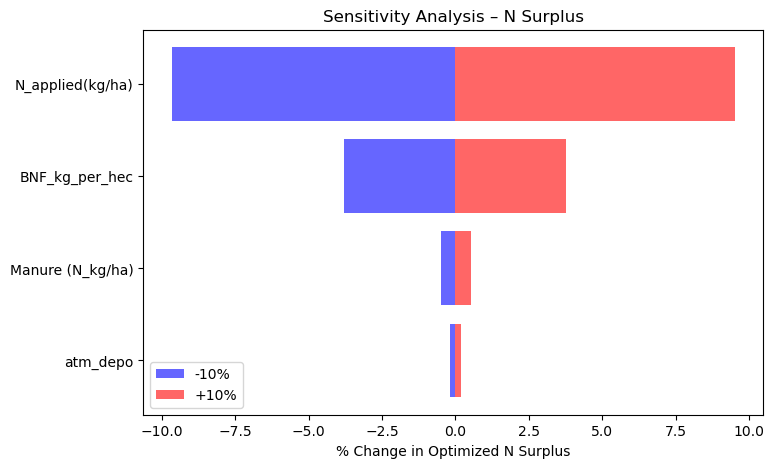

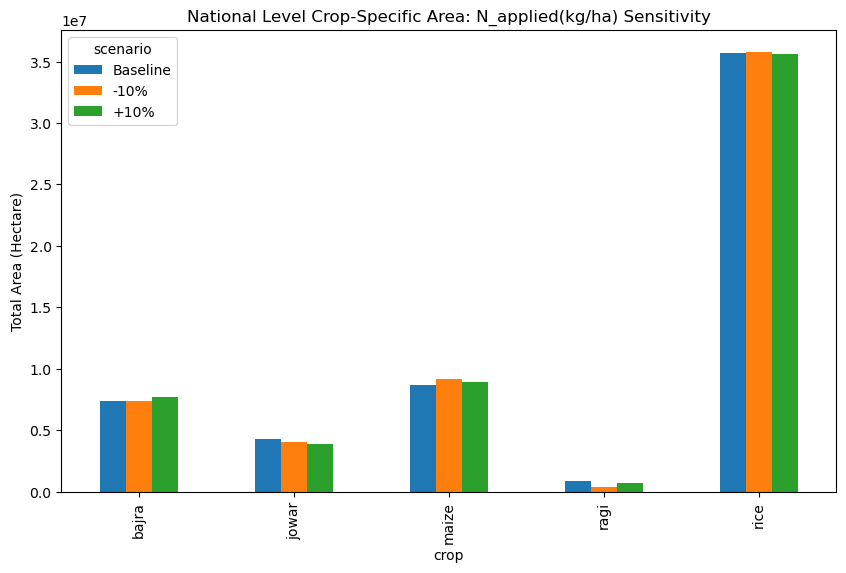

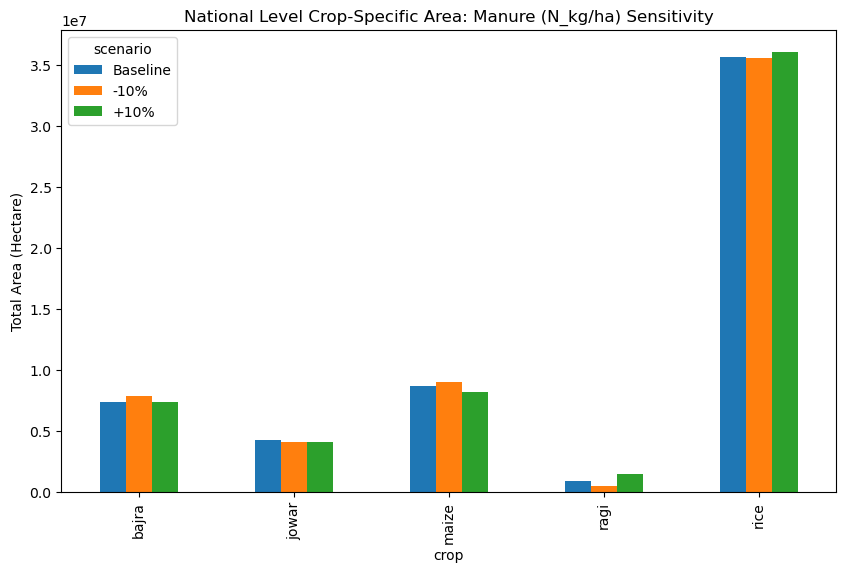

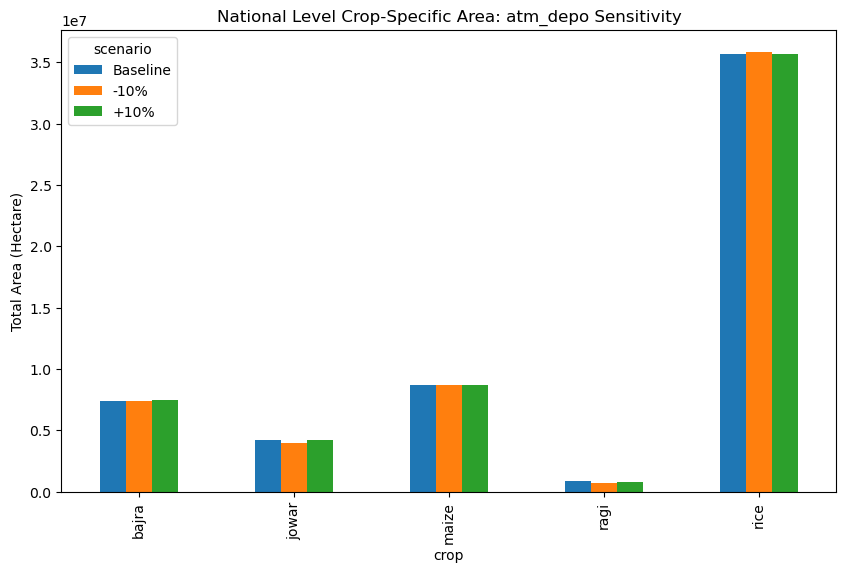

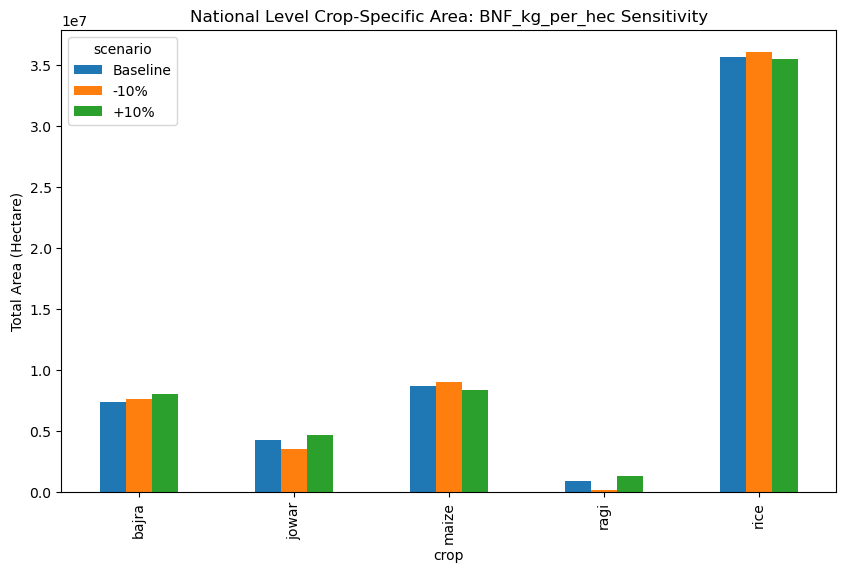

In [73]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Main Optimization Function
# ===============================
def run_model_with_modifier(modifier):
    # ---- Copy data ----
    df = kharif_2017.copy()

    # ---- Apply component multipliers ----
    for comp, factor in modifier.items():
        df[comp] = df[comp] * factor

    # ---- Recompute net N and P applied ----
    df['net_N_applied(kg/ha)'] = (
        df['N_applied(kg/ha)'] +
        df['Manure (N_kg/ha)'] +
        df['atm_depo'] +
        df['BNF_kg_per_hec']
    )
    df['net_P_applied(kg/ha)'] = (
        df['P_applied(kg/ha)'] +
        df['Manure (P_kg/ha)']
    )

    # ===============================
    # START OF YOUR ORIGINAL CODE
    # ===============================

    # Rename columns
    df.rename(columns={'district': 'District'}, inplace=True)
    df.rename(columns={'state': 'State'}, inplace=True)
    df.rename(columns={'crop': 'Crop'}, inplace=True)

    kharif_max.rename(columns={'district': 'District'}, inplace=True)
    kharif_max.rename(columns={'state': 'State'}, inplace=True)
    kharif_max.rename(columns={'crop': 'Crop'}, inplace=True)
    kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()

    # Filter crops
    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['Crop'].isin(selected_crops)]
    kharif_max_f = kharif_max[kharif_max['Crop'].isin(selected_crops)]

    # Max area constraints dict
    max_area_constraints = kharif_max_f.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

    # Standardize case/spacing
    df['District'] = df['District'].str.lower().str.strip()
    df['State'] = df['State'].str.lower().str.strip()
    df['Crop'] = df['Crop'].str.lower().str.strip()

    # Fill NaNs for net N applied
    avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
    global_avg = kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
    df['net_N_applied(kg/ha)'] = df['net_N_applied(kg/ha)'].fillna(avg_N_applied)
    if df['net_N_applied(kg/ha)'].isnull().any():
        df['net_N_applied(kg/ha)'] = df['net_N_applied(kg/ha)'].fillna(global_avg)

    # Fill NaNs for net P applied
    avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
    global_avg_P = kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
    df['net_P_applied(kg/ha)'] = df['net_P_applied(kg/ha)'].fillna(avg_P_applied)
    if df['net_P_applied(kg/ha)'].isnull().any():
        df['net_P_applied(kg/ha)'] = df['net_P_applied(kg/ha)'].fillna(global_avg_P)

    # Fill cost of cultivation
    avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'] = df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult)
    if df['Cost_of_Production_rs_Quintal'].isnull().any():
        global_avg_cost_cult = kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')
        df['Cost_of_Production_rs_Quintal'] = df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult)

    # Replace -1s with 0
    df['Area (Hectare)'] = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)'] = 1000*df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # Fill CWR
    avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
    global_avg_cwr = kharif.groupby(['crop'])['CWR m3/ha'].transform('mean')
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(avg_applied_CWR)
    if df['CWR m3/ha'].isnull().any():
        df['CWR m3/ha'] = df['CWR m3/ha'].fillna(global_avg_cwr)
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

    # Yield dictionary
    yield_data = df.set_index(['State','District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

    # Calorie mapping
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}
    crop_co2e = {'bajra': 0.098603856,'ragi': 0.098603856,'rice': 8.213913103,'jowar': 0.154967254,'wheat': 0.729809876,'maize': 0.889859651}
    AGHG_per_ha_dict = {cereal: value for cereal, value in crop_co2e.items()}

    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)
    df['AGHG_produced (per ha)'] = df['Crop'].map(AGHG_per_ha_dict)
    df['Total Calorie Supply'] = 1000*df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost'] = 10*df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply'] = 10*df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit'] = df['Total MSP Supply'] - df['Total Farmer Cost']

    # Dictionaries for optimization
    districts = df['District'].unique().tolist()
    states = df['State'].unique().tolist()
    cereals = df['Crop'].unique().tolist()
    current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
    nitrogen_rate = df.set_index(['State','District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
    nitrogen_removal_rate_perkg = df.set_index(['State','District', 'Crop'])['n_removed_rate'].to_dict()
    P_rate = df.set_index(['State','District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_removal_rate_perkg = df.set_index(['State','District', 'Crop'])['p_removed_rate'].to_dict()
    water_rate = df.set_index(['State','District', 'Crop'])['CWR m3/ha'].to_dict()
    calories_per_prod = df.set_index(['State','District', 'Crop'])['Calorie Supply (per KG)'].to_dict()
    AGHG_per_ha = df.set_index(['State','District', 'Crop'])['AGHG_produced (per ha)'].to_dict()
    district_to_state = df.set_index('District')['State'].to_dict()
    cost_per_area = df.set_index(['State','District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod = df.set_index(['State','District', 'Crop'])['MSP_RsperQntl'].to_dict()

    # Optimization model
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states,districts,cereals), 0, None, pulp.LpContinuous)

    # Objective: Minimize N surplus
    prob += pulp.lpSum([x[s][d][c]*(nitrogen_rate.get((s,d,c),0) -
                                    (yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)))
                        for s in states for d in districts for c in cereals])

    # Constraints
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d),0)

    for s in states:
        for d in districts:
            for c in cereals:
                if (s,d,c) in max_area_constraints:
                    prob += x[s][d][c] <= max_area_constraints[(s,d,c)]

    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area.get((s,d,c),0) == 0:
                    prob += x[s][d][c] == 0

    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum(
            [x[s][d][c] * yield_data.get((s,d,c),0) * calories_per_prod.get((s,d,c),0)
             for d in districts for c in cereals]
        ) >= initial_state_calories[s]

    initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*MSP_per_prod.get((s,d,c),0)) -
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*cost_per_area.get((s,d,c),0))
            for d in districts if district_to_state.get(d) == s for c in cereals
        ]) >= initial_state_profit[s]

    solver = pulp.PULP_CBC_CMD()
    prob.solve(solver)

    # Outputs
    optimized_total_nitrogen_surplus = sum(
        (pulp.value(x[s][d][c]))*(nitrogen_rate.get((s,d,c),0) -
                                  (yield_data.get((s,d,c),0)*nitrogen_removal_rate_perkg.get((s,d,c),0)))
        for s in states for d in districts for c in cereals
    )
    optimized_total_P_surplus = sum(
        (pulp.value(x[s][d][c]))*(P_rate.get((s,d,c),0) -
                                  (yield_data.get((s,d,c),0)*P_removal_rate_perkg.get((s,d,c),0)))
        for s in states for d in districts for c in cereals
    )
    optimal_water = sum((pulp.value(x[s][d][c]))* water_rate.get((s,d,c),0)
                        for s in states for d in districts for c in cereals)
    optimal_profit = sum(
        ((0.01*pulp.value(x[s][d][c]))*yield_data.get((s,d,c),0)*MSP_per_prod.get((s,d,c),0)) -
        ((0.01*pulp.value(x[s][d][c]))*yield_data.get((s,d,c),0)*cost_per_area.get((s,d,c),0))
        for s in states for d in districts for c in cereals
    )
    optimal_AGHG = sum((pulp.value(x[s][d][c]))*AGHG_per_ha.get((s,d,c),0)
                       for s in states for d in districts for c in cereals)

    # Crop-level total optimized area
    crop_area_totals = {c: sum(pulp.value(x[s][d][c]) for s in states for d in districts) for c in cereals}

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "P_surplus": optimized_total_P_surplus,
        "Water": optimal_water,
        "Profit": optimal_profit,
        "AGHG": optimal_AGHG,
        "CropAreas": crop_area_totals
    }

# ===============================
# Sensitivity Analysis Loop
# ===============================
components = ["N_applied(kg/ha)", "Manure (N_kg/ha)", "atm_depo", "BNF_kg_per_hec"]

baseline = run_model_with_modifier({})
baseline_crop_areas = baseline.pop("CropAreas")

sens_results = []
crop_area_sens = []

for comp in components:
    for change in [-0.1, 0.1]:
        factor = 1 + change
        res = run_model_with_modifier({comp: factor})
        crop_areas = res.pop("CropAreas")

        change_pct = {m: 100*(res[m]-baseline[m])/baseline[m] for m in baseline}
        sens_results.append({"component": comp, "scenario": f"{int(change*100):+d}%", **change_pct})

        for crop, area in crop_areas.items():
            crop_area_sens.append({
                "component": comp,
                "scenario": f"{int(change*100):+d}%",
                "crop": crop,
                "area": area
            })

sens_df = pd.DataFrame(sens_results)
print(sens_df)

# ===============================
# Tornado Chart for N Surplus
# ===============================
metric = "N_surplus"
df_plot = sens_df.pivot(index="component", columns="scenario", values=metric)
df_plot["max_abs_change"] = df_plot.abs().max(axis=1)
df_plot = df_plot.sort_values("max_abs_change", ascending=True)

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(df_plot.index, df_plot["-10%"], color="blue", alpha=0.6, label="-10%")
ax.barh(df_plot.index, df_plot["+10%"], color="red", alpha=0.6, label="+10%")
ax.set_xlabel("% Change in Optimized N Surplus")
ax.set_title("Sensitivity Analysis – N Surplus")
ax.legend()
plt.show()

# ===============================
# Crop Area Change Charts
# ===============================
df_crop_area = pd.DataFrame(crop_area_sens)
for comp in components:
    df_plot = df_crop_area[df_crop_area["component"] == comp]

    # Add baseline
    baseline_df = pd.DataFrame([
        {"component": comp, "scenario": "Baseline", "crop": c, "area": a}
        for c,a in baseline_crop_areas.items()
    ])
    df_plot = pd.concat([df_plot, baseline_df], ignore_index=True)

    plot_df = df_plot.pivot(index="crop", columns="scenario", values="area")
    plot_df = plot_df[["Baseline", "-10%", "+10%"]]

    plot_df.plot(kind="bar", figsize=(10,6))
    plt.ylabel("Total Area (Hectare)")
    plt.title(f"National Level Crop-Specific Area: {comp} Sensitivity")
    plt.show()


In [75]:
#bootstrapping


In [83]:
def run_bootstrapped_uncertainty_analysis(kharif, kharif_2017_raw, n_bootstrap=100):
    import numpy as np
    import pandas as pd

    # STEP 1: Standardize column names
    kharif = kharif.copy()
    kharif['crop'] = kharif['crop'].str.lower().str.strip()

    kharif_2017 = kharif_2017_raw.copy()
    for col in ['state', 'district', 'crop']:
        if col not in kharif_2017.columns and col.capitalize() in kharif_2017.columns:
            kharif_2017.rename(columns={col.capitalize(): col}, inplace=True)
    kharif_2017['crop'] = kharif_2017['crop'].str.lower().str.strip()

    # STEP 2: Filter years for bootstrapping
    kharif_long = kharif[kharif['Year'].between(2009, 2020)]

    # STEP 3: Bootstrapping function
    def bootstrap_stats(group):
        out = {}
        for col in ['N_applied(kg/ha)', 'Manure (kg/ha)']:
            data = group[col].dropna()
            if len(data) == 0:
                out[col + '_min'] = np.nan
                out[col + '_mean'] = np.nan
                out[col + '_max'] = np.nan
                continue
            samples = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
            out[col + '_min'] = np.min(samples)
            out[col + '_mean'] = np.mean(samples)
            out[col + '_max'] = np.max(samples)
        return pd.Series(out)

    # STEP 4: Apply bootstrapping
    bootstrapped_df = kharif_long.groupby(['state', 'district', 'crop'], group_keys=False)\
        .apply(bootstrap_stats).reset_index()

    # STEP 5: Merge into 2017 base data
    kharif_merged = pd.merge(kharif_2017, bootstrapped_df, on=['state', 'district', 'crop'], how='left')

    # STEP 6: Define scenarios
    scenarios = {
        'min': {
            'N_applied(kg/ha)': 'N_applied(kg/ha)_min',
            'Manure (kg/ha)': 'Manure (kg/ha)_min'
        },
        'mean': {
            'N_applied(kg/ha)': 'N_applied(kg/ha)_mean',
            'Manure (kg/ha)': 'Manure (kg/ha)_mean'
        },
        'max': {
            'N_applied(kg/ha)': 'N_applied(kg/ha)_max',
            'Manure (kg/ha)': 'Manure (kg/ha)_max'
        }
    }

    # STEP 7: Run optimization for each scenario
    records = []
    for label, mapping in scenarios.items():
        kharif_variant = kharif_merged.copy()
        for col, source in mapping.items():
            kharif_variant[col] = kharif_variant[source]
        globals()['kharif_2017'] = kharif_variant  # update global variable
        result = run_model_with_modifier({})
        result['scenario'] = label
        records.append(result)

    # STEP 8: Compile results and compute summary
    df_summary = pd.DataFrame(records)
    metrics = ['N_surplus', 'P_surplus', 'Water', 'Profit', 'AGHG']
    summary_stats = df_summary[metrics].agg(['min', 'mean', 'max']).T
    summary_stats.columns = ['min', 'mean', 'max']
    summary_stats['range(%)'] = 100 * (summary_stats['max'] - summary_stats['min']) / summary_stats['mean']

    return df_summary, summary_stats


In [84]:
uncertainty_runs, uncertainty_summary = run_bootstrapped_uncertainty_analysis(kharif, kharif_2017)
print(uncertainty_runs)      # Raw outcomes for min, mean, max
print(uncertainty_summary)   # Summary table with range in %


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_57492\1684545232.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bootstrapped_df = kharif_long.groupby(['state', 'district', 'crop'], group_keys=False)\


KeyError: 'N_applied(kg/ha)_min'

In [85]:
print("Bootstrapped columns:", bootstrapped_df.columns.tolist())
print("Sample bootstrapped data:")
print(bootstrapped_df.head())


NameError: name 'bootstrapped_df' is not defined

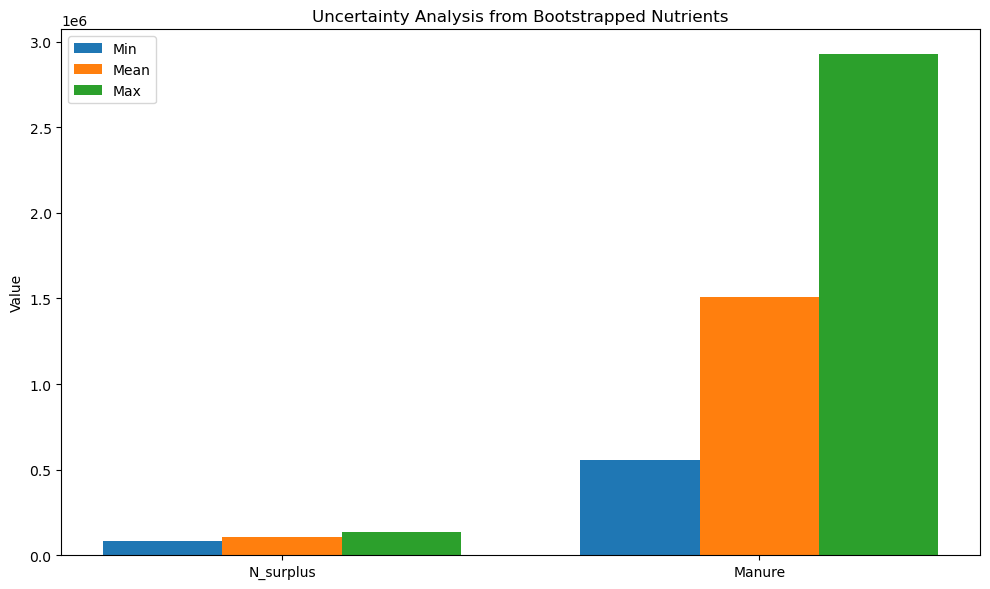

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# Step 1: Define Bootstrapping Function
# ----------------------------------------
def bootstrap_nutrient_stats(df, value_col, n_iterations=1000):
    stats_dict = {}
    grouped = df.groupby(['state', 'district', 'crop'])

    for (s, d, c), group in grouped:
        values = group[value_col].dropna().values
        if len(values) > 0:
            samples = np.random.choice(values, size=(n_iterations, len(values)), replace=True)
            boot_means = samples.mean(axis=1)
            stats_dict[(s.lower(), d.lower(), c.lower())] = {
                'min': boot_means.min(),
                'mean': boot_means.mean(),
                'max': boot_means.max()
            }
    return stats_dict

# ----------------------------------------
# Step 2: Fill Function for kharif_2017
# ----------------------------------------
def fill_with_bootstrap_or_state(df, stats_dict, state_means, default='mean'):
    filled_vals = []
    for _, row in df.iterrows():
        key = (row['state'].lower(), row['district'].lower(), row['crop'].lower())
        fallback_key = (row['state'], row['crop'])
        if key in stats_dict:
            filled_vals.append(stats_dict[key][default])
        else:
            filled_vals.append(state_means.get(fallback_key, np.nan))
    return filled_vals

# ----------------------------------------
# Step 3: Optimization Placeholder
# Replace this with your real optimization function
# ----------------------------------------
def run_optimization(df):
    # Placeholder output values for demonstration
    return {
        "N_surplus": df["N_applied(kg/ha)"].sum(),
        "Manure": df["Manure (kg/ha)"].sum(),
    }

# ----------------------------------------
# Step 4: Prepare Dataset and Run Bootstrapping
# ----------------------------------------

# Bootstrapping
n_applied_stats = bootstrap_nutrient_stats(kharif, 'N_applied(kg/ha)')
manure_stats = bootstrap_nutrient_stats(kharif, 'Manure (kg/ha)')
state_crop_n_applied_mean = kharif.groupby(['state', 'crop'])['N_applied(kg/ha)'].mean().to_dict()
state_crop_manure_mean = kharif.groupby(['state', 'crop'])['Manure (kg/ha)'].mean().to_dict()

# ----------------------------------------
# Step 5: Run for mean, min, max
# ----------------------------------------
results = {}
for case in ['min', 'mean', 'max']:
    kharif_2017_copy = kharif_2017.copy()
    kharif_2017_copy['N_applied(kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_copy, n_applied_stats, state_crop_n_applied_mean, default=case
    )
    kharif_2017_copy['Manure (kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_copy, manure_stats, state_crop_manure_mean, default=case
    )
    results[case] = run_optimization(kharif_2017_copy)

# ----------------------------------------
# Step 6: Plot Results
# ----------------------------------------
metrics = list(results['mean'].keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, [results['min'][m] for m in metrics], width, label='Min')
ax.bar(x, [results['mean'][m] for m in metrics], width, label='Mean')
ax.bar(x + width, [results['max'][m] for m in metrics], width, label='Max')

ax.set_ylabel("Value")
ax.set_title("Uncertainty Analysis from Bootstrapped Nutrients")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.show()



In [97]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

# 1. Load kharif data and preprocess
kharif['state'] = kharif['state'].str.lower().str.strip()
kharif['district'] = kharif['district'].str.lower().str.strip()
kharif['crop'] = kharif['crop'].str.lower().str.strip()

# 2. Bootstrapping function
def bootstrap_nutrient_stats(df, value_col, n_iterations=1000):
    stats_dict = {}
    grouped = df.groupby(['state', 'district', 'crop'])
    for (s, d, c), group in grouped:
        values = group[value_col].dropna().values
        if len(values) > 0:
            samples = np.random.choice(values, size=(n_iterations, len(values)), replace=True)
            boot_means = samples.mean(axis=1)
            stats_dict[(s, d, c)] = {
                'min': boot_means.min(),
                'mean': boot_means.mean(),
                'max': boot_means.max()
            }
    return stats_dict

# 3. Apply bootstrapping
boot_n = bootstrap_nutrient_stats(kharif, 'N_applied(kg/ha)')
boot_m = bootstrap_nutrient_stats(kharif, 'Manure (kg/ha)')

state_avg_n = kharif.groupby(['state', 'crop'])['N_applied(kg/ha)'].mean().to_dict()
state_avg_m = kharif.groupby(['state', 'crop'])['Manure (kg/ha)'].mean().to_dict()

# 4. Fill kharif_2017 with bootstrapped values
kharif_2017 = kharif[kharif['Year'] == 2017].copy()

def fill_with_bootstrap_or_state(df, stats_dict, state_means, col_to_fill, default='mean'):
    filled_vals = []
    for _, row in df.iterrows():
        key = (row['state'], row['district'], row['crop'])
        fallback_key = (row['state'], row['crop'])
        boot_stat = stats_dict.get(key, {}).get(default)
        filled_vals.append(boot_stat if boot_stat is not None else state_means.get(fallback_key, np.nan))
    df[col_to_fill] = filled_vals
    return df

kharif_2017 = fill_with_bootstrap_or_state(kharif_2017, boot_n, state_avg_n, 'N_applied(kg/ha)')
kharif_2017 = fill_with_bootstrap_or_state(kharif_2017, boot_m, state_avg_m, 'Manure (kg/ha)')

# 5. Prepare variables for optimization
yield_data = kharif_2017.set_index(['state','district','crop'])['Yield (Tonnes/Hectare)'].to_dict()
n_rate = kharif_2017.set_index(['state','district','crop'])['N_applied(kg/ha)'].to_dict()
n_removal = kharif_2017.set_index(['state','district','crop'])['n_removed_rate'].to_dict()
area_data = kharif_2017.groupby(['state','district'])['Area (Hectare)'].sum().to_dict()

states = kharif_2017['state'].unique()
districts = kharif_2017['district'].unique()
crops = kharif_2017['crop'].unique()

max_area_constraints = kharif_2017.set_index(['state', 'district', 'crop'])['Area (Hectare)'].to_dict()
historical_cereal_area = kharif.groupby(['state','district','crop'])['Area (Hectare)'].sum().to_dict()
df = kharif_2017.copy()
calories_per_prod = df.set_index(['state','district','crop'])['Calorie Supply (per KG)'].to_dict()
MSP_per_prod = df.set_index(['state','district','crop'])['MSP_RsperQntl'].to_dict()
cost_per_area = df.set_index(['state','district','crop'])['Cost_of_Production_rs_Quintal'].to_dict()
district_to_state = df.set_index('district')['state'].to_dict()

# 6. Define optimization function
def run_surplus_optimization(states, districts, crops, yield_data, n_rate, n_removal, area_data):
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, crops), 0, None, pulp.LpContinuous)

    prob += pulp.lpSum([
        x[s][d][c] * (n_rate.get((s,d,c),0) - yield_data.get((s,d,c),0) * n_removal.get((s,d,c),0))
        for s in states for d in districts for c in crops
    ])

    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in crops]) == area_data.get((s,d),0)

    for s, d, c in max_area_constraints:
        prob += x[s][d][c] <= max_area_constraints[(s,d,c)]

    for s, d, c in historical_cereal_area:
        if historical_cereal_area.get((s,d,c), 0) == 0:
            prob += x[s][d][c] == 0

    initial_state_calories = df.groupby('state')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            x[s][d][c] * yield_data.get((s,d,c),0) * calories_per_prod.get((s,d,c),0)
            for d in districts for c in crops
        ]) >= initial_state_calories.get(s, 0)

    initial_state_profit = df.groupby('state')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*MSP_per_prod.get((s,d,c),0)) -
            (x[s][d][c]*yield_data.get((s,d,c),0)*0.01*cost_per_area.get((s,d,c),0))
            for d in districts if district_to_state.get(d) == s for c in crops
        ]) >= initial_state_profit.get(s, 0)

    solver = pulp.PULP_CBC_CMD()
    prob.solve(solver)
    return x

# 7. Run optimization
x = run_surplus_optimization(states, districts, crops, yield_data, n_rate, n_removal, area_data)

# 8. Extract results
results = []
for s in states:
    for d in districts:
        for c in crops:
            optimized_area = x[s][d][c].varValue
            original_area = kharif_2017[(kharif_2017['state'] == s) & (kharif_2017['district'] == d) & (kharif_2017['crop'] == c)]['Area (Hectare)'].sum()
            results.append({
                'state': s,
                'district': d,
                'crop': c,
                'original_area': original_area,
                'optimized_area': optimized_area,
                'N_applied_min': boot_n.get((s,d,c), {}).get('min', np.nan),
                'N_applied_mean': boot_n.get((s,d,c), {}).get('mean', np.nan),
                'N_applied_max': boot_n.get((s,d,c), {}).get('max', np.nan)
            })

results_df = pd.DataFrame(results)

# 9. Plot uncertainty bars
sample = results_df.sample(20, random_state=42)
plt.figure(figsize=(10,6))
plt.errorbar(x=range(len(sample)),
             y=sample['optimized_area'],
             yerr=[sample['optimized_area'] - sample['N_applied_min'],
                   sample['N_applied_max'] - sample['optimized_area']],
             fmt='o', capsize=4, label='Optimized Area')
plt.scatter(range(len(sample)), sample['original_area'], color='r', label='Original Area')
plt.xticks(range(len(sample)), sample['district'] + '-' + sample['crop'], rotation=90)
plt.ylabel('Area (ha)')
plt.title('Original vs Optimized Area with N Application Uncertainty')
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'Calorie Supply (per KG)'

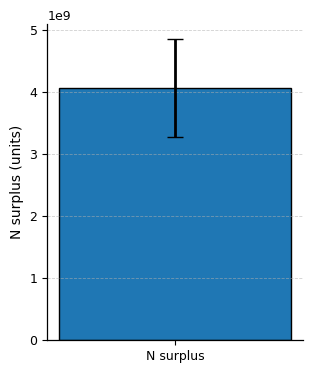

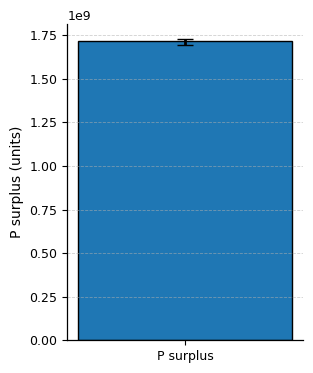

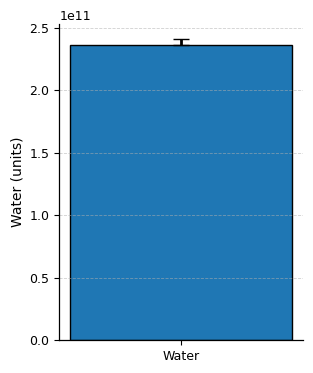

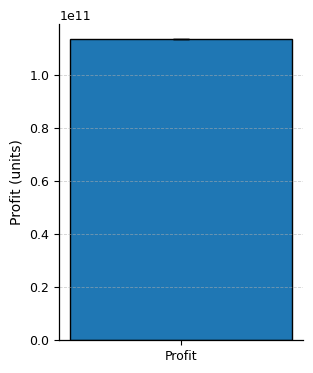

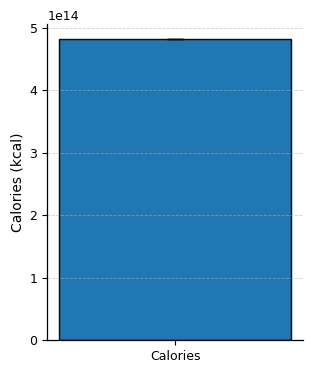

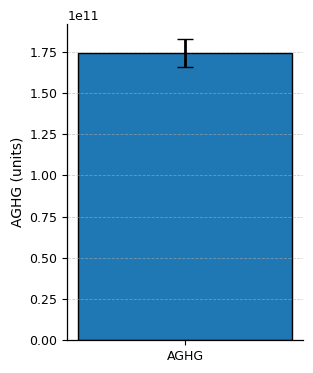

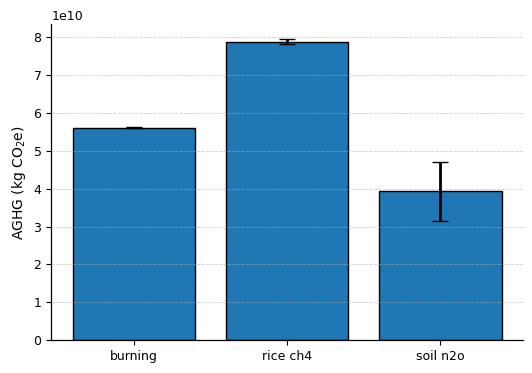

In [162]:
# -*- coding: utf-8 -*-
# Full updated code: Bootstrapping uncertainty + AGHG breakdown + N-surplus optimization

import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

# =========================================================
# 0) Utilities: enforce canonical key columns (lowercase)
# =========================================================
def ensure_lowercase_keys(df):
    """Return a copy with ['State','District','Crop'] renamed to lowercase if present."""
    mapping = {'State': 'state', 'District': 'district', 'Crop': 'crop'}
    cols_to_rename = {k: v for k, v in mapping.items() if k in df.columns}
    if cols_to_rename:
        df = df.rename(columns=cols_to_rename)
    return df

# Ensure source frames have lowercase keys for groupbys/joins/lookups
kharif      = ensure_lowercase_keys(kharif)
kharif_2017 = ensure_lowercase_keys(kharif_2017)
kharif_max  = ensure_lowercase_keys(kharif_max)

# =========================================================
# 1) AGHG factors and constants
# =========================================================
AGHG_FACTORS_PATH = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data/aghg_factor.csv"


aghg_df = pd.read_csv(AGHG_FACTORS_PATH)
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Residue burning per-kg factors (kg CO2e / kg product)
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))

# Rice CH4 per ha (kg CO2e / ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# N2O constants
N2O_GWP = 273                 # AR6 (100-yr)
USE_N2O_N = False             # Flip True if fn2o is N2O-N fraction
MOLAR_RATIO_N2O = 44/28       # N2O-N -> N2O

# =========================================================
# 2) Bootstrapping helpers
# =========================================================
def bootstrap_nutrient_stats(df, value_col, n_iterations=1000):
    """
    Build {(state,district,crop): {'min','mean','max'}} from 2009–2020 data
    for the specified value_col, using bootstrap of means.
    """
    stats_dict = {}
    grouped = df.groupby(['state', 'district', 'crop'])
    for (s, d, c), group in grouped:
        values = group[value_col].dropna().values
        if len(values) > 0:
            samples = np.random.choice(values, size=(n_iterations, len(values)), replace=True)
            boot_means = samples.mean(axis=1)
            stats_dict[(str(s).lower(), str(d).lower(), str(c).lower())] = {
                'min' : float(boot_means.min()),
                'mean': float(boot_means.mean()),
                'max' : float(boot_means.max())
            }
    return stats_dict

def fill_with_bootstrap_or_state(df, stats_dict, state_means, default='mean'):
    """
    For each row in df, return the bootstrapped stat (min/mean/max) if available,
    otherwise fall back to state-level mean (dict keyed by (state,crop)).
    Accepts df with either lowercase or capitalized key columns.
    """
    # Resolve key columns
    s_col = 'state'    if 'state'    in df.columns else 'State'
    d_col = 'district' if 'district' in df.columns else 'District'
    c_col = 'crop'     if 'crop'     in df.columns else 'Crop'

    out = []
    for _, row in df.iterrows():
        s = str(row[s_col]).lower()
        d = str(row[d_col]).lower()
        c = str(row[c_col]).lower()
        key = (s, d, c)
        fallback_key = (s, c)  # state_means are built with lowercase keys below

        if key in stats_dict:
            out.append(stats_dict[key][default])
        else:
            out.append(state_means.get(fallback_key, np.nan))
    return out

# Precompute bootstrap stats from 2009–2020
n_applied_stats = bootstrap_nutrient_stats(kharif, 'N_applied(kg/ha)', n_iterations=1000)
manure_stats    = bootstrap_nutrient_stats(kharif, 'Manure (kg/ha)',  n_iterations=1000)

# State×crop fallback means (lowercase keys)
state_crop_n_applied_mean = (
    kharif.groupby(['state','crop'])['N_applied(kg/ha)'].mean()
    .reset_index().assign(state=lambda x: x['state'].str.lower(),
                          crop =lambda x: x['crop'].str.lower())
    .set_index(['state','crop'])['N_applied(kg/ha)'].to_dict()
)
state_crop_manure_mean = (
    kharif.groupby(['state','crop'])['Manure (kg/ha)'].mean()
    .reset_index().assign(state=lambda x: x['state'].str.lower(),
                          crop =lambda x: x['crop'].str.lower())
    .set_index(['state','crop'])['Manure (kg/ha)'].to_dict()
)

# =========================================================
# 3) Optimization model (objective = Min N surplus), with AGHG breakdown
# =========================================================

def run_model_with_modifier(modifier):
    import numpy as np

    def _sanitize_numeric(s):
        s = pd.to_numeric(s, errors='coerce')
        s = s.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return s

    def _mkdict(df, keys, col):
        ser = df.set_index(keys)[col] if isinstance(col, str) else df[col]
        ser = _sanitize_numeric(ser)
        return ser.to_dict()

    # ---- Copy working data ----
    df = kharif_2017.copy()

    # ---- Apply component multipliers if provided ----
    for comp, factor in modifier.items():
        if comp in df.columns:
            df[comp] = pd.to_numeric(df[comp], errors='coerce') * float(factor)

    # ---- Recompute net N and P applied ----
    for c in ['N_applied(kg/ha)','Manure (N_kg/ha)','atm_depo','BNF_kg_per_hec',
              'P_applied(kg/ha)','Manure (P_kg/ha)']:
        if c in df.columns:
            df[c] = _sanitize_numeric(df[c])

    df['net_N_applied(kg/ha)'] = (
        df.get('N_applied(kg/ha)', 0) +
        df.get('Manure (N_kg/ha)', 0) +
        df.get('atm_depo', 0) +
        df.get('BNF_kg_per_hec', 0)
    )
    df['net_P_applied(kg/ha)'] = (
        df.get('P_applied(kg/ha)', 0) +
        df.get('Manure (P_kg/ha)', 0)
    )

    # ---- Your preprocessing (lowercase keys already enforced earlier) ----
    kharif_max['crop'] = kharif_max['crop'].astype(str).str.lower().str.strip()

    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['crop'].isin(selected_crops)].copy()
    kharif_max_f = kharif_max[kharif_max['crop'].isin(selected_crops)].copy()

    # Standardize case/spacing
    for col in ['state','district','crop']:
        df[col] = df[col].astype(str).str.lower().str.strip()

    # Replace -1s and compute yield kg/ha (sanitize all numerics used later)
    df['Area (Hectare)']        = _sanitize_numeric(df['Area (Hectare)']).replace(-1, 0)
    df['Production (Tonnes)']   = _sanitize_numeric(df['Production (Tonnes)']).replace(-1, 0)
    df['Yield (Tonnes/Hectare)']= _sanitize_numeric(df['Yield (Tonnes/Hectare)']).replace(-1, 0)
    df['YIELD (Kg per ha)']     = 1000.0 * df['Yield (Tonnes/Hectare)']

    # CWR sanitize + fill
    if 'CWR m3/ha' in df.columns:
        df['CWR m3/ha'] = _sanitize_numeric(df['CWR m3/ha'])
        if df['CWR m3/ha'].isnull().any():
            # fallback to crop means from kharif if available
            if 'CWR m3/ha' in kharif.columns:
                fallback = (kharif.groupby('crop')['CWR m3/ha']
                            .transform('mean'))
                df['CWR m3/ha'] = df['CWR m3/ha'].fillna(fallback)
        df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0.0)
    else:
        df['CWR m3/ha'] = 0.0

    # Calories per kg
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {k: v*10 for k, v in calorie_per_100g.items()}
    df['Calorie Supply (per KG)'] = df['crop'].map(calorie_per_kg).fillna(0.0)

    # Economic terms (sanitize)
    for c in ['Cost_of_Production_rs_Quintal','MSP_RsperQntl']:
        if c in df.columns:
            df[c] = _sanitize_numeric(df[c])
        else:
            df[c] = 0.0

    df['Total Calorie Supply'] = 1000.0 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost']    = 10.0   * df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply']     = 10.0   * df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit'] = df['Total MSP Supply'] - df['Total Farmer Cost']

    # ===== DICTS (ALL SANITIZED) =====
    max_area_constraints = _mkdict(kharif_max_f, ['state','district','crop'], 'Area (Hectare)')

    yield_data = _mkdict(df, ['state','district','crop'], 'YIELD (Kg per ha)')
    current_area = _mkdict(df.groupby(['state','district'], as_index=False)['Area (Hectare)'].sum(),
                           ['state','district'], 'Area (Hectare)')

    # Sanitize the columns that feed the objective/constraints
    for col in ['n_removed_rate','fno3','fn2o','p_removed_rate',
                'net_N_applied(kg/ha)','net_P_applied(kg/ha)','CWR m3/ha',
                'Calorie Supply (per KG)','Cost_of_Production_rs_Quintal','MSP_RsperQntl']:
        df[col] = _sanitize_numeric(df[col]) if col in df.columns else 0.0

    nitrogen_rate                = _mkdict(df, ['state','district','crop'], 'net_N_applied(kg/ha)')
    nitrogen_removal_rate_perkg  = _mkdict(df, ['state','district','crop'], 'n_removed_rate')
    nitrogen_leach_rate_perkg    = _mkdict(df, ['state','district','crop'], 'fno3')
    nitrogen_emission_rate_perkg = _mkdict(df, ['state','district','crop'], 'fn2o')
    P_rate                       = _mkdict(df, ['state','district','crop'], 'net_P_applied(kg/ha)')
    P_removal_rate_perkg         = _mkdict(df, ['state','district','crop'], 'p_removed_rate')
    water_rate                   = _mkdict(df, ['state','district','crop'], 'CWR m3/ha')
    calories_per_prod            = _mkdict(df, ['state','district','crop'], 'Calorie Supply (per KG)')
    cost_per_area                = _mkdict(df, ['state','district','crop'], 'Cost_of_Production_rs_Quintal')
    MSP_per_prod                 = _mkdict(df, ['state','district','crop'], 'MSP_RsperQntl')
    district_to_state            = df.set_index('district')['state'].to_dict()

    states    = df['state'].unique().tolist()
    districts = df['district'].unique().tolist()
    cereals   = df['crop'].unique().tolist()

    # ===== OPTIMIZATION =====
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), lowBound=0, cat=pulp.LpContinuous)

    # Objective (all finite now)
    prob += pulp.lpSum([
        x[s][d][c] * (
            float(nitrogen_rate.get((s,d,c), 0.0)) -
            (float(yield_data.get((s,d,c), 0.0)) * float(nitrogen_removal_rate_perkg.get((s,d,c), 0.0)))
        )
        for s in states for d in districts for c in cereals
    ])

    # Area conservation
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == float(current_area.get((s,d), 0.0))

    # Max area constraints
    for s in states:
        for d in districts:
            for c in cereals:
                if (s,d,c) in max_area_constraints:
                    prob += x[s][d][c] <= float(max_area_constraints[(s,d,c)])

    # Historical zero area constraint
    for s in states:
        for d in districts:
            for c in cereals:
                if float(historical_cereal_area.get((s,d,c), 0.0)) == 0.0:
                    prob += x[s][d][c] == 0

    # State-level calorie and profit constraints
    initial_state_calories = _sanitize_numeric(df.groupby('state')['Total Calorie Supply'].sum())
    for s in states:
        prob += pulp.lpSum([
            x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * float(calories_per_prod.get((s,d,c),0.0))
            for d in districts for c in cereals
        ]) >= float(initial_state_calories.get(s, 0.0))

    initial_state_profit = _sanitize_numeric(df.groupby('state')['Total initial profit'].sum())
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * 0.01 * float(MSP_per_prod.get((s,d,c),0.0))) -
            (x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * 0.01 * float(cost_per_area.get((s,d,c),0.0)))
            for d in districts if district_to_state.get(d)==s for c in cereals
        ]) >= float(initial_state_profit.get(s, 0.0))

    # Solve
    solver = pulp.PULP_CBC_CMD()
    _ = prob.solve(solver)

    # ------- AGHG calculator with breakdown -------
    N2O_GWP = 273
    USE_N2O_N = False
    MOLAR_RATIO_N2O = 44/28

    def aghg_from_area_breakdown(s, d, c, area_ha):
        area_ha = float(area_ha or 0.0)
        if area_ha <= 0:
            return {"burning": 0.0, "rice_ch4": 0.0, "soil_n2o": 0.0, "total": 0.0}

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area_ha * yld_kg_ha

        # Residue burning
        if c_key == "rice":
            burning = prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = area_ha * float(rice_ch4_per_ha.get(s_key, 0.0))
        elif c_key == "wheat":
            burning = prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        elif c_key == "maize":
            burning = prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        elif c_key in ["bajra", "jowar", "ragi"]:
            burning = prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        else:
            burning = 0.0
            rice_ch4 = 0.0

        # Soil N2O from N surplus
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus      = area_ha * n_appl - prod_kg * n_rem_perkg     # kg N
        n2o_from_nsur  = n_surplus * fn2o                             # N2O or N2O-N
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O                          # N2O-N -> N2O
        soil_n2o = n2o_from_nsur * N2O_GWP                            # kg CO2e

        total = burning + rice_ch4 + soil_n2o
        return {"burning": burning, "rice_ch4": rice_ch4, "soil_n2o": soil_n2o, "total": total}

    # ------- Collect optimized outcomes (all finite) -------
    optimized_total_nitrogen_surplus = sum(
        (float(pulp.value(x[s][d][c]) or 0.0)) * (
            float(nitrogen_rate.get((s,d,c),0.0)) -
            (float(yield_data.get((s,d,c),0.0)) * float(nitrogen_removal_rate_perkg.get((s,d,c),0.0)))
        )
        for s in states for d in districts for c in cereals
    )

    optimized_total_P_surplus = sum(
        (float(pulp.value(x[s][d][c]) or 0.0)) * (
            float(P_rate.get((s,d,c),0.0)) -
            (float(yield_data.get((s,d,c),0.0)) * float(P_removal_rate_perkg.get((s,d,c),0.0)))
        )
        for s in states for d in districts for c in cereals
    )

    optimal_water = sum(
        (float(pulp.value(x[s][d][c]) or 0.0)) * float(water_rate.get((s,d,c),0.0))
        for s in states for d in districts for c in cereals
    )

    optimal_profit = sum(
        ((0.01 * float(pulp.value(x[s][d][c]) or 0.0)) * float(yield_data.get((s,d,c),0.0)) * float(MSP_per_prod.get((s,d,c),0.0))) -
        ((0.01 * float(pulp.value(x[s][d][c]) or 0.0)) * float(yield_data.get((s,d,c),0.0)) * float(cost_per_area.get((s,d,c),0.0)))
        for s in states for d in districts for c in cereals
    )
        # NEW: total optimized calories
    optimal_calories = sum(
        (float(pulp.value(x[s][d][c]) or 0.0)) *
        float(yield_data.get((s,d,c),0.0)) *
        float(calories_per_prod.get((s,d,c),0.0))
        for s in states for d in districts for c in cereals
    )


    aghg_burning = aghg_rice_ch4 = aghg_soil_n2o = 0.0
    for s in states:
        for d in districts:
            for c in cereals:
                area_val = float(pulp.value(x[s][d][c]) or 0.0)
                comp = aghg_from_area_breakdown(s, d, c, area_val)
                aghg_burning  += comp["burning"]
                aghg_rice_ch4 += comp["rice_ch4"]
                aghg_soil_n2o += comp["soil_n2o"]
    optimal_AGHG_total = aghg_burning + aghg_rice_ch4 + aghg_soil_n2o

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "P_surplus": optimized_total_P_surplus,
        "Water": optimal_water,
        "Profit": optimal_profit,
        "Calories": optimal_calories,   # NEW

        "AGHG": optimal_AGHG_total,
        "AGHG_burning": aghg_burning,
        "AGHG_rice_ch4": aghg_rice_ch4,
        "AGHG_soil_n2o": aghg_soil_n2o
    }



# =========================================================
# 4) Uncertainty runs: min / mean / max (bootstrapped)
# =========================================================
uncertainty_results = []
for case in ['min', 'mean', 'max']:
    # Fresh working copy and ensure lowercase keys
    kharif_2017_uncertain = ensure_lowercase_keys(kharif_2017.copy())

    # Replace N_applied and Manure with bootstrapped values
    kharif_2017_uncertain['N_applied(kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_uncertain, n_applied_stats, state_crop_n_applied_mean, default=case
    )
    kharif_2017_uncertain['Manure (kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_uncertain, manure_stats, state_crop_manure_mean, default=case
    )

    # Recalculate net N applied (uses updated N and Manure)
    kharif_2017_uncertain['net_N_applied(kg/ha)'] = (
        kharif_2017_uncertain['N_applied(kg/ha)'] +
        kharif_2017_uncertain['Manure (N_kg/ha)'] +
        kharif_2017_uncertain['atm_depo'] +
        kharif_2017_uncertain['BNF_kg_per_hec']
    )

    # Push this scenario to the global that run_model_with_modifier reads
    kharif_2017 = kharif_2017_uncertain.copy()

    # Run optimization (no additional modifiers)
    res = run_model_with_modifier({})
    res['scenario'] = case
    uncertainty_results.append(res)

# =========================================================
# 5) Summaries + Plots
# =========================================================
unc_df = pd.DataFrame(uncertainty_results).set_index('scenario').sort_index()

# Table of mean ± bounds for all metrics
def summarize_uncertainty(df, cols):
    rows = []
    for c in cols:
        m  = df.loc['mean', c]
        lo = df.loc['min',  c]
        hi = df.loc['max',  c]
        rows.append({
            'metric': c,
            'mean': m,
            'lower_bound': lo,
            'upper_bound': hi,
            'abs_lower_err': max(0.0, m - lo),
            'abs_upper_err': max(0.0, hi - m)
        })
    return pd.DataFrame(rows)

# Include Calories in the summary table
metrics_all = ['N_surplus','P_surplus','Water','Profit','Calories',   # NEW
               'AGHG','AGHG_burning','AGHG_rice_ch4','AGHG_soil_n2o']

# High-level metrics plot loop: include 'Calories'
for m in ['N_surplus','P_surplus','Water','Profit','Calories','AGHG']:  # NEW
    mean_val = unc_df.loc['mean', m]
    err_lower = max(0.0, mean_val - unc_df.loc['min', m])
    err_upper = max(0.0, unc_df.loc['max', m] - mean_val)

    fig, ax = plt.subplots(figsize=(3.2, 3.8))
    ax.bar([m.replace('_',' ')], [mean_val],
           yerr=[[err_lower], [err_upper]], capsize=6,
           edgecolor='black', ecolor='black')
    # Optional: label units if you want (kcal or kCal)
    ylabel_units = ' (kcal)' if m == 'Calories' else ' (units)'
    ax.set_ylabel(m.replace('_',' ') + ylabel_units)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    plt.tight_layout()
    plt.show()


# B) AGHG components side-by-side
comp_labels = ['AGHG_burning', 'AGHG_rice_ch4', 'AGHG_soil_n2o']
means = [unc_df.loc['mean', c] for c in comp_labels]
err_l = [max(0.0, unc_df.loc['mean', c] - unc_df.loc['min', c]) for c in comp_labels]
err_u = [max(0.0, unc_df.loc['max', c] - unc_df.loc['mean', c]) for c in comp_labels]

fig, ax = plt.subplots(figsize=(5.4, 3.8))
xt = [l.replace('AGHG_','').replace('_',' ') for l in comp_labels]
ax.bar(xt, means, yerr=[err_l, err_u], capsize=6, edgecolor='black', ecolor='black')
ax.set_ylabel('AGHG (kg CO$_2$e)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()


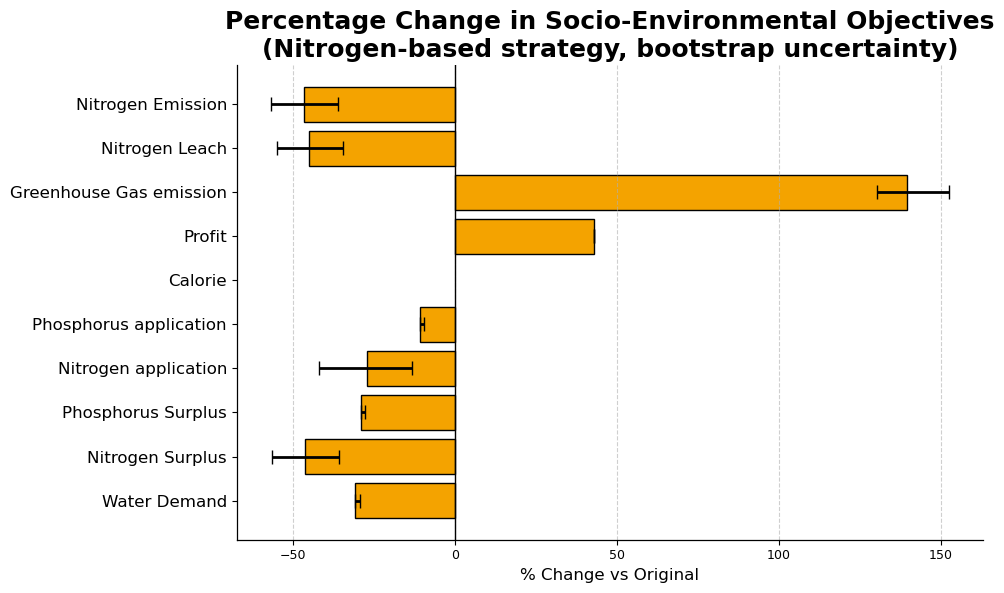


=== Nitrogen-based strategy: % change vs original (with bootstrap min/mean/max) ===
                 metric  mean_%  err_low_%  err_high_%  min_%  max_%
           Water Demand  -31.09       0.00        1.76 -30.69 -29.33
       Nitrogen Surplus  -46.49      10.26       10.46 -56.74 -36.03
     Phosphorus Surplus  -29.15       0.00        1.35 -28.77 -27.80
   Nitrogen application  -27.42      14.64       14.00 -42.05 -13.41
 Phosphorus application  -10.81       0.12        1.10 -10.93  -9.72
                Calorie     NaN       0.00        0.00    NaN    NaN
                 Profit   42.82       0.00        0.00  44.55  29.67
Greenhouse Gas emission  139.51       9.07       13.11 130.43 152.62
         Nitrogen Leach  -45.16       9.94       10.48 -55.11 -34.68
      Nitrogen Emission  -46.80      10.25       10.49 -57.05 -36.30


In [166]:
# -*- coding: utf-8 -*-
# Full updated code: Bootstrapping uncertainty + AGHG breakdown + N-surplus optimization
# + Calories and all components + single-series (orange) plot vs original baseline with uncertainty

import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

# =========================================================
# 0) Utilities: enforce canonical key columns (lowercase)
# =========================================================
def ensure_lowercase_keys(df):
    """Return a copy with ['State','District','Crop'] renamed to lowercase if present."""
    mapping = {'State': 'state', 'District': 'district', 'Crop': 'crop'}
    cols_to_rename = {k: v for k, v in mapping.items() if k in df.columns}
    if cols_to_rename:
        df = df.rename(columns=cols_to_rename)
    return df

# Ensure source frames have lowercase keys for groupbys/joins/lookups
kharif      = ensure_lowercase_keys(kharif)
kharif_2017 = ensure_lowercase_keys(kharif_2017)
kharif_max  = ensure_lowercase_keys(kharif_max)

# =========================================================
# 1) AGHG factors and constants
# =========================================================
AGHG_FACTORS_PATH = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv"

aghg_df = pd.read_csv(AGHG_FACTORS_PATH)
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Residue burning per-kg factors (kg CO2e / kg product)
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))

# Rice CH4 per ha (kg CO2e / ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# N2O constants
N2O_GWP = 273                 # AR6 (100-yr)
USE_N2O_N = False             # Flip True if fn2o is N2O-N fraction
MOLAR_RATIO_N2O = 44/28       # N2O-N -> N2O

# =========================================================
# 2) Bootstrapping helpers
# =========================================================
def bootstrap_nutrient_stats(df, value_col, n_iterations=1000):
    """
    Build {(state,district,crop): {'min','mean','max'}} from 2009–2020 data
    for the specified value_col, using bootstrap of means.
    """
    stats_dict = {}
    grouped = df.groupby(['state', 'district', 'crop'])
    for (s, d, c), group in grouped:
        values = group[value_col].dropna().values
        if len(values) > 0:
            samples = np.random.choice(values, size=(n_iterations, len(values)), replace=True)
            boot_means = samples.mean(axis=1)
            stats_dict[(str(s).lower(), str(d).lower(), str(c).lower())] = {
                'min' : float(boot_means.min()),
                'mean': float(boot_means.mean()),
                'max' : float(boot_means.max())
            }
    return stats_dict

def fill_with_bootstrap_or_state(df, stats_dict, state_means, default='mean'):
    """
    For each row in df, return the bootstrapped stat (min/mean/max) if available,
    otherwise fall back to state-level mean (dict keyed by (state,crop)).
    Accepts df with either lowercase or capitalized key columns.
    """
    # Resolve key columns
    s_col = 'state'    if 'state'    in df.columns else 'State'
    d_col = 'district' if 'district' in df.columns else 'District'
    c_col = 'crop'     if 'crop'     in df.columns else 'Crop'

    out = []
    for _, row in df.iterrows():
        s = str(row[s_col]).lower()
        d = str(row[d_col]).lower()
        c = str(row[c_col]).lower()
        key = (s, d, c)
        fallback_key = (s, c)  # state_means are built with lowercase keys below

        if key in stats_dict:
            out.append(stats_dict[key][default])
        else:
            out.append(state_means.get(fallback_key, np.nan))
    return out

# Precompute bootstrap stats from 2009–2020
n_applied_stats = bootstrap_nutrient_stats(kharif, 'N_applied(kg/ha)', n_iterations=1000)
manure_stats    = bootstrap_nutrient_stats(kharif, 'Manure (kg/ha)',  n_iterations=1000)

# State×crop fallback means (lowercase keys)
state_crop_n_applied_mean = (
    kharif.groupby(['state','crop'])['N_applied(kg/ha)'].mean()
    .reset_index().assign(state=lambda x: x['state'].str.lower(),
                          crop =lambda x: x['crop'].str.lower())
    .set_index(['state','crop'])['N_applied(kg/ha)'].to_dict()
)
state_crop_manure_mean = (
    kharif.groupby(['state','crop'])['Manure (kg/ha)'].mean()
    .reset_index().assign(state=lambda x: x['state'].str.lower(),
                          crop =lambda x: x['crop'].str.lower())
    .set_index(['state','crop'])['Manure (kg/ha)'].to_dict()
)

# =========================================================
# 3) Optimization model (objective = Min N surplus), with AGHG breakdown
# =========================================================
def run_model_with_modifier(modifier):
    """Runs optimization on a copy of global kharif_2017 and returns all metrics."""
    import numpy as np

    def _sanitize_numeric(s):
        s = pd.to_numeric(s, errors='coerce')
        s = s.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return s

    def _mkdict(df, keys, col):
        ser = df.set_index(keys)[col] if isinstance(col, str) else df[col]
        ser = _sanitize_numeric(ser)
        return ser.to_dict()

    # ---- Copy working data ----
    df = kharif_2017.copy()

    # ---- Apply component multipliers if provided ----
    for comp, factor in modifier.items():
        if comp in df.columns:
            df[comp] = pd.to_numeric(df[comp], errors='coerce') * float(factor)

    # ---- Recompute net N and P applied ----
    for c in ['N_applied(kg/ha)','Manure (N_kg/ha)','atm_depo','BNF_kg_per_hec',
              'P_applied(kg/ha)','Manure (P_kg/ha)']:
        if c in df.columns:
            df[c] = _sanitize_numeric(df[c])

    df['net_N_applied(kg/ha)'] = (
        df.get('N_applied(kg/ha)', 0) +
        df.get('Manure (N_kg/ha)', 0) +
        df.get('atm_depo', 0) +
        df.get('BNF_kg_per_hec', 0)
    )
    df['net_P_applied(kg/ha)'] = (
        df.get('P_applied(kg/ha)', 0) +
        df.get('Manure (P_kg/ha)', 0)
    )

    # ---- Preprocessing ----
    kharif_max['crop'] = kharif_max['crop'].astype(str).str.lower().str.strip()

    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize']
    df = df[df['crop'].isin(selected_crops)].copy()
    kharif_max_f = kharif_max[kharif_max['crop'].isin(selected_crops)].copy()

    # Standardize case/spacing
    for col in ['state','district','crop']:
        df[col] = df[col].astype(str).str.lower().str.strip()

    # Replace -1s and compute yield kg/ha (sanitize all numerics used later)
    df['Area (Hectare)']        = _sanitize_numeric(df['Area (Hectare)']).replace(-1, 0)
    df['Production (Tonnes)']   = _sanitize_numeric(df['Production (Tonnes)']).replace(-1, 0)
    df['Yield (Tonnes/Hectare)']= _sanitize_numeric(df['Yield (Tonnes/Hectare)']).replace(-1, 0)
    df['YIELD (Kg per ha)']     = 1000.0 * df['Yield (Tonnes/Hectare)']

    # CWR sanitize + fill
    if 'CWR m3/ha' in df.columns:
        df['CWR m3/ha'] = _sanitize_numeric(df['CWR m3/ha'])
        if df['CWR m3/ha'].isnull().any() and 'CWR m3/ha' in kharif.columns:
            fallback = (kharif.groupby('crop')['CWR m3/ha'].transform('mean'))
            df['CWR m3/ha'] = df['CWR m3/ha'].fillna(fallback)
        df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0.0)
    else:
        df['CWR m3/ha'] = 0.0

    # Calories per kg
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg = {k: v*10 for k, v in calorie_per_100g.items()}
    df['Calorie Supply (per KG)'] = df['crop'].map(calorie_per_kg).fillna(0.0)

    # Economic terms (sanitize)
    for c in ['Cost_of_Production_rs_Quintal','MSP_RsperQntl']:
        if c in df.columns:
            df[c] = _sanitize_numeric(df[c])
        else:
            df[c] = 0.0

    df['Total Calorie Supply'] = 1000.0 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost']    = 10.0   * df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']
    df['Total MSP Supply']     = 10.0   * df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit'] = df['Total MSP Supply'] - df['Total Farmer Cost']

    # ===== DICTS (ALL SANITIZED) =====
    max_area_constraints = _mkdict(kharif_max_f, ['state','district','crop'], 'Area (Hectare)')

    yield_data = _mkdict(df, ['state','district','crop'], 'YIELD (Kg per ha)')
    current_area = _mkdict(df.groupby(['state','district'], as_index=False)['Area (Hectare)'].sum(),
                           ['state','district'], 'Area (Hectare)')

    # Sanitize the columns that feed the objective/constraints
    for col in ['n_removed_rate','fno3','fn2o','p_removed_rate',
                'net_N_applied(kg/ha)','net_P_applied(kg/ha)','CWR m3/ha',
                'Calorie Supply (per KG)','Cost_of_Production_rs_Quintal','MSP_RsperQntl',
                'N_applied(kg/ha)','P_applied(kg/ha)','Manure (N_kg/ha)','Manure (P_kg/ha)']:
        df[col] = _sanitize_numeric(df[col]) if col in df.columns else 0.0

    nitrogen_rate                = _mkdict(df, ['state','district','crop'], 'net_N_applied(kg/ha)')
    nitrogen_removal_rate_perkg  = _mkdict(df, ['state','district','crop'], 'n_removed_rate')
    nitrogen_leach_rate_perkg    = _mkdict(df, ['state','district','crop'], 'fno3')
    nitrogen_emission_rate_perkg = _mkdict(df, ['state','district','crop'], 'fn2o')
    P_rate                       = _mkdict(df, ['state','district','crop'], 'net_P_applied(kg/ha)')
    P_removal_rate_perkg         = _mkdict(df, ['state','district','crop'], 'p_removed_rate')
    water_rate                   = _mkdict(df, ['state','district','crop'], 'CWR m3/ha')
    calories_per_prod            = _mkdict(df, ['state','district','crop'], 'Calorie Supply (per KG)')
    cost_per_area                = _mkdict(df, ['state','district','crop'], 'Cost_of_Production_rs_Quintal')
    MSP_per_prod                 = _mkdict(df, ['state','district','crop'], 'MSP_RsperQntl')
    N_applied_rate               = _mkdict(df, ['state','district','crop'], 'N_applied(kg/ha)')
    P_applied_rate               = _mkdict(df, ['state','district','crop'], 'P_applied(kg/ha)')
    district_to_state            = df.set_index('district')['state'].to_dict()

    states    = df['state'].unique().tolist()
    districts = df['district'].unique().tolist()
    cereals   = df['crop'].unique().tolist()

    # ===== OPTIMIZATION =====
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), lowBound=0, cat=pulp.LpContinuous)

    # Objective (Min N surplus)
    prob += pulp.lpSum([
        x[s][d][c] * (
            float(nitrogen_rate.get((s,d,c), 0.0)) -
            (float(yield_data.get((s,d,c), 0.0)) * float(nitrogen_removal_rate_perkg.get((s,d,c), 0.0)))
        )
        for s in states for d in districts for c in cereals
    ])

    # Area conservation
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == float(current_area.get((s,d), 0.0))

    # Max area constraints
    for s in states:
        for d in districts:
            for c in cereals:
                if (s,d,c) in max_area_constraints:
                    prob += x[s][d][c] <= float(max_area_constraints[(s,d,c)])

    # Historical zero area constraint
    for s in states:
        for d in districts:
            for c in cereals:
                if float(historical_cereal_area.get((s,d,c), 0.0)) == 0.0:
                    prob += x[s][d][c] == 0

    # State-level calorie and profit constraints
    initial_state_calories = pd.to_numeric(df.groupby('state')['Total Calorie Supply'].sum(), errors='coerce').fillna(0.0)
    for s in states:
        prob += pulp.lpSum([
            x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * float(calories_per_prod.get((s,d,c),0.0))
            for d in districts for c in cereals
        ]) >= float(initial_state_calories.get(s, 0.0))

    initial_state_profit = pd.to_numeric(df.groupby('state')['Total initial profit'].sum(), errors='coerce').fillna(0.0)
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * 0.01 * float(MSP_per_prod.get((s,d,c),0.0))) -
            (x[s][d][c] * float(yield_data.get((s,d,c),0.0)) * 0.01 * float(cost_per_area.get((s,d,c),0.0)))
            for d in districts if district_to_state.get(d)==s for c in cereals
        ]) >= float(initial_state_profit.get(s, 0.0))

    # Solve
    solver = pulp.PULP_CBC_CMD()
    _ = prob.solve(solver)

    # ------- AGHG calculator with breakdown -------
    def aghg_from_area_breakdown(s, d, c, area_ha):
        area_ha = float(area_ha or 0.0)
        if area_ha <= 0:
            return {"burning": 0.0, "rice_ch4": 0.0, "soil_n2o": 0.0, "total": 0.0}

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area_ha * yld_kg_ha

        # Residue burning + rice CH4
        if c_key == "rice":
            burning = prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = area_ha * float(rice_ch4_per_ha.get(s_key, 0.0))
        elif c_key == "wheat":
            burning = prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        elif c_key == "maize":
            burning = prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        elif c_key in ["bajra", "jowar", "ragi"]:
            burning = prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4 = 0.0
        else:
            burning = 0.0
            rice_ch4 = 0.0

        # Soil N2O from N surplus
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus      = area_ha * n_appl - prod_kg * n_rem_perkg     # kg N
        n2o_from_nsur  = n_surplus * fn2o                             # N2O or N2O-N
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O                          # N2O-N -> N2O
        soil_n2o = n2o_from_nsur * N2O_GWP                            # kg CO2e

        total = burning + rice_ch4 + soil_n2o
        return {"burning": burning, "rice_ch4": rice_ch4, "soil_n2o": soil_n2o, "total": total}

    # ------- Collect optimized outcomes (all finite) -------
    optimized_total_nitrogen_surplus = 0.0
    optimized_total_P_surplus = 0.0
    optimal_water = 0.0
    optimal_profit = 0.0
    optimal_calories = 0.0
    opt_N_application = 0.0
    opt_P_application = 0.0
    opt_N_leach = 0.0
    opt_N_emission = 0.0

    aghg_burning = aghg_rice_ch4 = aghg_soil_n2o = 0.0

    for s in states:
        for d in districts:
            for c in cereals:
                area_val = float(pulp.value(x[s][d][c]) or 0.0)
                yld = float(yield_data.get((s,d,c),0.0))
                prod_kg = area_val * yld

                n_appl = float(nitrogen_rate.get((s,d,c),0.0))
                p_appl = float(P_rate.get((s,d,c),0.0))
                n_rem  = float(nitrogen_removal_rate_perkg.get((s,d,c),0.0))
                p_rem  = float(P_removal_rate_perkg.get((s,d,c),0.0))

                n_sur = area_val * n_appl - prod_kg * n_rem
                p_sur = area_val * p_appl - prod_kg * p_rem

                optimized_total_nitrogen_surplus += n_sur
                optimized_total_P_surplus += p_sur

                opt_N_application += area_val * float(N_applied_rate.get((s,d,c),0.0))
                opt_P_application += area_val * float(P_applied_rate.get((s,d,c),0.0))

                opt_N_leach    += n_sur * float(nitrogen_leach_rate_perkg.get((s,d,c),0.0))
                opt_N_emission += n_sur * float(nitrogen_emission_rate_perkg.get((s,d,c),0.0))

                optimal_water += area_val * float(water_rate.get((s,d,c),0.0))
                optimal_profit += ((0.01*area_val)*yld*float(MSP_per_prod.get((s,d,c),0.0))
                                   - (0.01*area_val)*yld*float(cost_per_area.get((s,d,c),0.0)))
                optimal_calories += area_val * yld * float(calories_per_prod.get((s,d,c),0.0))

                # AGHG breakdown
                comp = aghg_from_area_breakdown(s, d, c, area_val)
                aghg_burning  += comp["burning"]
                aghg_rice_ch4 += comp["rice_ch4"]
                aghg_soil_n2o += comp["soil_n2o"]

    optimal_AGHG_total = aghg_burning + aghg_rice_ch4 + aghg_soil_n2o

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "P_surplus": optimized_total_P_surplus,
        "Water": optimal_water,
        "Profit": optimal_profit,
        "Calories": optimal_calories,
        "AGHG": optimal_AGHG_total,
        "AGHG_burning": aghg_burning,
        "AGHG_rice_ch4": aghg_rice_ch4,
        "AGHG_soil_n2o": aghg_soil_n2o,
        "N_application": opt_N_application,
        "P_application": opt_P_application,
        "N_leach": opt_N_leach,
        "N_emission": opt_N_emission
    }

# =========================================================
# 4) Uncertainty runs vs FIXED original baseline (no bootstrap)
# =========================================================
# Fixed baseline from original (unbootstrapped) kharif_2017
original_2017_df = ensure_lowercase_keys(kharif_2017.copy())

def compute_baseline_totals(df):
    df = ensure_lowercase_keys(df).copy()
    # Ensure all needed columns exist & numeric
    needed = ['Area (Hectare)','Yield (Tonnes/Hectare)','YIELD (Kg per ha)',
              'Production (Tonnes)','net_N_applied(kg/ha)','net_P_applied(kg/ha)',
              'N_applied(kg/ha)','P_applied(kg/ha)','Manure (N_kg/ha)','Manure (P_kg/ha)',
              'n_removed_rate','p_removed_rate','fno3','fn2o','CWR m3/ha',
              'Calorie Supply (per KG)','Cost_of_Production_rs_Quintal','MSP_RsperQntl',
              'state','district','crop']
    for c in needed:
        if c not in df.columns: df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors='coerce').replace([np.inf,-np.inf], np.nan).fillna(0.0)

    prod_kg = df['Area (Hectare)'] * df['YIELD (Kg per ha)']
    n_sur   = df['Area (Hectare)'] * df['net_N_applied(kg/ha)'] - prod_kg * df['n_removed_rate']
    p_sur   = df['Area (Hectare)'] * df['net_P_applied(kg/ha)'] - prod_kg * df['p_removed_rate']

    base = {
        'N_surplus'      : float(n_sur.sum()),
        'P_surplus'      : float(p_sur.sum()),
        'Water'          : float((df['Area (Hectare)'] * df['CWR m3/ha']).sum()),
        'Profit'         : float((10*df['Production (Tonnes)']*df['MSP_RsperQntl']
                                  - 10*df['Production (Tonnes)']*df['Cost_of_Production_rs_Quintal']).sum()),
        'Calories'       : float((1000*df['Production (Tonnes)']*df['Calorie Supply (per KG)']).sum()),
        'N_application'  : float((df['Area (Hectare)'] * df['N_applied(kg/ha)']).sum()),
        'P_application'  : float((df['Area (Hectare)'] * df['P_applied(kg/ha)']).sum()),
        'N_leach'        : float((n_sur * df['fno3']).sum()),
        'N_emission'     : float((n_sur * df['fn2o']).sum()),
        'AGHG'           : 0.0  # set below
    }

    # Baseline AGHG
    state_key = df['state'].astype(str).str.lower()
    crop_key  = df['crop'].astype(str).str.lower()
    burn_factor = np.select(
        [
            crop_key.eq('rice'),
            crop_key.eq('wheat'),
            crop_key.eq('maize'),
            crop_key.isin(['bajra','jowar','ragi'])
        ],
        [
            state_key.map(rice_burn_CO2eq_perkg).fillna(0.0).values,
            state_key.map(wheat_burn_CO2eq_perkg).fillna(0.0).values,
            state_key.map(maize_burn_CO2eq_perkg).fillna(0.0).values,
            state_key.map(millets_burn_CO2eq_perkg).fillna(0.0).values
        ],
        default=0.0
    ).astype(float)
    rice_ch4 = np.where(
        crop_key.eq('rice'),
        df['Area (Hectare)'] * state_key.map(rice_ch4_per_ha).fillna(0.0).astype(float).values,
        0.0
    )
    burning = (prod_kg * burn_factor)
    soil_n2o = n_sur * df['fn2o']
    if USE_N2O_N:
        soil_n2o = soil_n2o * MOLAR_RATIO_N2O
    soil_n2o_co2e = soil_n2o * N2O_GWP
    base['AGHG'] = float((burning + rice_ch4 + soil_n2o_co2e).sum())
    return base

base_original = compute_baseline_totals(original_2017_df)

# Run min/mean/max bootstrapped optimizations collecting results
uncertainty_results = []

for case in ['min', 'mean', 'max']:
    kharif_2017_uncertain = ensure_lowercase_keys(kharif_2017.copy())
    kharif_2017_uncertain['N_applied(kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_uncertain, n_applied_stats, state_crop_n_applied_mean, default=case
    )
    kharif_2017_uncertain['Manure (kg/ha)'] = fill_with_bootstrap_or_state(
        kharif_2017_uncertain, manure_stats, state_crop_manure_mean, default=case
    )
    kharif_2017_uncertain['net_N_applied(kg/ha)'] = (
        pd.to_numeric(kharif_2017_uncertain['N_applied(kg/ha)'], errors='coerce').fillna(0.0) +
        pd.to_numeric(kharif_2017_uncertain['Manure (N_kg/ha)'], errors='coerce').fillna(0.0) +
        pd.to_numeric(kharif_2017_uncertain['atm_depo'], errors='coerce').fillna(0.0) +
        pd.to_numeric(kharif_2017_uncertain['BNF_kg_per_hec'], errors='coerce').fillna(0.0)
    )

    # Use this scenario as working df for the optimizer
    kharif_2017 = kharif_2017_uncertain.copy()

    res = run_model_with_modifier({})
    res['scenario'] = case
    uncertainty_results.append(res)

# =========================================================
# 5) % change vs original baseline + single orange plot with uncertainty
# =========================================================
unc_df = pd.DataFrame(uncertainty_results).set_index('scenario').sort_index()

def pct_change(opt_val, base_val):
    if pd.isna(base_val) or base_val == 0 or pd.isna(opt_val):
        return np.nan
    return 100.0 * (opt_val - base_val) / base_val

# Desired order for the plot
desired_metrics = [
    'Water','N_surplus','P_surplus',
    'N_application','P_application',
    'Calories','Profit',
    'AGHG','N_leach','N_emission'
]
metric_labels = [
    'Water Demand','Nitrogen Surplus','Phosphorus Surplus',
    'Nitrogen application','Phosphorus application',
    'Calorie','Profit',
    'Greenhouse Gas emission','Nitrogen Leach','Nitrogen Emission'
]
metric_map = dict(zip(desired_metrics, metric_labels))

# Keep only metrics present in results (robust to older function versions)
metrics_plot = [m for m in desired_metrics if m in unc_df.columns]
labels_plot  = [metric_map[m] for m in metrics_plot]
missing = [m for m in desired_metrics if m not in unc_df.columns]
if missing:
    print("⚠️ Skipping missing metrics (not returned by optimizer):", missing)

# Build % change table vs FIXED original baseline
pct_rows = []
for scn in ['min','mean','max']:
    row = {'scenario': scn}
    for m in metrics_plot:
        base_val = base_original.get(m, np.nan)
        opt_val  = unc_df.loc[scn, m]
        row[m] = pct_change(opt_val, base_val)
    pct_rows.append(row)

pct_df = pd.DataFrame(pct_rows).set_index('scenario').sort_index()

# Values from mean; asymmetric errors from min/max (bootstrap uncertainty)
vals   = [pct_df.loc['mean', m] for m in metrics_plot]
err_lo = [max(0.0, pct_df.loc['mean', m] - pct_df.loc['min', m]) for m in metrics_plot]
err_hi = [max(0.0, pct_df.loc['max',  m] - pct_df.loc['mean', m]) for m in metrics_plot]

# ---------------------------
# PLOT: Single orange series
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(metrics_plot))

ax.barh(
    y, vals, xerr=[err_lo, err_hi], capsize=5,
    edgecolor='black', ecolor='black',
    color='#f4a300'  # orange for nitrogen-based
)

ax.set_yticks(y)
ax.set_yticklabels(labels_plot, fontsize=12)
ax.set_xlabel('% Change vs Original', fontsize=12)
ax.set_title('Percentage Change in Socio-Environmental Objectives\n(Nitrogen-based strategy, bootstrap uncertainty)', fontsize=18, weight='bold')
ax.axvline(0, color='black', linewidth=1)
ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Optional: compact table for reporting
summary_df = pd.DataFrame({
    'metric'    : labels_plot,
    'mean_%'    : vals,
    'err_low_%' : err_lo,
    'err_high_%': err_hi,
    'min_%'     : [pct_df.loc['min', m] for m in metrics_plot],
    'max_%'     : [pct_df.loc['max', m] for m in metrics_plot],
})
print("\n=== Nitrogen-based strategy: % change vs original (with bootstrap min/mean/max) ===")
print(summary_df.to_string(index=False))


In [172]:
# -*- coding: utf-8 -*-
"""
Kharif optimization with bootstrap uncertainty on N_applied and Manure(kg/ha)
- Resample across years (2009–2018) within (state, district, crop)
- Keep atm_depo and BNF fixed
- Run same LP (minimize N surplus) each iteration
- Aggregate state & national metrics; compute mean and 95% CI
- Save CSVs + publication-ready plots (with non-negative error bars)

Author: (Shekhar + ChatGPT)
"""

import os
import math
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
N_BOOT = 1000
RANDOM_SEED = 42
OUTPUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CBC solver settings (quiet + time limit)
SOLVER = pulp.PULP_CBC_CMD(msg=False, timeLimit=120)

# Use 95% CI as 2.5–97.5 percentiles
LOW_Q, HIGH_Q = 2.5, 97.5

# Crops to include (Kharif)
SELECTED_CROPS = ['bajra', 'jowar', 'ragi', 'rice', 'maize']

# Constants
N2O_GWP = 273                 # 1 kg N2O = 273 kg CO2e (IPCC AR6)
USE_N2O_N = False             # Set True if fn2o yields N2O-N
MOLAR_RATIO_N2O = 44.0/28.0   # Convert N2O-N -> N2O when needed

# ----------------------------
# 1) LOAD + PREP DATA (paths from your setup)
# ----------------------------
kharif = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\kharif_waterdemand.csv")
rabi   = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\rabi_waterdemand.csv")  # not used here
CoP    = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\cost_of_production.csv")
bnf_applied = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\bnf\bnf_app.csv")
atm_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\atmospheric_depo_isimip_2a.csv")
image_coeff = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\trial_analysis\image_coeff.csv")
kharif_max = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_max.csv")
aghg_factors = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# CoP merge (normalize case/whitespace)
CoP['State'] = CoP['State'].str.strip().str.lower()
CoP['Crop']  = CoP['Crop'].str.strip().str.lower()
CoP_renamed = CoP.rename(columns={
    "Crop": "crop",
    "State": "state",
    "CostofProduction_rs_Quintal": "Cost_of_Production_rs_Quintal"
})
kharif = pd.merge(kharif, CoP_renamed, how='left', on=['state', 'Year', 'crop'])

# Map atm_df states to kharif naming and merge
state_name_mapping = {
    'Andaman and Nicobar': 'andaman and nicobar',
    'Andhra Pradesh': 'andhra pradesh',
    'Arunachal Pradesh': 'arunachal pradesh',
    'Assam': 'assam',
    'Bihar': 'bihar',
    'Chandigarh': 'chandigarh',
    'Chhattisgarh': 'chhattisgarh',
    'Dadra and Nagar Haveli': 'dadra and nagar haveli',
    'Daman and Diu': 'the dadra and nagar haveli and daman and diu',
    'Delhi': 'delhi',
    'Goa': 'goa',
    'Gujarat': 'gujarat',
    'Haryana': 'haryana',
    'Himachal Pradesh': 'himachal pradesh',
    'Jammu and Kashmir': 'jammu and kashmir',
    'Jharkhand': 'jharkhand',
    'Karnataka': 'karnataka',
    'Kerala': 'kerala',
    'Lakshadweep': 'lakshadweep',
    'Madhya Pradesh': 'madhya pradesh',
    'Maharashtra': 'maharashtra',
    'Manipur': 'manipur',
    'Meghalaya': 'meghalaya',
    'Mizoram': 'mizoram',
    'Nagaland': 'nagaland',
    'Orissa': 'odisha',
    'Puducherry': 'puducherry',
    'Punjab': 'punjab',
    'Rajasthan': 'rajasthan',
    'Sikkim': 'sikkim',
    'Tamil Nadu': 'tamil nadu',
    'Telangana': 'telangana',
    'Tripura': 'tripura',
    'Uttar Pradesh': 'uttar pradesh',
    'Uttaranchal': 'uttarakhand',
    'West Bengal': 'west bengal',
}
atm_df['State'] = atm_df['State'].map(state_name_mapping)
atm_df.rename(columns={'State': 'state'}, inplace=True)
kharif = pd.merge(kharif, atm_df, on=['state', 'Year'], how='left')

# Merge BNF (kept fixed through bootstrap)
kharif = pd.merge(kharif, bnf_applied, on=['Year'], how='left')

# IMAGE coeff: fn2o & fno3 (percent -> fraction)
image_coeff.rename(columns={
    'fN2O[% of Nsurplus]': 'fn2o',
    'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'
}, inplace=True)
image_coeff['State'] = image_coeff['State'].str.lower().str.strip()
image_coeff['fn2o'] = image_coeff['fn2o'] / 100.0
image_coeff['fno3'] = image_coeff['fno3'] / 100.0
state_replace = {
    'the dadra and nagar haveli and daman and diu':'dadra and nagar haveli',
    'andaman and nicobar islands':'andaman and nicobar'
}
image_coeff['State'] = image_coeff['State'].replace(state_replace)
image_coeff.rename(columns={'State': 'state'}, inplace=True)
kharif = pd.merge(kharif, image_coeff, on=['state'], how='left')

# Clean columns
for c in ['Unnamed: 0']:
    if c in kharif.columns:
        del kharif[c]
for c in ['Unnamed: 0']:
    if c in rabi.columns:
        del rabi[c]

# Manure -> N, P (kg/ha)
kharif['Manure (N_kg/ha)'] = pd.to_numeric(kharif['Manure (kg/ha)'], errors='coerce') * 0.005
kharif['Manure (P_kg/ha)'] = pd.to_numeric(kharif['Manure (kg/ha)'], errors='coerce') * 0.002

# Ensure numerics + NaN handling
num_cols = [
    'N_applied(kg/ha)','Manure (N_kg/ha)','P_applied(kg/ha)','Manure (P_kg/ha)',
    'CWR m3/ha','CWU green m3/ha','CWU blue m3/ha','K_applied(kg/ha)',
    'BNF_kg_per_hec','atm_depo','Area (Hectare)','Production (Tonnes)','Yield (Tonnes/Hectare)',
    'Manure (kg/ha)','Cost_of_Production_rs_Quintal','MSP_RsperQntl'
]
for c in num_cols:
    if c in kharif.columns:
        kharif[c] = pd.to_numeric(kharif[c], errors='coerce')

# Replace zeros with NaN for averages
for c in ['N_applied(kg/ha)','Manure (N_kg/ha)','P_applied(kg/ha)','Manure (P_kg/ha)','CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']:
    if c in kharif.columns:
        kharif[c] = kharif[c].replace(0, np.nan)
# Replace +/- inf with NaN
for c in ['N_applied(kg/ha)','P_applied(kg/ha)','K_applied(kg/ha)']:
    if c in kharif.columns:
        kharif[c] = kharif[c].replace([np.inf,-np.inf], np.nan)

# Net applied (baseline quick view; recomputed later)
kharif['net_N_applied(kg/ha)'] = kharif['N_applied(kg/ha)'] + kharif['Manure (N_kg/ha)'] + kharif['atm_depo'] + kharif['BNF_kg_per_hec']
kharif['net_P_applied(kg/ha)'] = kharif['P_applied(kg/ha)'] + kharif['Manure (P_kg/ha)']

# Historical area constraints data
if 'Unnamed: 0' in kharif_max.columns:
    del kharif_max['Unnamed: 0']
kharif_max.rename(columns={'district': 'District', 'state':'State','crop':'Crop'}, inplace=True)
kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()

# Nutrient content (kg nutrient / kg grain)
crop_nitrogen_content = {'rice':0.0129,'jowar':0.0146,'bajra':0.0204,'maize':0.0124,'ragi':0.0204}
crop_phosphorous_content = {'rice':0.0028,'jowar':0.0045,'bajra':0.0042,'maize':0.0034,'ragi':0.0042}

# ----------------------------
# 2) BUILD 2017 SNAPSHOT (fixed baseline)
# ----------------------------
# 3-year window for some cols; keep Year=2017 rows for others
mean_cols = ['N_applied(kg/ha)','P_applied(kg/ha)','K_applied(kg/ha)','Manure (kg/ha)','Cost_of_Production_rs_Quintal']
subset_3yrs = kharif[kharif['Year'].isin([2016,2017,2018])].copy()
subset_2017 = kharif[kharif['Year']==2017].copy()

mean_part = subset_3yrs.groupby(['state','district','crop'], as_index=False)[mean_cols].mean()
non_mean_cols = [c for c in subset_2017.columns if c not in mean_cols]
subset_2017_part = subset_2017[non_mean_cols].copy()

kharif_2017 = pd.merge(subset_2017_part, mean_part, on=['state','district','crop'], how='left')

# Fill by crop averages when missing
fill_cols = ['N_applied(kg/ha)','P_applied(kg/ha)','K_applied(kg/ha)','Manure (kg/ha)','Cost_of_Production_rs_Quintal']
for col in fill_cols:
    kharif_2017[col] = kharif_2017[col].fillna(kharif_2017.groupby('crop')[col].transform('mean'))

# Fill water by (state,crop) average
for col in ['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']:
    kharif_2017[col] = kharif_2017[col].fillna(kharif_2017.groupby(['state','crop'])[col].transform('mean'))
kharif_2017['CWR m3/ha'] = kharif_2017['CWR m3/ha'].fillna(0)

# Manure N/P for 2017 (baseline)
kharif_2017['Manure (N_kg/ha)'] = (kharif_2017['Manure (kg/ha)'].fillna(0))*0.005
kharif_2017['Manure (P_kg/ha)'] = (kharif_2017['Manure (kg/ha)'].fillna(0))*0.002

# Net applied (baseline)
kharif_2017['net_N_applied(kg/ha)'] = kharif_2017['N_applied(kg/ha)'] + kharif_2017['Manure (N_kg/ha)'] + kharif_2017['atm_depo'] + kharif_2017['BNF_kg_per_hec']
kharif_2017['net_P_applied(kg/ha)'] = kharif_2017['P_applied(kg/ha)'] + kharif_2017['Manure (P_kg/ha)']

# Normalize keys/crop list
def norm(s): return str(s).strip().lower()
for c in ['state','district','crop']:
    kharif_2017[c] = kharif_2017[c].apply(norm)
kharif_2017 = kharif_2017[kharif_2017['crop'].isin(SELECTED_CROPS)].copy()

# Historical presence (2009–2018) — allowed triples
kharif_all = kharif.copy()
for c in ['state','district','crop']:
    kharif_all[c] = kharif_all[c].apply(norm)
hist_area = kharif_all.groupby(['state','district','crop'])['Area (Hectare)'].mean().fillna(0.0)
historical_cereal_area_dict = hist_area.to_dict()
allowed_triples = {(s,d,c) for (s,d,c),a in historical_cereal_area_dict.items() if a and not math.isnan(a)}

# Max area constraints per (State,District,Crop)
kharif_max['State'] = kharif_max['State'].apply(norm)
kharif_max['District'] = kharif_max['District'].apply(norm)
max_area_constraints = kharif_max.set_index(['State','District','Crop'])['Area (Hectare)'].to_dict()

# Yield (kg/ha)
kharif_2017['YIELD (Kg per ha)'] = 1000*kharif_2017['Yield (Tonnes/Hectare)'].replace(-1, 0)
yield_data = kharif_2017.set_index(['state','district','crop'])['YIELD (Kg per ha)'].to_dict()

# CWR (m3/ha)
water_rate = kharif_2017.set_index(['state','district','crop'])['CWR m3/ha'].to_dict()

# Nutrient removal per kg grain
kharif_2017['n_removed_rate'] = kharif_2017['crop'].map(crop_nitrogen_content).fillna(0.0)
kharif_2017['p_removed_rate'] = kharif_2017['crop'].map(crop_phosphorous_content).fillna(0.0)
n_removed_rate = kharif_2017.set_index(['state','district','crop'])['n_removed_rate'].to_dict()
p_removed_rate = kharif_2017.set_index(['state','district','crop'])['p_removed_rate'].to_dict()

# Calories per kg (FIX: map BEFORE set_index)
calorie_per_100g = {'ragi':321,'bajra':348,'rice':356,'jowar':334,'wheat':322,'maize':342}
calorie_per_kg = {k:v*10 for k,v in calorie_per_100g.items()}
if 'Crop' in kharif_2017.columns and 'crop' not in kharif_2017.columns:
    kharif_2017.rename(columns={'Crop':'crop'}, inplace=True)
kharif_2017['crop'] = kharif_2017['crop'].astype(str).str.strip().str.lower()
kharif_2017['calories_per_kg'] = kharif_2017['crop'].map(calorie_per_kg).fillna(0.0)
calories_per_prod = kharif_2017.set_index(['state','district','crop'])['calories_per_kg'].to_dict()

# MSP & CoP (Rs per quintal)
MSP_per_prod = kharif_2017.set_index(['state','district','crop'])['MSP_RsperQntl'].to_dict()
cost_per_qntl = kharif_2017.set_index(['state','district','crop'])['Cost_of_Production_rs_Quintal'].to_dict()

# fn2o, fno3 (fraction)
fn2o = kharif_2017.set_index(['state','district','crop'])['fn2o'].to_dict()
fno3 = kharif_2017.set_index(['state','district','crop'])['fno3'].to_dict()

# atm_depo & BNF per ha (kept fixed)
atm_depo = kharif_2017.set_index(['state','district','crop'])['atm_depo'].to_dict()
BNF = kharif_2017.set_index(['state','district','crop'])['BNF_kg_per_hec'].to_dict()

# P applied baseline (synthetic only; manure P varies in bootstrap)
P_applied_base = kharif_2017.set_index(['state','district','crop'])['P_applied(kg/ha)'].to_dict()

# Baseline net applied rates (for baseline metrics)
nitrogen_rate_base = kharif_2017.set_index(['state','district','crop'])['net_N_applied(kg/ha)'].to_dict()
P_rate_base = kharif_2017.set_index(['state','district','crop'])['net_P_applied(kg/ha)'].to_dict()

# Current area / production (baseline original)
current_cereal_area = kharif_2017.set_index(['state','district','crop'])['Area (Hectare)'].to_dict()
current_cereal_prod = kharif_2017.set_index(['state','district','crop'])['Production (Tonnes)'].to_dict()

# District -> state map and sets for loops
district_to_state = kharif_2017[['state','district']].drop_duplicates().set_index('district')['state'].to_dict()
states = sorted(kharif_2017['state'].unique().tolist())
districts_by_state = {s: sorted(kharif_2017[kharif_2017['state']==s]['district'].unique().tolist()) for s in states}

# Total district-level area target (fixed)
current_area_sd = kharif_2017.groupby(['state','district'])['Area (Hectare)'].sum().to_dict()

# ----------------------------
# 3) AGHG FACTORS
# ----------------------------
aghg = aghg_factors.copy()
aghg['state_key'] = aghg['State'].astype(str).str.strip().str.lower()
rice_burn_CO2eq_perkg    = dict(zip(aghg["state_key"], aghg["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg["state_key"], aghg["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg["state_key"], aghg["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg["state_key"], aghg["Millets_CO2eq_perkg"]))
rice_ch4_per_ha          = dict(zip(aghg["state_key"], aghg["rice_ch4_co2_eq_per_ha"]))

def revenue_rupees(prod_kg, msp_rs_per_qntl): return 0.01*prod_kg*msp_rs_per_qntl
def cost_rupees(prod_kg, cop_rs_per_qntl):    return 0.01*prod_kg*cop_rs_per_qntl

def aghg_from_area_iter(s, d, c, area_ha, nitrogen_rate_dict):
    """kg CO2e for one triple, using per-iteration nitrogen_rate (for soils N2O)."""
    if area_ha is None or area_ha <= 0:
        return 0.0
    c_key = str(c).strip().lower()
    s_key = str(s).strip().lower()
    yld = yield_data.get((s,d,c),0.0)
    prod_kg = area_ha * yld
    total = 0.0
    # Residue burning + rice CH4
    if c_key == "rice":
        total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
        total += area_ha * float(rice_ch4_per_ha.get(s_key, 0.0))
    elif c_key == "wheat":
        total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key == "maize":
        total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key in ["bajra","jowar","ragi"]:
        total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
    # Soils N2O from N surplus
    n_app = nitrogen_rate_dict.get((s,d,c),0.0)
    n_rempk = n_removed_rate.get((s,d,c),0.0)
    n_sur = area_ha*n_app - prod_kg*n_rempk
    n_sur = max(n_sur, 0.0)
    n2o_term = n_sur * fn2o.get((s,d,c),0.0)
    if USE_N2O_N:
        n2o_term *= MOLAR_RATIO_N2O
    total += n2o_term * N2O_GWP
    return total

def compute_totals_with_aghg(area_dict, nitrogen_rate, P_rate):
    """Totals including AGHG; returns dict with all metrics."""
    totals = {
        'N_applied':0.0,'N_surplus':0.0,'N_leach':0.0,'N_emission':0.0,
        'P_applied':0.0,'P_surplus':0.0,'Water':0.0,
        'Calories':0.0,'Profit':0.0,'AGHG':0.0
    }
    for (s,d,c), area in area_dict.items():
        if area is None or area<=0:
            continue
        yld = yield_data.get((s,d,c),0.0)
        prod_kg = area * yld
        # Applied
        n_app = nitrogen_rate.get((s,d,c),0.0)
        p_app = P_rate.get((s,d,c),0.0)
        totals['N_applied'] += area * n_app
        totals['P_applied'] += area * p_app
        # Surplus & derivatives
        n_rempk = n_removed_rate.get((s,d,c),0.0)
        p_rempk = p_removed_rate.get((s,d,c),0.0)
        n_sur = area*n_app - prod_kg*n_rempk
        p_sur = area*p_app - prod_kg*p_rempk
        n_sur = max(n_sur, 0.0); p_sur = max(p_sur, 0.0)
        totals['N_surplus'] += n_sur
        totals['P_surplus'] += p_sur
        totals['N_leach']   += n_sur * fno3.get((s,d,c),0.0)
        totals['N_emission']+= n_sur * fn2o.get((s,d,c),0.0)
        # Water
        totals['Water']     += area * water_rate.get((s,d,c),0.0)
        # Calories
        totals['Calories']  += prod_kg * calories_per_prod.get((s,d,c),0.0)
        # Profit (Rs)
        rev = revenue_rupees(prod_kg, MSP_per_prod.get((s,d,c),0.0))
        cst = cost_rupees(prod_kg, cost_per_qntl.get((s,d,c),0.0))
        totals['Profit']    += (rev - cst)
        # AGHG
        totals['AGHG']      += aghg_from_area_iter(s,d,c,area, nitrogen_rate)
    return totals

def aggregate_by_state(area_dict, nitrogen_rate, P_rate):
    per_state = {}
    for (s,d,c), area in area_dict.items():
        if area is None or area<=0: 
            continue
        if s not in per_state:
            per_state[s] = {k:0.0 for k in ['N_applied','N_surplus','N_leach','N_emission','P_applied','P_surplus','Water','Calories','Profit','AGHG']}
        yld = yield_data.get((s,d,c),0.0)
        prod_kg = area * yld
        n_app = nitrogen_rate.get((s,d,c),0.0)
        p_app = P_rate.get((s,d,c),0.0)
        n_rempk = n_removed_rate.get((s,d,c),0.0)
        p_rempk = p_removed_rate.get((s,d,c),0.0)
        n_sur = max(area*n_app - prod_kg*n_rempk, 0.0)
        p_sur = max(area*p_app - prod_kg*p_rempk, 0.0)
        per_state[s]['N_applied'] += area*n_app
        per_state[s]['P_applied'] += area*p_app
        per_state[s]['N_surplus'] += n_sur
        per_state[s]['P_surplus'] += p_sur
        per_state[s]['N_leach']   += n_sur * fno3.get((s,d,c),0.0)
        per_state[s]['N_emission']+= n_sur * fn2o.get((s,d,c),0.0)
        per_state[s]['Water']     += area * water_rate.get((s,d,c),0.0)
        per_state[s]['Calories']  += prod_kg * calories_per_prod.get((s,d,c),0.0)
        rev = revenue_rupees(prod_kg, MSP_per_prod.get((s,d,c),0.0))
        cst = cost_rupees(prod_kg, cost_per_qntl.get((s,d,c),0.0))
        per_state[s]['Profit']    += (rev - cst)
        per_state[s]['AGHG']      += aghg_from_area_iter(s,d,c,area, nitrogen_rate)
    return per_state

# Baseline totals
orig_totals_nat = compute_totals_with_aghg(current_cereal_area, nitrogen_rate_base, P_rate_base)
orig_per_state  = aggregate_by_state(current_cereal_area, nitrogen_rate_base, P_rate_base)

# State-level calorie & profit constraints (baseline)
initial_state_calories = {s: orig_per_state[s]['Calories'] for s in states}
initial_state_profit   = {s: orig_per_state[s]['Profit']   for s in states}

# ----------------------------
# 4) BOOTSTRAP DRAW SETUP (N_applied, Manure(kg/ha) within group)
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

def get_group_series(df, s, d, c, col):
    g = df[(df['state']==s)&(df['district']==d)&(df['crop']==c)][col].dropna()
    return g.values

bootstrap_pool = {}  # (s,d,c) -> {'N': np.array, 'M': np.array}
for (s,d,c) in set(kharif_all.set_index(['state','district','crop']).index.tolist()):
    if c not in SELECTED_CROPS: 
        continue
    arrN = get_group_series(kharif_all, s,d,c, 'N_applied(kg/ha)')
    arrM = get_group_series(kharif_all, s,d,c, 'Manure (kg/ha)')
    bootstrap_pool[(s,d,c)] = {
        'N': arrN if arrN.size>0 else np.array([]),
        'M': arrM if arrM.size>0 else np.array([]),
    }

# Baseline fallback (fixed values if no pool)
fallback_N = kharif_2017.set_index(['state','district','crop'])['N_applied(kg/ha)'].to_dict()
fallback_M = kharif_2017.set_index(['state','district','crop'])['Manure (kg/ha)'].to_dict()

# ----------------------------
# 5) LP BUILDER (minimize N surplus)
# ----------------------------
def build_and_solve_lp(nitrogen_rate_iter, P_rate_iter):
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)

    # Decision vars only for allowed triples
    x = {}
    for s in states:
        for d in districts_by_state[s]:
            crops_here = [c for (ss,dd,c) in allowed_triples if ss==s and dd==d]
            for c in crops_here:
                x[(s,d,c)] = pulp.LpVariable(f"x__{s}__{d}__{c}", lowBound=0, cat=pulp.LpContinuous)

    # Objective: sum area * (n_appl - yield * n_removed_rate)
    prob += pulp.lpSum([
        x[(s,d,c)] * (nitrogen_rate_iter.get((s,d,c),0.0) - 
                      (yield_data.get((s,d,c),0.0) * n_removed_rate.get((s,d,c),0.0)))
        for (s,d,c) in x.keys()
    ])

    # Area = current total by (s,d)
    for s in states:
        for d in districts_by_state[s]:
            target = current_area_sd.get((s,d), None)
            if target is None:
                continue
            crops_here = [c for (ss,dd,c) in x.keys() if ss==s and dd==d]
            if not crops_here:
                continue
            prob += pulp.lpSum([x[(s,d,c)] for c in crops_here]) == target

    # Max area constraints
    for (s,d,c) in x.keys():
        if (s,d,c) in max_area_constraints:
            prob += x[(s,d,c)] <= max_area_constraints[(s,d,c)]

    # State calories >= baseline
    for s in states:
        vars_s = [(d,c) for (ss,d,c) in x.keys() if ss==s]
        if not vars_s:
            continue
        prob += pulp.lpSum([
            x[(s,d,c)] * yield_data.get((s,d,c),0.0) * calories_per_prod.get((s,d,c),0.0)
            for (d,c) in vars_s
        ]) >= initial_state_calories.get(s, 0.0)

    # State profit >= baseline
    for s in states:
        vars_s = [(d,c) for (ss,d,c) in x.keys() if ss==s]
        if not vars_s:
            continue
        profit_expr = pulp.lpSum([
            (0.01 * x[(s,d,c)] * yield_data.get((s,d,c),0.0) * MSP_per_prod.get((s,d,c),0.0)) -
            (0.01 * x[(s,d,c)] * yield_data.get((s,d,c),0.0) * cost_per_qntl.get((s,d,c),0.0))
            for (d,c) in vars_s
        ])
        prob += profit_expr >= initial_state_profit.get(s, 0.0)

    # Solve
    status = prob.solve(SOLVER)
    status_name = pulp.LpStatus[prob.status]

    # Extract solution
    x_sol = {k: float(pulp.value(var) or 0.0) for k,var in x.items()}
    return status_name, x_sol

# ----------------------------
# 6) BOOTSTRAP LOOP
# ----------------------------
metrics = ['N_surplus','N_applied','N_leach','N_emission','P_surplus','P_applied','Water','AGHG','Calories','Profit']
nat_changes_records = []   # iteration-level NATIONAL % changes
state_changes_records = [] # iteration-level STATE % changes (long-form)

for it in range(N_BOOT):
    # ---- Draw N_appl and Manure(kg/ha) per (s,d,c)
    draw_N = {}
    draw_M = {}
    for (s,d,c) in allowed_triples:
        pool = bootstrap_pool.get((s,d,c), {'N':np.array([]),'M':np.array([])})
        if pool['N'].size>0:
            draw_N[(s,d,c)] = float(rng.choice(pool['N'], replace=True))
        else:
            draw_N[(s,d,c)] = float(fallback_N.get((s,d,c), np.nan))
        if pool['M'].size>0:
            draw_M[(s,d,c)] = float(rng.choice(pool['M'], replace=True))
        else:
            draw_M[(s,d,c)] = float(fallback_M.get((s,d,c), 0.0))
        if math.isnan(draw_N[(s,d,c)]): draw_N[(s,d,c)] = 0.0
        if math.isnan(draw_M[(s,d,c)]): draw_M[(s,d,c)] = 0.0

    # ---- Build iteration rates
    nitrogen_rate_iter = {}
    P_rate_iter = {}
    for (s,d,c) in allowed_triples:
        manure_N = 0.005 * draw_M[(s,d,c)]
        manure_P = 0.002 * draw_M[(s,d,c)]
        # Keep atm_depo & BNF fixed
        n_appl = draw_N[(s,d,c)] + manure_N + atm_depo.get((s,d,c),0.0) + BNF.get((s,d,c),0.0)
        p_appl = (P_applied_base.get((s,d,c),0.0) or 0.0) + manure_P
        nitrogen_rate_iter[(s,d,c)] = n_appl
        P_rate_iter[(s,d,c)] = p_appl

    # ---- Solve LP
    status_name, x_sol = build_and_solve_lp(nitrogen_rate_iter, P_rate_iter)

    # ---- Aggregate NATIONAL totals for optimized
    opt_totals_nat = compute_totals_with_aghg(x_sol, nitrogen_rate_iter, P_rate_iter)

    # ---- NATIONAL % changes vs baseline original (fixed)
    nat_pct = {'iter': it, 'status': status_name}
    for k in metrics:
        orig = orig_totals_nat[k] if k in orig_totals_nat else 0.0
        opt  = opt_totals_nat[k]
        nat_pct[f'%Δ_{k}'] = (100.0*(orig - opt)/orig) if orig else 0.0
    nat_changes_records.append(nat_pct)

    # ---- STATE totals and % changes
    opt_per_state = aggregate_by_state(x_sol, nitrogen_rate_iter, P_rate_iter)
    for s in states:
        rec = {'iter': it, 'state': s}
        for k in metrics:
            orig = orig_per_state.get(s, {}).get(k, 0.0)
            opt  = opt_per_state.get(s, {}).get(k, 0.0)
            rec[f'%Δ_{k}'] = (100.0*(orig - opt)/orig) if orig else 0.0
        state_changes_records.append(rec)

# ----------------------------
# 7) SUMMARIES (mean, 2.5%, 97.5%)
# ----------------------------
nat_df = pd.DataFrame(nat_changes_records)
nat_summary = pd.DataFrame({
    'metric':[m for m in metrics],
    'mean':   [nat_df[f'%Δ_{m}'].mean() for m in metrics],
    'p2.5':   [nat_df[f'%Δ_{m}'].quantile(LOW_Q/100.0) for m in metrics],
    'p97.5':  [nat_df[f'%Δ_{m}'].quantile(HIGH_Q/100.0) for m in metrics],
    'median': [nat_df[f'%Δ_{m}'].median() for m in metrics],
})
nat_summary.sort_values('mean', inplace=True)

state_df = pd.DataFrame(state_changes_records)
rows = []
for m in metrics:
    grp = state_df.groupby('state')[f'%Δ_{m}']
    tmp = pd.DataFrame({
        'state': grp.mean().index,
        'metric': m,
        'mean': grp.mean().values,
        'p2.5': grp.quantile(LOW_Q/100.0).values,
        'p97.5':grp.quantile(HIGH_Q/100.0).values,
        'median': grp.median().values
    })
    rows.append(tmp)
state_summary = pd.concat(rows, ignore_index=True)

# Write CSVs
nat_df.to_csv(os.path.join(OUTPUT_DIR, "iterations_national_pct_changes.csv"), index=False)
nat_summary.to_csv(os.path.join(OUTPUT_DIR, "summary_national_pct_changes.csv"), index=False)
state_df.to_csv(os.path.join(OUTPUT_DIR, "iterations_state_pct_changes.csv"), index=False)
state_summary.to_csv(os.path.join(OUTPUT_DIR, "summary_state_pct_changes.csv"), index=False)

# ----------------------------
# 8) PLOTS — publication-style (with error-bar guard)
# ----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300
})

# --- National error-bar (mean ± 95%CI) — FIXED ---
plot_order = ['N_surplus','N_leach','N_emission','P_surplus','Water','AGHG','Calories','Profit','N_applied','P_applied']
nat_plot = nat_summary.set_index('metric').loc[plot_order].reset_index()

# Ensure numeric + ordered percentiles
nat_plot[['mean','p2.5','p97.5']] = nat_plot[['mean','p2.5','p97.5']].astype(float)
nat_plot['p_low']  = np.minimum(nat_plot['p2.5'], nat_plot['p97.5'])
nat_plot['p_high'] = np.maximum(nat_plot['p2.5'], nat_plot['p97.5'])

lower_err = (nat_plot['mean'] - nat_plot['p_low']).clip(lower=0).to_numpy()
upper_err = (nat_plot['p_high'] - nat_plot['mean']).clip(lower=0).to_numpy()
xerr = np.vstack([lower_err, upper_err])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ypos = np.arange(len(nat_plot))
ax.axvline(0, lw=1, color='black')
ax.errorbar(nat_plot['mean'], ypos, xerr=xerr, fmt='o', ecolor='gray',
            elinewidth=1.5, capsize=3, markersize=4)
ax.set_yticks(ypos)
ax.set_yticklabels([m.replace('_',' ') for m in nat_plot['metric']])
ax.set_xlabel('National % change (optimized vs original)')
ax.set_title('National socio-environmental % changes (mean ± 95% CI)\nKharif optimization with bootstrap')
ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "national_pct_changes_CI.png"), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, "national_pct_changes_CI.svg"), bbox_inches='tight')
plt.close(fig)

# --- State small-multiples — FIXED ---
state_metrics_for_panel = ['N_surplus','N_leach','N_emission','Water','AGHG','Calories','Profit']
states_ordered = sorted(state_summary['state'].unique())

vals = state_summary[state_summary['metric'].isin(state_metrics_for_panel)].copy()
# Order percentiles and compute global ylim from means + bands
vals[['mean','p2.5','p97.5']] = vals[['mean','p2.5','p97.5']].astype(float)
vals['p_low']  = np.minimum(vals['p2.5'], vals['p97.5'])
vals['p_high'] = np.maximum(vals['p2.5'], vals['p97.5'])
global_min = np.nanmin([vals['p_low'].min(),  vals['mean'].min()])
global_max = np.nanmax([vals['p_high'].max(), vals['mean'].max()])
pad = max(5.0, 0.05*max(abs(global_min), abs(global_max)))
ylim = (math.floor((global_min-pad)/5)*5, math.ceil((global_max+pad)/5)*5)

n_states = len(states_ordered)
ncols = 5
nrows = int(math.ceil(n_states / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, max(6, 2.5*nrows)), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, s in enumerate(states_ordered):
    ax = axes[i]
    df_s = state_summary[(state_summary['state']==s) & (state_summary['metric'].isin(state_metrics_for_panel))].copy()
    df_s[['mean','p2.5','p97.5']] = df_s[['mean','p2.5','p97.5']].astype(float)
    df_s['p_low']  = np.minimum(df_s['p2.5'], df_s['p97.5'])
    df_s['p_high'] = np.maximum(df_s['p2.5'], df_s['p97.5'])

    # keep panel metric order
    df_s = df_s.set_index('metric').loc[state_metrics_for_panel].reset_index()
    xpos = np.arange(len(df_s))

    ax.axhline(0, lw=1, color='black')
    lower = (df_s['mean'] - df_s['p_low']).clip(lower=0).to_numpy()
    upper = (df_s['p_high'] - df_s['mean']).clip(lower=0).to_numpy()
    yerr = np.vstack([lower, upper])

    ax.errorbar(xpos, df_s['mean'].to_numpy(), yerr=yerr, fmt='o', ecolor='gray',
                capsize=3, elinewidth=1.2, markersize=3)
    ax.set_ylim(ylim)
    ax.set_title(s.title(), fontsize=9)
    ax.set_xticks(xpos)
    ax.set_xticklabels([m.replace('_','\n') for m in df_s['metric']], rotation=0, fontsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle('State-level % changes (mean ± 95% CI): Kharif optimization with bootstrap', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "state_pct_changes_small_multiples.png"), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, "state_pct_changes_small_multiples.svg"), bbox_inches='tight')
plt.close(fig)

print("✅ Done.")
print(f"- Iteration-wise national % changes: {os.path.join(OUTPUT_DIR, 'iterations_national_pct_changes.csv')}")
print(f"- Summary national % changes:       {os.path.join(OUTPUT_DIR, 'summary_national_pct_changes.csv')}")
print(f"- Iteration-wise state % changes:   {os.path.join(OUTPUT_DIR, 'iterations_state_pct_changes.csv')}")
print(f"- Summary state % changes:          {os.path.join(OUTPUT_DIR, 'summary_state_pct_changes.csv')}")
print(f"- Plots saved to:                   {OUTPUT_DIR}")


✅ Done.
- Iteration-wise national % changes: Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif\iterations_national_pct_changes.csv
- Summary national % changes:       Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif\summary_national_pct_changes.csv
- Iteration-wise state % changes:   Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif\iterations_state_pct_changes.csv
- Summary state % changes:          Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif\summary_state_pct_changes.csv
- Plots saved to:                   Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif


In [173]:
# -*- coding: utf-8 -*-
"""
Bar plots with mean ± [min..max] error bars for percentage changes
Reads outputs from the bootstrap run:
  - iterations_national_pct_changes.csv
  - iterations_state_pct_changes.csv

Saves:
  - national_min_max_mean_bars.(png|svg)
  - one PNG/SVG per state under OUTPUT_DIR / states_min_max_mean/
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
OUTPUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif"
NATIONAL_CSV = os.path.join(OUTPUT_DIR, "iterations_national_pct_changes.csv")
STATE_CSV    = os.path.join(OUTPUT_DIR, "iterations_state_pct_changes.csv")

# Metric order used in earlier figures (tweak if you want a different order)
PLOT_ORDER = [
    'N_surplus','N_leach','N_emission','P_surplus',
    'Water','AGHG','Calories','Profit','N_applied','P_applied'
]

# Matplotlib styling (kept simple/clean)
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300
})

def _build_summary_from_iterations(df, group_col=None, group_val=None):
    """
    From an iterations dataframe (wide) compute mean/min/max across iterations
    for each %Δ_ metric. Optionally filter by a group (e.g., a specific state).
    Returns a tidy dataframe: metric, mean, min, max
    """
    if group_col is not None and group_val is not None:
        df = df[df[group_col] == group_val].copy()

    # Collect %Δ_ columns
    pct_cols = [c for c in df.columns if c.startswith('%Δ_')]
    rows = []
    for c in pct_cols:
        s = df[c].replace([np.inf, -np.inf], np.nan).dropna()
        metric = c.replace('%Δ_', '')
        if s.empty:
            rows.append({'metric': metric, 'mean': np.nan, 'min': np.nan, 'max': np.nan})
        else:
            rows.append({'metric': metric, 'mean': s.mean(), 'min': s.min(), 'max': s.max()})
    out = pd.DataFrame(rows)
    # keep a consistent order
    order = [m for m in PLOT_ORDER if m in out['metric'].tolist()]
    out = out.set_index('metric').loc[order].reset_index()
    return out

def _barh_min_max_mean(df_summary, title, outfile_png, outfile_svg=None, x_label='Percent change (optimized vs original)'):
    """
    Horizontal bar plot: one bar per metric = mean %Δ,
    with asymmetric error bars to min/max (i.e., mean − min, max − mean).
    """
    # Ensure numeric and non-negative error extents
    mean = df_summary['mean'].astype(float).to_numpy()
    vmin = df_summary['min'].astype(float).to_numpy()
    vmax = df_summary['max'].astype(float).to_numpy()

    # Guard against weird ordering: enforce min<=mean<=max by clamping
    lo = np.minimum(vmin, mean)
    hi = np.maximum(vmax, mean)
    lower_err = np.clip(mean - lo, a_min=0, a_max=None)
    upper_err = np.clip(hi - mean,  a_min=0, a_max=None)
    xerr = np.vstack([lower_err, upper_err])

    metrics = df_summary['metric'].tolist()
    ypos = np.arange(len(metrics))

    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    ax.axvline(0, lw=1, color='black', alpha=0.7)
    ax.barh(ypos, mean, alpha=0.85)
    ax.errorbar(mean, ypos, xerr=xerr, fmt='none', ecolor='black', elinewidth=1.2, capsize=3)

    ax.set_yticks(ypos)
    ax.set_yticklabels([m.replace('_', ' ') for m in metrics])
    ax.set_xlabel(x_label)
    ax.set_title(title)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    fig.tight_layout()
    fig.savefig(outfile_png, bbox_inches='tight')
    if outfile_svg:
        fig.savefig(outfile_svg, bbox_inches='tight')
    plt.close(fig)

def plot_national_min_max_mean(national_csv=NATIONAL_CSV, outdir=OUTPUT_DIR):
    """
    National bar plot (mean/min/max across iterations for each metric)
    """
    df_nat = pd.read_csv(national_csv)
    summary = _build_summary_from_iterations(df_nat)
    # Drop rows that are all NaN (just in case)
    summary = summary.dropna(subset=['mean', 'min', 'max'], how='all').copy()

    _barh_min_max_mean(
        summary,
        title='National socio-environmental % changes\n(bootstrap mean with min–max across iterations)',
        outfile_png=os.path.join(outdir, "national_min_max_mean_bars.png"),
        outfile_svg=os.path.join(outdir, "national_min_max_mean_bars.svg"),
        x_label='National % change (optimized vs original)'
    )
    print("Saved:", os.path.join(outdir, "national_min_max_mean_bars.png"))

def plot_state_min_max_mean(state_name, state_csv=STATE_CSV, outdir=OUTPUT_DIR):
    """
    Per-state bar plot (mean/min/max across iterations for each metric)
    """
    df_state = pd.read_csv(state_csv)
    # enforce lower-case states if needed
    if df_state['state'].dtype == object:
        df_state['state'] = df_state['state'].astype(str).str.lower().str.strip()

    state_key = str(state_name).strip().lower()
    summary = _build_summary_from_iterations(df_state, group_col='state', group_val=state_key)
    summary = summary.dropna(subset=['mean', 'min', 'max'], how='all').copy()

    out_states = os.path.join(outdir, "states_min_max_mean")
    os.makedirs(out_states, exist_ok=True)

    _barh_min_max_mean(
        summary,
        title=f"{state_key.title()} — socio-environmental % changes\n(bootstrap mean with min–max across iterations)",
        outfile_png=os.path.join(out_states, f"{state_key}_min_max_mean_bars.png"),
        outfile_svg=os.path.join(out_states, f"{state_key}_min_max_mean_bars.svg"),
        x_label='State % change (optimized vs original)'
    )
    print("Saved:", os.path.join(out_states, f"{state_key}_min_max_mean_bars.png"))

def plot_all_states_min_max_mean(state_csv=STATE_CSV, outdir=OUTPUT_DIR):
    """
    Convenience: renders one figure per state under OUTPUT_DIR/states_min_max_mean/
    """
    df_state = pd.read_csv(state_csv)
    states = (
        df_state['state'].astype(str).str.lower().str.strip().dropna().unique().tolist()
        if 'state' in df_state.columns else []
    )
    states = sorted(states)
    for s in states:
        plot_state_min_max_mean(s, state_csv=state_csv, outdir=outdir)

# ---------------- USAGE ----------------
if __name__ == "__main__":
    # National plot
    plot_national_min_max_mean()

    # Example: one state
    # plot_state_min_max_mean("punjab")

    # Or generate figures for all states:
    # plot_all_states_min_max_mean()


Saved: Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\bootstrap_kharif\national_min_max_mean_bars.png
